<a href="https://colab.research.google.com/github/AcostaAlex10/hackathon-kit-Acosta-Borges-Pelinski/blob/Pelinski/notebooks/eda_y_benchmark_limpio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA, feature engineering y benchmark — Desafío Machine Health

Registro completo de la etapa de modelado sobre datos tabulares y señales crudas.
Recorre, en orden, el camino que efectivamente se hizo: descriptores tabulares →
variables físicas derivadas → features espectrales de los NPZ (vibración, corriente,
presión) → matriz combinada y entrega.

**Reglas que gobiernan todo el notebook:**

- El único juez es la métrica oficial (`scoring.compute_score`). No se decide nada
  por accuracy ni por logloss: la métrica es compuesta (70 % costo, 20 % Brier,
  10 % macro-F1) y no correlaciona con ellas.
- Validación `StratifiedGroupKFold(5)` agrupada por `machine_id`, sin excepción.
- Ninguna diferencia se acepta si no supera el desvío entre folds, así que ese
  desvío se reporta junto a cada resultado.

**Tres hallazgos previos que determinan el diseño:**

1. **No es multilabel.** `is_combo` vale 0 en las 1750 filas etiquetadas: cada
   ventana tiene exactamente 0 o 1 falla. Se modela como softmax de 14 estados.
2. **Train y test no comparten ninguna máquina** (26 vs 22, intersección vacía).
   De ahí la normalización por `machine_id` y el agrupamiento de la validación.
3. **La capa de decisión de la métrica ya es óptima.** No se afilan ni se
   distorsionan las probabilidades: sólo se predice mejor.

---

### Resultados medidos (OOF, métrica oficial)

| Matriz de features | cols | mejor individual | mejor ensamble |
|---|---|---|---|
| Piso: prevalencia constante (P0) | — | 30.78 | — |
| `ana_z` — 46 originales + z por máquina | 92 | XGBoost 45.52 | LGB+RF+RegLog **47.33** |
| `fis_z` — + 42 variables físicas | 174 | CatBoost 50.86 | LGB+RF+RegLog **51.98** |
| + vibración NPZ normalizada | 201 | CatBoost 50.88 | — |
| + corriente NPZ | 227 | LightGBM 52.84 | — |
| + presión NPZ | 249 | XGBoost **53.07** | — |
| Techo: oráculo (etiquetas exactas) | — | 73.96 | — |

---

### Nota sobre esta versión del notebook

Es una reorganización de la bitácora original. Se conservan los experimentos y los outputs de la corrida original. Cambios respecto de esa versión:

- **Tres bugs corregidos**, cada uno señalizado en su lugar con una celda de aviso:
  la comparación mal etiquetada de RAW_VIB, el `SyntaxError` de la celda de fusión
  y el desajuste de columnas entre train y test en la matriz combinada.
- **La cañería se unificó.** `evaluar`, `familia_de` y las cuatro variantes de la
  función de benchmark estaban definidas entre 3 y 4 veces cada una; ahora viven
  una sola vez en la sección 4. Los outputs guardados son los de la corrida
  original: los **números son los mismos**, pero el formato de algunos `print`
  difiere del que quedó impreso.
- **Los textos que citaban números de una corrida anterior fueron reescritos** con
  los valores que efectivamente están en los outputs de este notebook.


## 0. Entorno y datos

Descarga del kit de la cátedra, de las tablas y de las señales crudas, más la
configuración de rutas. Las tres descargas y los `pip install` estaban dispersos
por el notebook; acá quedan agrupados al principio.


In [ ]:
# Colab: descomentar. En local, si ya están instaladas, saltear.
!pip -q install lightgbm xgboost catboost pyarrow gdown


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.1 MB/s eta 0:00:00


In [ ]:
import requests
import zipfile
import io
import os

# URL de descarga directa del archivo ZIP de Google Drive
# (Necesitas obtener la URL de descarga directa, el formato puede variar)
# Por ejemplo: 'https://drive.google.com/uc?export=download&id=YOUR_FILE_ID'
# Reemplaza 'YOUR_FILE_ID' con el ID del archivo en tu enlace.
# Para el enlace proporcionado 'https://drive.google.com/uc?id=1FKuxVH--rRJiK8tzfT_T8BW1WVj8v6wV'
# el ID del archivo es '1FKuxVH--rRJiK8tzfT_T8BW1WVj8v6wV'

# La URL proporcionada ya es un enlace de descarga directa de Google Drive.
zip_file_url = 'https://drive.google.com/uc?id=1FKuxVH--rRJiK8tzfT_T8BW1WVj8v6wV'
output_dir = './data_from_drive/' # Directorio donde se extraerán los archivos

print(f"Descargando archivo ZIP desde: {zip_file_url}")
response = requests.get(zip_file_url)
response.raise_for_status() # Lanza una excepción si la descarga falla

# Crear el directorio de salida si no existe
os.makedirs(output_dir, exist_ok=True)

# Descomprimir el archivo en el directorio especificado
with zipfile.ZipFile(io.BytesIO(response.content)) as zf:
    zf.extractall(output_dir)

print(f"Archivos descomprimidos en: {output_dir}")
print("Listado de archivos extraídos:")
for root, dirs, files in os.walk(output_dir):
    for name in files:
        print(os.path.join(root, name))
    for name in dirs:
        print(os.path.join(root, name) + '/')


Descargando archivo ZIP desde: https://drive.google.com/uc?id=1FKuxVH--rRJiK8tzfT_T8BW1WVj8v6wV
Archivos descomprimidos en: ./data_from_drive/
Listado de archivos extraídos:
./data_from_drive/participant_kit/
./data_from_drive/participant_kit/scoring.py
./data_from_drive/participant_kit/baseline.ipynb
./data_from_drive/participant_kit/convert_raw_to_csv.py
./data_from_drive/participant_kit/README.md
./data_from_drive/participant_kit/eda_intro.ipynb
./data_from_drive/participant_kit/requirements.txt
./data_from_drive/participant_kit/__init__.py
./data_from_drive/participant_kit/baseline.py
./data_from_drive/participant_kit/outputs/
./data_from_drive/participant_kit/outputs/baseline_submission.csv


In [ ]:
# Nueva URL de descarga directa del archivo ZIP de Google Drive
new_zip_file_url = 'https://drive.google.com/uc?id=1fd4f0MuMiuUT0IEZxfLONMF6gD4hGIND'
new_output_dir = './data_challenge_new/' # Directorio donde se extraerán los archivos

print(f"Descargando archivo ZIP desde: {new_zip_file_url}")
response = requests.get(new_zip_file_url)
response.raise_for_status() # Lanza una excepción si la descarga falla

# Crear el directorio de salida si no existe
os.makedirs(new_output_dir, exist_ok=True)

# Descomprimir el archivo en el directorio especificado
with zipfile.ZipFile(io.BytesIO(response.content)) as zf:
    zf.extractall(new_output_dir)

print(f"Archivos descomprimidos en: {new_output_dir}")
print("Listado de archivos extraídos del nuevo ZIP:")
for root, dirs, files in os.walk(new_output_dir):
    for name in files:
        print(os.path.join(root, name))
    for name in dirs:
        print(os.path.join(root, name) + '/')


Descargando archivo ZIP desde: https://drive.google.com/uc?id=1fd4f0MuMiuUT0IEZxfLONMF6gD4hGIND
Archivos descomprimidos en: ./data_challenge_new/
Listado de archivos extraídos del nuevo ZIP:
./data_challenge_new/datos_sinraw/
./data_challenge_new/datos_sinraw/train_unlabeled.parquet
./data_challenge_new/datos_sinraw/checksums.txt
./data_challenge_new/datos_sinraw/test.parquet
./data_challenge_new/datos_sinraw/train_unlabeled.csv
./data_challenge_new/datos_sinraw/test.csv
./data_challenge_new/datos_sinraw/raw_signal_index.csv
./data_challenge_new/datos_sinraw/train_sup.csv
./data_challenge_new/datos_sinraw/data_dictionary.csv
./data_challenge_new/datos_sinraw/raw_signal_index.parquet
./data_challenge_new/datos_sinraw/train_sup.parquet


In [ ]:
import gdown
import zipfile
import os

file_id = '1egI4fn6_DSu6gpyguU5pWX93J7jDTxB5' # Completa con el ID entero si está cortado
output_zip = 'datos.zip'
nnoutput_dir = './data_from_raw/'

# Descarga el archivo manejando la confirmación de virus
gdown.download(id=file_id, output=output_zip, quiet=False)

# Crear directorio y descomprimir
os.makedirs(nnoutput_dir, exist_ok=True)
with zipfile.ZipFile(output_zip, 'r') as zf:
    zf.extractall(nnoutput_dir)

# Eliminar el archivo .zip temporal si deseas liberar espacio
if os.path.exists(output_zip):
    os.remove(output_zip)

print(f"Archivos descomprimidos en: {nnoutput_dir}")


Downloading...
From (original): https://drive.google.com/uc?id=1egI4fn6_DSu6gpyguU5pWX93J7jDTxB5
From (redirected): https://drive.google.com/uc?id=1egI4fn6_DSu6gpyguU5pWX93J7jDTxB5&confirm=t&uuid=4637b301-2649-4f95-8e0f-2124d61a0ebf
To: /content/datos.zip
100%|██████████| 664M/664M [00:10<00:00, 63.1MB/s]


Archivos descomprimidos en: ./data_from_raw/


In [ ]:
import os, sys, warnings, itertools
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Carpetas con las tablas, las señales crudas y el kit de la cátedra.
# Ajustar a donde estén montados los datos.
DATA       = Path("data_challenge_new/datos_sinraw")
KIT        = Path("data_from_drive/participant_kit")
RAW_ROOT   = Path("data_from_raw/datos")
OUTPUT_DIR = Path("outputs")

sys.path.insert(0, str(KIT))
sys.path.insert(0, str(KIT.parent))

import scoring
from scoring import (compute_score, validate_prediction_package,
                     FAULT_IDS, LABEL_COLUMNS, FAMILIES)
from baseline import estimate_prevalences, prevalence_submission

LABEL_COLS    = [f"label_{f}"    for f in FAULT_IDS]
SEVERITY_COLS = [f"severity_{f}" for f in FAULT_IDS]

print("scoring cargado |", len(FAULT_IDS), "fallas |", sorted(set(FAMILIES.values())))


scoring cargado | 13 fallas | ['electrical', 'hydraulic', 'mechanical', 'structural']


In [ ]:
train = pd.read_parquet(DATA / "train_sup.parquet")
test  = pd.read_parquet(DATA / "test.parquet")

print("train", train.shape, "| test", test.shape)
print("máquinas -> train %d, test %d, intersección %d"
      % (train.machine_id.nunique(), test.machine_id.nunique(),
         len(set(train.machine_id) & set(test.machine_id))))
print("sesiones -> train %d, test %d, intersección %d"
      % (train.session_id.nunique(), test.session_id.nunique(),
         len(set(train.session_id) & set(test.session_id))))

train (1750, 77) | test (1848, 49)
máquinas -> train 26, test 22, intersección 0
sesiones -> train 250, test 264, intersección 0


## 1. Carga, EDA y estructura del target

La validación que interesa acá no es "¿hay nulos?" sino **¿la estructura del
target es la que dice la consigna?**. La consigna describe un problema multilabel
con estados combinados; los datos dicen otra cosa, y de esa diferencia sale la
decisión de modelado.


In [ ]:
# Limpieza: estas tablas vienen sintéticas y limpias. Se verifica, no se asume.
faltantes = train.isna().sum()
print("columnas con nulos:", int((faltantes > 0).sum()))
print("filas duplicadas   :", int(train.duplicated().sum()))
print("window_id únicos   :", train.window_id.is_unique, "|", test.window_id.is_unique)

constantes = [c for c in train.columns if train[c].nunique(dropna=False) <= 1]
print("columnas constantes:", constantes)

columnas con nulos: 0
filas duplicadas   : 0
window_id únicos   : True | True
columnas constantes: ['temp_winding__nan_frac', 'temp_bearing1__nan_frac', 'temp_bearing2__nan_frac', 'is_combo']


### Estructura del target

`is_combo` marca las ventanas con más de una falla simultánea. Si vale 0 en
todas las filas, el problema colapsa de 13 etiquetas independientes a **14
estados mutuamente excluyentes**, y conviene un softmax en vez de 13 binarios:
las probabilidades salen coherentes entre sí y suman ≤ 1, que es exactamente lo
que consume `choose_action` de la métrica.

In [ ]:
labels = train[LABEL_COLUMNS].to_numpy()
n_fallas = labels.sum(axis=1)

print("fallas por ventana:", pd.Series(n_fallas).value_counts().sort_index().to_dict())
print("is_combo.mean() = %.3f" % train.is_combo.mean())
print("E[#fallas] = %.3f  |  P(al menos una falla) = %.3f"
      % (n_fallas.mean(), (n_fallas > 0).mean()))

assert train.is_combo.sum() == 0, "hay combos: revisar la hipótesis de 14 estados"
assert set(np.unique(n_fallas)) <= {0, 1}, "alguna ventana tiene más de una falla"
print("\nconfirmado: cada ventana tiene exactamente 0 o 1 falla -> 14 estados")

# estado 0 = sano; estado k = falla F{k}
estado = np.where(n_fallas == 0, 0, labels.argmax(axis=1) + 1)
ESTADOS = ["sano"] + FAULT_IDS

fallas por ventana: {0: 217, 1: 1533}
is_combo.mean() = 0.000
E[#fallas] = 0.876  |  P(al menos una falla) = 0.876

confirmado: cada ventana tiene exactamente 0 o 1 falla -> 14 estados


### Prevalencia de las 14 clases

,n,prevalencia,familia
sano,217,0.124,sano
F01,168,0.096,mechanical
F02,168,0.096,mechanical
F03,161,0.092,mechanical
F04,98,0.056,mechanical
F05,112,0.064,mechanical
F06,105,0.060,mechanical
F07,91,0.052,structural
F08,112,0.064,electrical
F09,84,0.048,electrical


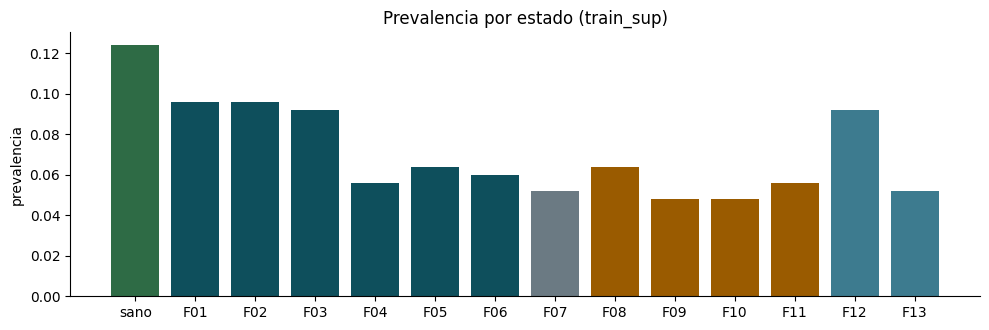

severidad: de las ventanas CON falla, 57.5 % son severas (max_severity > 0.5)


In [ ]:
prev = (pd.Series(estado).value_counts().sort_index()
        .rename(index=lambda k: ESTADOS[k]).to_frame("n"))
prev["prevalencia"] = prev.n / len(train)
prev["familia"] = ["sano"] + [FAMILIES[f] for f in FAULT_IDS]
display(prev)

fig, ax = plt.subplots(figsize=(10, 3.4))
colores = {"sano": "#2E6B45", "mechanical": "#0E4F5C", "structural": "#6B7A83",
           "electrical": "#9A5B00", "hydraulic": "#3D7B8F"}
ax.bar(prev.index, prev.prevalencia, color=[colores[f] for f in prev.familia])
ax.set_ylabel("prevalencia"); ax.set_title("Prevalencia por estado (train_sup)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

print("severidad: de las ventanas CON falla, %.1f %% son severas (max_severity > 0.5)"
      % (100 * (train.loc[n_fallas > 0, [f"severity_{f}" for f in FAULT_IDS]].max(axis=1) > 0.5).mean()))

El desbalance es moderado (de 4.8 % a 9.6 % por falla, 12.4 % sano). No hace
falta remuestrear: lo que castiga la métrica no es el desbalance sino la
confusión **entre familias**, porque `cost_score` — que pesa 70 % — sólo
distingue las cuatro familias más el estado sano.

## 2. Mitigación del covariate shift

Train y test no comparten ninguna máquina. Cada máquina tiene su punto de
trabajo propio (rpm, temperatura, caudal), así que los valores **absolutos** de
los sensores identifican a la máquina más que al estado de salud. Un modelo
entrenado sobre valores absolutos aprende las 26 máquinas del train y no
generaliza a las 22 del test.

La corrección es expresar cada variable como desviación respecto del
comportamiento habitual de su propia máquina:

$$z_{i,c} = \frac{x_{i,c} - \mathrm{mediana}_{m(i)}(x_c)}{\mathrm{desvío}_{m(i)}(x_c) + \varepsilon}$$

Se usa **mediana** y no media por robustez ante las ventanas en falla, que son
justamente las colas de la distribución de cada máquina.

Esto es legítimo sobre el test: usa sólo las columnas de features y el
`machine_id`, nunca las etiquetas. Se calcula por separado en cada tabla.

In [ ]:
EXCLUIR = set(["window_id", "machine_id", "session_id", "is_normal", "is_combo"]
              + LABEL_COLUMNS + [f"severity_{f}" for f in FAULT_IDS])
FEATS = [c for c in train.columns if c not in EXCLUIR]
print("features tabulares originales:", len(FEATS))

def zscore_por_maquina(df, cols):
    """Desviación respecto de la propia máquina. No mira etiquetas."""
    g = df.groupby("machine_id")[cols]
    z = (df[cols] - g.transform("median")) / (g.transform("std") + 1e-9)
    z.columns = [c + "__z" for c in cols]
    return z

def construir_X(df):
    return pd.concat([df[FEATS], zscore_por_maquina(df, FEATS)], axis=1)

X_train, X_test = construir_X(train), construir_X(test)
print("matriz final:", X_train.shape, "(originales + z-score)")

features tabulares originales: 46
matriz final: (1750, 92) (originales + z-score)


### Verificación gráfica del alineamiento

Un KDE de train contra test, antes y después. Si la normalización funciona, las
dos curvas se superponen en el panel derecho.

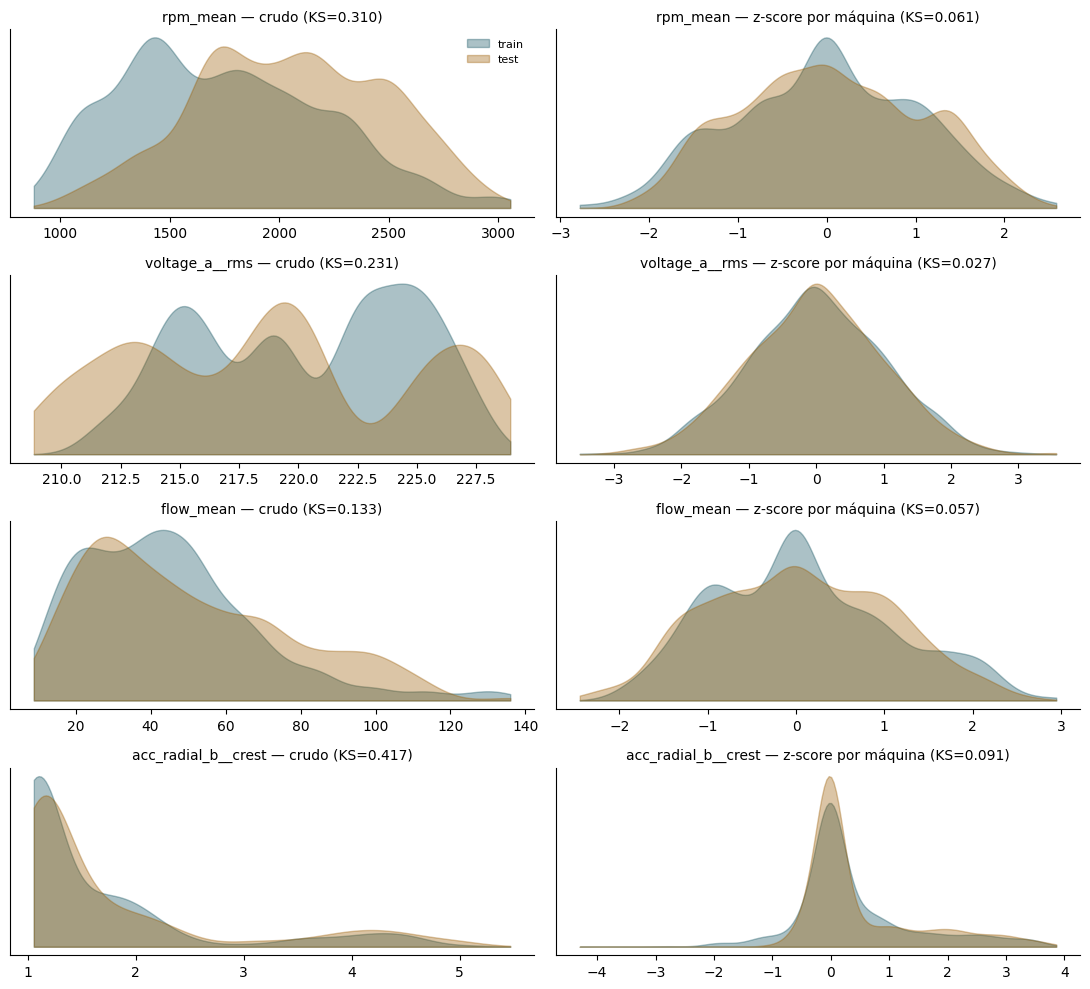

In [ ]:
from scipy.stats import gaussian_kde, ks_2samp

CRITICAS = ["rpm_mean", "voltage_a__rms", "flow_mean", "acc_radial_b__crest"]

def kde(ax, a, b, titulo):
    grid = np.linspace(min(a.min(), b.min()), max(a.max(), b.max()), 200)
    ax.fill_between(grid, gaussian_kde(a)(grid), color="#0E4F5C", alpha=.35, label="train")
    ax.fill_between(grid, gaussian_kde(b)(grid), color="#9A5B00", alpha=.35, label="test")
    ax.set_title(titulo, fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_yticks([])

fig, axes = plt.subplots(len(CRITICAS), 2, figsize=(11, 2.5 * len(CRITICAS)))
for fila, c in enumerate(CRITICAS):
    ks_c = ks_2samp(train[c], test[c]).statistic
    ks_z = ks_2samp(X_train[c + "__z"].dropna(), X_test[c + "__z"].dropna()).statistic
    kde(axes[fila, 0], train[c].values, test[c].values, f"{c} — crudo (KS={ks_c:.3f})")
    kde(axes[fila, 1], X_train[c + "__z"].dropna().values, X_test[c + "__z"].dropna().values,
        f"{c} — z-score por máquina (KS={ks_z:.3f})")
axes[0, 0].legend(fontsize=8, frameon=False)
plt.tight_layout(); plt.show()

In [ ]:
# Efecto sobre las 46 variables, no sólo sobre las cuatro del gráfico.
ks_crudo = [ks_2samp(train[c], test[c]).statistic for c in FEATS]
ks_norm  = [ks_2samp(X_train[c + "__z"].dropna(), X_test[c + "__z"].dropna()).statistic
            for c in FEATS]

print("KS medio train vs test:  crudo = %.3f   ->   z-score = %.3f"
      % (np.mean(ks_crudo), np.mean(ks_norm)))
print("variables con KS > 0.2:  crudo = %d      ->   z-score = %d"
      % (sum(k > .2 for k in ks_crudo), sum(k > .2 for k in ks_norm)))

KS medio train vs test:  crudo = 0.139   ->   z-score = 0.059
variables con KS > 0.2:  crudo = 11      ->   z-score = 0


Las 11 variables que estaban claramente desalineadas quedan en cero, y el KS
medio cae a menos de la mitad. Se **conservan las dos versiones** de cada
variable: los valores absolutos siguen teniendo información física real
(una temperatura de devanado alta es alta en cualquier máquina) y los árboles
eligen cuál usar.

## 3. Feature engineering: variables físicas

Los descriptores del dataset son estadísticos por sensor. Acá se derivan ~42
variables con sentido físico —relaciones entre armónicos, desbalances de tensión
y corriente, saltos térmicos sobre ambiente, potencia hidráulica— que codifican
lo que un analista de vibraciones miraría a mano.

`construir(df, modo)` centraliza las cuatro combinaciones que se prueban en el
notebook: `base` (sólo originales), `fis` (+ físicas), `fis_z` (+ z-score por
máquina) y `ana_z` (originales + z, sin físicas).


In [ ]:
BASE = [c for c in test.columns
        if c not in ("window_id", "machine_id", "session_id", "timestamp_start_s")]
ACC = ["acc_radial_a", "acc_radial_b", "acc_axial"]

def fisicas(df):
    X = pd.DataFrame(index=df.index)
    rpm = df.rpm_mean.clip(lower=1) / 1000.0
    rpm2 = rpm ** 2
    for a in ACC:
        rms = df[f"{a}__rms"].clip(lower=1e-9)
        X[f"{a}__rms_n"] = rms / rpm2
        X[f"{a}__1x_r"]  = df[f"{a}__1x"] / (rms ** 2 + 1e-9)
        X[f"{a}__2x1x"]  = df[f"{a}__2x"] / (df[f"{a}__1x"].abs() + 1e-6)
        X[f"{a}__lkurt"] = np.log1p(df[f"{a}__kurtosis"].clip(lower=0))
        X[f"{a}__crest_n"] = df[f"{a}__crest"]
    ra = df["acc_radial_a__rms"].clip(lower=1e-9)
    X["ax_rad"]  = df["acc_axial__rms"] / ra
    X["rad_b_a"] = df["acc_radial_b__rms"] / ra
    X["vib_tot"] = df[[f"{a}__rms" for a in ACC]].sum(1) / rpm2
    V = df[["voltage_a__rms", "voltage_b__rms", "voltage_c__rms"]]
    I = df[["current_a__rms", "current_b__rms", "current_c__rms"]]
    vm, im = V.mean(1).clip(lower=1e-9), I.mean(1).clip(lower=1e-9)
    X["V_desbal"] = (V.max(1) - V.min(1)) / vm
    X["I_desbal"] = (I.max(1) - I.min(1)) / im
    X["V_cv"] = V.std(1) / vm
    X["I_cv"] = I.std(1) / im
    X["I_min_r"] = I.min(1) / im
    X["I_max_r"] = I.max(1) / im
    X["S_ap"] = im * vm / 1000.0
    X["I_por_rpm"]  = im / rpm
    X["I_por_flow"] = im / (df.flow_mean.abs() + 1e-6)
    X["dT_wind"]   = df["temp_winding__mean"] - df.Tamb
    X["dT_b1"]     = df["temp_bearing1__mean"] - df.Tamb
    X["dT_b2"]     = df["temp_bearing2__mean"] - df.Tamb
    X["dT_b1b2"]   = df["temp_bearing1__mean"] - df["temp_bearing2__mean"]
    X["dT_wind_b"] = df["temp_winding__mean"] - df[["temp_bearing1__mean", "temp_bearing2__mean"]].mean(1)
    X["dT_wind_rpm"] = X["dT_wind"] / rpm
    X["head_n"]    = df.delta_p_mean / rpm2
    X["flow_n"]    = df.flow_mean / rpm
    X["p_in_n"]    = df.pressure_in_mean / rpm2
    X["p_ratio"]   = df.pressure_out_mean / (df.pressure_in_mean.abs() + 1e-6)
    X["hidr_pot"]  = df.flow_mean * df.delta_p_mean / (im * vm + 1e-6)
    X["flow_head"] = df.flow_mean / (df.delta_p_mean.abs() + 1e-6)
    X["rpm_cv"] = df.rpm_std / df.rpm_mean.clip(lower=1)
    nanc = [c for c in df.columns if c.endswith("__nan_frac")]
    X["nan_tot"] = df[nanc].sum(1)
    X["nan_max"] = df[nanc].max(1)
    return X.replace([np.inf, -np.inf], np.nan).fillna(0.0)

def rank_maq(df, cols):
    r = df.groupby("machine_id")[cols].rank(pct=True)
    r.columns = [c + "__r" for c in cols]
    return r

def zmaq(df, cols):
    g = df.groupby("machine_id")[cols]
    z = (df[cols] - g.transform("median")) / (g.transform("std") + 1e-9)
    z.columns = [c + "__z" for c in cols]
    return z

def construir(df, modo="fis_z"):
    if modo == "base":
        return df[BASE]
    todo = pd.concat([df[BASE], fisicas(df)], axis=1)
    if modo == "fis":
        return todo
    tmp = todo.copy(); tmp["machine_id"] = df["machine_id"].to_numpy()
    if modo == "fis_z":
        return pd.concat([todo, zmaq(tmp, list(todo.columns))], axis=1)
    if modo == "ana_z":
        F = [c for c in df.columns if c not in EXCLUIR]
        return pd.concat([df[F], zmaq(df, F)], axis=1)
    return pd.concat([todo, rank_maq(tmp, list(todo.columns))], axis=1)

print("base:", len(BASE), "| físicas:", fisicas(train).shape[1],
      "| total con z:", construir(train).shape[1])

base: 45 | físicas: 42 | total con z: 174


### Preparación y catalogación de features

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Conjunto principal que queremos estudiar
X_eda = construir(train, "fis_z").copy()

# Nombres reales de las features
ORIG_FEATS = list(BASE)
FIS_FEATS = list(fisicas(train).columns)
Z_FEATS = [c for c in X_eda.columns if c.endswith("__z")]

FEATURE_GROUP = {}

for c in X_eda.columns:
    if c in ORIG_FEATS:
        FEATURE_GROUP[c] = "original"
    elif c in FIS_FEATS:
        FEATURE_GROUP[c] = "fis"
    elif c in Z_FEATS:
        FEATURE_GROUP[c] = "z"
    else:
        FEATURE_GROUP[c] = "otro"

print("Dimensiones:", X_eda.shape)
print("Originales :", len(ORIG_FEATS))
print("Físicas    :", len(FIS_FEATS))
print("Z-score    :", len(Z_FEATS))

feature_catalog = pd.DataFrame({
    "feature": X_eda.columns,
    "grupo": [FEATURE_GROUP[c] for c in X_eda.columns]
})

display(feature_catalog)

Dimensiones: (1750, 174)
Originales : 45
Físicas    : 42
Z-score    : 87


,feature,grupo
0,Tamb,original
1,acc_radial_a__rms,original
2,acc_radial_a__kurtosis,original
3,acc_radial_a__crest,original
4,acc_radial_a__1x,original
...,...,...
169,hidr_pot__z,z
170,flow_head__z,z
171,rpm_cv__z,z
172,nan_tot__z,z


### Calidad estadística

In [ ]:
X_num = X_eda.apply(pd.to_numeric, errors="coerce")

rows = []
n = len(X_num)

for c in X_num.columns:
    s = X_num[c]
    v = s.dropna()

    if len(v) == 0:
        rows.append({
            "feature": c,
            "grupo": FEATURE_GROUP[c],
            "missing_pct": 100.0,
            "nunique": 0,
            "mean": np.nan,
            "std": np.nan,
            "min": np.nan,
            "max": np.nan,
            "skew": np.nan,
            "cv": np.nan,
            "q1": np.nan,
            "q3": np.nan,
            "iqr": np.nan,
            "outlier_iqr_pct": np.nan,
            "top_freq_pct": np.nan,
            "unique_pct": 0.0,
        })
        continue

    q1, q3 = v.quantile([0.25, 0.75])
    iqr = q3 - q1

    if iqr > 0:
        outlier_pct = 100 * (
            (v < q1 - 1.5 * iqr) |
            (v > q3 + 1.5 * iqr)
        ).mean()
    else:
        outlier_pct = 0.0

    mean = v.mean()
    std = v.std()

    rows.append({
        "feature": c,
        "grupo": FEATURE_GROUP[c],
        "missing_pct": 100 * s.isna().mean(),
        "nunique": s.nunique(),
        "mean": mean,
        "std": std,
        "min": v.min(),
        "max": v.max(),
        "skew": v.skew(),
        "cv": std / abs(mean) if abs(mean) > 1e-12 else np.nan,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "outlier_iqr_pct": outlier_pct,
        "top_freq_pct": 100 * v.value_counts(normalize=True).iloc[0],
        "unique_pct": 100 * s.nunique() / n,
    })

quality = pd.DataFrame(rows).set_index("feature")

quality["near_constant"] = quality["top_freq_pct"] >= 99
quality["discrete"] = (
    (quality["nunique"] <= 10) |
    (quality["unique_pct"] <= 1)
)
quality["high_skew"] = quality["skew"].abs() >= 2
quality["many_outliers"] = quality["outlier_iqr_pct"] >= 5

print("=== Resumen de calidad ===")
for c, label in [
    ("missing_pct", "features con missing"),
    ("near_constant", "casi constantes"),
    ("discrete", "discretas / baja cardinalidad"),
    ("high_skew", "muy sesgadas"),
    ("many_outliers", "con muchos outliers IQR"),
]:
    if c == "missing_pct":
        nflag = int((quality[c] > 0).sum())
    else:
        nflag = int(quality[c].sum())
    print(f"{label:35s}: {nflag}")

print("\n=== Más problemáticas ===")
display(
    quality.sort_values(
        ["near_constant", "high_skew", "outlier_iqr_pct"],
        ascending=[False, False, False]
    ).head(40)
)

=== Resumen de calidad ===
features con missing               : 0
casi constantes                    : 22
discretas / baja cardinalidad      : 22
muy sesgadas                       : 54
con muchos outliers IQR            : 78

=== Más problemáticas ===


,grupo,missing_pct,nunique,mean,std,min,max,skew,cv,q1,q3,iqr,outlier_iqr_pct,top_freq_pct,unique_pct,near_constant,discrete,high_skew,many_outliers
feature,,,,,,,,,,,,,,,,,,,
acc_radial_a__nan_frac,original,0.0,4,0.000213,4.861004e-03,0.000000,1.340000e-01,25.294670,22.830802,0.000000,0.000000,0.000000,0.000000,99.771429,0.228571,True,True,True,False
acc_radial_b__nan_frac,original,0.0,10,0.000740,9.352666e-03,0.000000,1.496000e-01,13.298321,12.632885,0.000000,0.000000,0.000000,0.000000,99.257143,0.571429,True,True,True,False
acc_axial__nan_frac,original,0.0,4,0.000256,4.959940e-03,0.000000,1.261000e-01,20.569421,19.387748,0.000000,0.000000,0.000000,0.000000,99.714286,0.228571,True,True,True,False
voltage_a__nan_frac,original,0.0,5,0.000233,4.757474e-03,0.000000,1.123000e-01,21.381226,20.400834,0.000000,0.000000,0.000000,0.000000,99.714286,0.285714,True,True,True,False
voltage_b__nan_frac,original,0.0,13,0.000627,7.903207e-03,0.000000,1.495000e-01,13.637224,12.603073,0.000000,0.000000,0.000000,0.000000,99.257143,0.742857,True,True,True,False
voltage_c__nan_frac,original,0.0,10,0.000643,7.576493e-03,0.000000,1.226000e-01,13.183445,11.782515,0.000000,0.000000,0.000000,0.000000,99.142857,0.571429,True,True,True,False
current_a__nan_frac,original,0.0,9,0.000620,8.202189e-03,0.000000,1.362000e-01,14.262503,13.231776,0.000000,0.000000,0.000000,0.000000,99.314286,0.514286,True,True,True,False
current_c__nan_frac,original,0.0,6,0.000331,6.092965e-03,0.000000,1.431000e-01,20.602459,18.396632,0.000000,0.000000,0.000000,0.000000,99.600000,0.342857,True,True,True,False
acc_radial_a__nan_frac__z,z,0.0,4,0.016495,3.526884e-01,0.000000,8.774963e+00,22.218720,21.381326,0.000000,0.000000,0.000000,0.000000,99.771429,0.228571,True,True,True,False


Ahora que hemos identificado las características con varianza cero, las eliminaremos del conjunto de entrenamiento `X_eda`. Esto evita que estas características, que no aportan información útil, se utilicen en los modelos y asegura que no haya `data leakage` si, por alguna razón, una característica constante en el conjunto de entrenamiento no lo fuera en el de prueba.

In [ ]:
DROP_ZERO_VARIANCE = [
    c for c in quality.index
    if quality.loc[c, "std"] == 0
]

# Eliminar las características con varianza cero de X_eda
X_eda = X_eda.drop(columns=DROP_ZERO_VARIANCE)

# Actualizar las listas de características y el diccionario de grupos
ORIG_FEATS = [f for f in ORIG_FEATS if f not in DROP_ZERO_VARIANCE]
FIS_FEATS = [f for f in FIS_FEATS if f not in DROP_ZERO_VARIANCE]
Z_FEATS = [f for f in Z_FEATS if f not in DROP_ZERO_VARIANCE]

# Limpiar FEATURE_GROUP
FEATURE_GROUP = {k: v for k, v in FEATURE_GROUP.items() if k not in DROP_ZERO_VARIANCE}

# Actualizar X_num que es la versión de X_eda con NaNs rellenados para MI
X_num = X_eda.apply(pd.to_numeric, errors="coerce")
# Vuelve a rellenar los valores NaN por si acaso, aunque DROP_ZERO_VARIANCE es para std=0, no para NaNs
X_num = X_num.replace([np.inf, -np.inf], np.nan).fillna(X_num.median())

print(f"Características eliminadas: {DROP_ZERO_VARIANCE}")
print(f"Nueva dimensión de X_eda: {X_eda.shape}")
print(f"Nueva dimensión de X_num: {X_num.shape}")

Características eliminadas: ['temp_winding__nan_frac', 'temp_bearing1__nan_frac', 'temp_bearing2__nan_frac', 'temp_winding__nan_frac__z', 'temp_bearing1__nan_frac__z', 'temp_bearing2__nan_frac__z']
Nueva dimensión de X_eda: (1750, 168)
Nueva dimensión de X_num: (1750, 168)


### Análisis de redundancia

In [ ]:
corr = X_num.corr(method="pearson")

pairs = []

cols = corr.columns.tolist()

for i in range(len(cols)):
    for j in range(i):
        r = corr.iloc[i, j]

        if pd.notna(r) and abs(r) > 0.90:
            pairs.append({
                "feature_1": cols[i],
                "feature_2": cols[j],
                "corr": r,
                "abs_corr": abs(r),
                "grupo_1": FEATURE_GROUP[cols[i]],
                "grupo_2": FEATURE_GROUP[cols[j]],
            })

high_corr_pairs = (
    pd.DataFrame(pairs)
    .sort_values("abs_corr", ascending=False)
    .reset_index(drop=True)
)

print("Pares |corr| > 0.90:", len(high_corr_pairs))
print("Pares |corr| > 0.95:", int((high_corr_pairs["abs_corr"] > 0.95).sum()))

display(high_corr_pairs.head(50))

Pares |corr| > 0.90: 90
Pares |corr| > 0.95: 57


,feature_1,feature_2,corr,abs_corr,grupo_1,grupo_2
0,acc_radial_b__crest_n,acc_radial_b__crest,1.000000,1.000000,fis,original
1,acc_radial_a__crest_n,acc_radial_a__crest,1.000000,1.000000,fis,original
2,acc_axial__crest_n,acc_axial__crest,1.000000,1.000000,fis,original
3,acc_radial_b__crest_n__z,acc_radial_b__crest__z,1.000000,1.000000,z,z
4,acc_radial_a__crest_n__z,acc_radial_a__crest__z,1.000000,1.000000,z,z
5,acc_axial__crest_n__z,acc_axial__crest__z,1.000000,1.000000,z,z
6,rpm_cv__z,rpm_cv,0.999996,0.999996,z,fis
7,S_ap__z,I_rms_mean__z,0.999922,0.999922,z,z
8,S_ap,I_rms_mean,0.999618,0.999618,fis,original
9,I_rms_mean,current_b__rms,0.999451,0.999451,original,original


In [ ]:
ORIG_PLUS_FIS = X_num[ORIG_FEATS + FIS_FEATS]

corr_p = ORIG_PLUS_FIS.corr(method="pearson")
corr_s = ORIG_PLUS_FIS.corr(method="spearman")

fis_redundancy = []

for f in FIS_FEATS:

    others = [c for c in ORIG_FEATS if c != f]

    p = corr_p.loc[f, others].abs()
    s = corr_s.loc[f, others].abs()

    fis_redundancy.append({
        "fis": f,
        "max_abs_pearson": p.max(),
        "closest_pearson": p.idxmax(),
        "max_abs_spearman": s.max(),
        "closest_spearman": s.idxmax(),
    })

fis_redundancy = (
    pd.DataFrame(fis_redundancy)
    .sort_values("max_abs_pearson", ascending=False)
)

display(fis_redundancy)

,fis,max_abs_pearson,closest_pearson,max_abs_spearman,closest_spearman
9,acc_radial_b__crest_n,1.000000,acc_radial_b__crest,1.000000,acc_radial_b__crest
4,acc_radial_a__crest_n,1.000000,acc_radial_a__crest,1.000000,acc_radial_a__crest
14,acc_axial__crest_n,1.000000,acc_axial__crest,1.000000,acc_axial__crest
24,S_ap,0.999618,I_rms_mean,0.999776,I_rms_mean
36,p_ratio,0.998341,delta_p_mean,0.999020,delta_p_mean
39,rpm_cv,0.955539,rpm_std,0.699705,rpm_std
25,I_por_rpm,0.919258,current_c__rms,0.964977,current_c__rms
12,acc_axial__2x1x,0.911359,acc_radial_a__2x,0.939408,acc_axial__2x
35,p_in_n,0.898112,rpm_mean,0.993050,rpm_mean
10,acc_axial__rms_n,0.895334,acc_axial__rms,0.844581,rpm_mean


### Mutual Information

In [ ]:
from sklearn.feature_selection import mutual_info_classif

# MI requiere valores finitos
X_mi = (
    X_num
    .replace([np.inf, -np.inf], np.nan)
    .fillna(X_num.median())
)

# A. Sano vs falla
y_binary = (estado > 0).astype(int)

mi_binary = mutual_info_classif(
    X_mi,
    y_binary,
    discrete_features=False,
    random_state=42
)

# B. 14 estados

y_state = estado.astype(int)

mi_14 = mutual_info_classif(
    X_mi,
    y_state,
    discrete_features=False,
    random_state=42
)
# C. Familias
# Sólo entre ventanas que tienen una falla
mask_fault = estado > 0

family_labels = np.array([
    FAMILIES[FAULT_IDS[e - 1]]
    for e in estado[mask_fault]
])

family_codes, family_names = pd.factorize(
    family_labels,
    sort=True
)

mi_family = mutual_info_classif(
    X_mi.loc[mask_fault],
    family_codes,
    discrete_features=False,
    random_state=42
)

# Tabla final
mi = pd.DataFrame({
    "feature": X_mi.columns,
    "grupo": [FEATURE_GROUP[c] for c in X_mi.columns],
    "MI_binary": mi_binary,
    "MI_14": mi_14,
    "MI_family": mi_family,
}).set_index("feature")

# rankings internos
mi["rank_binary"] = mi["MI_binary"].rank(
    ascending=False, method="min"
)
mi["rank_14"] = mi["MI_14"].rank(
    ascending=False, method="min"
)
mi["rank_family"] = mi["MI_family"].rank(
    ascending=False, method="min"
)

# Percentiles para comparar el papel relativo
mi["pct_binary"] = mi["MI_binary"].rank(pct=True)
mi["pct_14"] = mi["MI_14"].rank(pct=True)
mi["pct_family"] = mi["MI_family"].rank(pct=True)

# Aumenta cuando una feature se vuelve relativamente
# más importante para identificar el estado que para detectar anomalía.
mi["specificity_gain"] = (
    mi["pct_14"] - mi["pct_binary"]
)

print("=== Top 30 — Sano vs Falla ===")
display(
    mi.sort_values("MI_binary", ascending=False)
      .head(30)
)

print("=== Top 30 — 14 Estados ===")
display(
    mi.sort_values("MI_14", ascending=False)
      .head(30)
)

print("=== Top 30 — Familias ===")
display(
    mi.sort_values("MI_family", ascending=False)
      .head(30)
)

=== Top 30 — Sano vs Falla ===


,grupo,MI_binary,MI_14,MI_family,rank_binary,rank_14,rank_family,pct_binary,pct_14,pct_family,specificity_gain
feature,,,,,,,,,,,
S_ap,fis,0.370132,2.488718,1.059284,1.0,3.0,7.0,1.000000,0.988095,0.964286,-0.011905
Tamb,original,0.364064,2.563550,1.135817,2.0,1.0,1.0,0.994048,1.000000,1.000000,0.005952
I_rms_mean,original,0.360981,2.525215,1.103826,3.0,2.0,2.0,0.988095,0.994048,0.994048,0.005952
current_a__rms,original,0.358916,2.442260,1.026009,4.0,7.0,9.0,0.982143,0.964286,0.952381,-0.017857
Tamb__z,z,0.356993,2.487615,1.089223,5.0,4.0,3.0,0.976190,0.982143,0.988095,0.005952
I_rms_mean__z,z,0.346863,2.414656,1.084850,6.0,8.0,4.0,0.970238,0.958333,0.982143,-0.011905
current_c__rms,original,0.340043,2.459826,1.061031,7.0,5.0,6.0,0.964286,0.976190,0.970238,0.011905
current_b__rms,original,0.337738,2.456917,1.076192,8.0,6.0,5.0,0.958333,0.970238,0.976190,0.011905
acc_radial_b__rms,original,0.332542,2.272035,0.976962,9.0,14.0,13.0,0.952381,0.922619,0.928571,-0.029762


=== Top 30 — 14 Estados ===


,grupo,MI_binary,MI_14,MI_family,rank_binary,rank_14,rank_family,pct_binary,pct_14,pct_family,specificity_gain
feature,,,,,,,,,,,
Tamb,original,0.364064,2.563550,1.135817,2.0,1.0,1.0,0.994048,1.000000,1.000000,0.005952
I_rms_mean,original,0.360981,2.525215,1.103826,3.0,2.0,2.0,0.988095,0.994048,0.994048,0.005952
S_ap,fis,0.370132,2.488718,1.059284,1.0,3.0,7.0,1.000000,0.988095,0.964286,-0.011905
Tamb__z,z,0.356993,2.487615,1.089223,5.0,4.0,3.0,0.976190,0.982143,0.988095,0.005952
current_c__rms,original,0.340043,2.459826,1.061031,7.0,5.0,6.0,0.964286,0.976190,0.970238,0.011905
current_b__rms,original,0.337738,2.456917,1.076192,8.0,6.0,5.0,0.958333,0.970238,0.976190,0.011905
current_a__rms,original,0.358916,2.442260,1.026009,4.0,7.0,9.0,0.982143,0.964286,0.952381,-0.017857
I_rms_mean__z,z,0.346863,2.414656,1.084850,6.0,8.0,4.0,0.970238,0.958333,0.982143,-0.011905
I_por_rpm,fis,0.316496,2.382228,1.023631,14.0,9.0,10.0,0.922619,0.952381,0.946429,0.029762


=== Top 30 — Familias ===


,grupo,MI_binary,MI_14,MI_family,rank_binary,rank_14,rank_family,pct_binary,pct_14,pct_family,specificity_gain
feature,,,,,,,,,,,
Tamb,original,0.364064,2.563550,1.135817,2.0,1.0,1.0,0.994048,1.000000,1.000000,0.005952
I_rms_mean,original,0.360981,2.525215,1.103826,3.0,2.0,2.0,0.988095,0.994048,0.994048,0.005952
Tamb__z,z,0.356993,2.487615,1.089223,5.0,4.0,3.0,0.976190,0.982143,0.988095,0.005952
I_rms_mean__z,z,0.346863,2.414656,1.084850,6.0,8.0,4.0,0.970238,0.958333,0.982143,-0.011905
current_b__rms,original,0.337738,2.456917,1.076192,8.0,6.0,5.0,0.958333,0.970238,0.976190,0.011905
current_c__rms,original,0.340043,2.459826,1.061031,7.0,5.0,6.0,0.964286,0.976190,0.970238,0.011905
S_ap,fis,0.370132,2.488718,1.059284,1.0,3.0,7.0,1.000000,0.988095,0.964286,-0.011905
S_ap__z,z,0.317218,2.343615,1.055728,13.0,10.0,8.0,0.928571,0.946429,0.958333,0.017857
current_a__rms,original,0.358916,2.442260,1.026009,4.0,7.0,9.0,0.982143,0.964286,0.952381,-0.017857


In [ ]:
print(
    "Features que relativamente pierden poca señal para detectar "
    "anomalía pero ganan importancia al identificar el estado:"
)

display(
    mi.sort_values("specificity_gain", ascending=False)
      [["grupo", "MI_binary", "MI_14", "specificity_gain"]]
      .head(30)
)

Features que relativamente pierden poca señal para detectar anomalía pero ganan importancia al identificar el estado:


,grupo,MI_binary,MI_14,specificity_gain
feature,,,,
acc_axial__crest_n__z,z,0.000000,0.347080,0.300595
acc_axial__crest__z,z,0.000000,0.346955,0.294643
acc_axial__2x1x__z,z,0.000964,0.273967,0.196429
acc_axial__2x1x,fis,0.009872,0.418452,0.160714
dT_b1b2__z,z,0.000000,0.103140,0.145833
I_cv__z,z,0.005787,0.305488,0.125000
acc_axial__lkurt__z,z,0.000000,0.044029,0.116071
voltage_b__rms,original,0.033719,0.724276,0.113095
V_cv__z,z,0.002426,0.178178,0.107143


### Effect size por cada falla

In [ ]:
def hedges_g(x, y):
    x = pd.Series(x).dropna().to_numpy(float)
    y = pd.Series(y).dropna().to_numpy(float)

    nx, ny = len(x), len(y)

    if nx < 2 or ny < 2:
        return np.nan

    sx = np.std(x, ddof=1)
    sy = np.std(y, ddof=1)

    pooled = np.sqrt(
        ((nx - 1) * sx**2 + (ny - 1) * sy**2)
        / (nx + ny - 2)
    )

    if pooled == 0:
        return 0.0

    d = (np.mean(x) - np.mean(y)) / pooled

    J = 1 - 3 / (4 * (nx + ny) - 9)

    return d * J


def cliffs_delta(x, y):
    x = pd.Series(x).dropna().to_numpy(float)
    y = pd.Series(y).dropna().to_numpy(float)

    nx, ny = len(x), len(y)

    if nx == 0 or ny == 0:
        return np.nan

    z = np.concatenate([x, y])

    ranks = pd.Series(z).rank(method="average").to_numpy()

    rx = ranks[:nx].sum()

    u = rx - nx * (nx + 1) / 2

    return 2 * (u / (nx * ny)) - 1


effect_rows = []

for fault_idx, fault in enumerate(FAULT_IDS, start=1):

    is_fault = estado == fault_idx
    is_rest = estado != fault_idx

    for feat in X_num.columns:

        g = hedges_g(
            X_num.loc[is_fault, feat],
            X_num.loc[is_rest, feat]
        )

        delta = cliffs_delta(
            X_num.loc[is_fault, feat],
            X_num.loc[is_rest, feat]
        )

        effect_rows.append({
            "falla": fault,
            "feature": feat,
            "grupo": FEATURE_GROUP[feat],
            "hedges_g": g,
            "abs_hedges_g": abs(g) if pd.notna(g) else np.nan,
            "cliffs_delta": delta,
            "abs_cliffs_delta": abs(delta) if pd.notna(delta) else np.nan,
        })

effects = pd.DataFrame(effect_rows)

effect_matrix = effects.pivot(
    index="feature",
    columns="falla",
    values="hedges_g"
)

# Top 10 por cada falla
for fault in FAULT_IDS:

    top = (
        effects[effects["falla"] == fault]
        .sort_values("abs_hedges_g", ascending=False)
        .head(10)
        [["feature", "grupo", "hedges_g", "cliffs_delta"]]
    )

    print(f"\n===== {fault} =====")
    display(top)


===== F01 =====


,feature,grupo,hedges_g,cliffs_delta
10,acc_radial_b__1x,original,2.971916,0.843041
94,acc_radial_b__1x__z,z,2.148133,0.823965
127,acc_radial_a__1x_r__z,z,2.142283,0.861063
48,acc_radial_b__1x_r,fis,2.111927,0.769121
43,acc_radial_a__1x_r,fis,2.105212,0.847714
128,acc_radial_a__2x1x__z,z,-1.924080,-0.919955
132,acc_radial_b__1x_r__z,z,1.772499,0.761017
88,acc_radial_a__1x__z,z,1.415468,0.769912
49,acc_radial_b__2x1x,fis,-1.337878,-0.830154
133,acc_radial_b__2x1x__z,z,-1.283615,-0.721141



===== F02 =====


,feature,grupo,hedges_g,cliffs_delta
185,acc_axial__2x,original,5.995559,1.000000
173,acc_radial_a__2x,original,5.720409,0.999579
181,acc_axial__rms,original,5.609190,0.999631
222,acc_axial__2x1x,fis,5.106772,0.988133
220,acc_axial__rms_n,fis,4.217821,0.948980
225,ax_rad,fis,3.978073,0.994469
269,acc_axial__2x__z,z,3.490545,0.951117
257,acc_radial_a__2x__z,z,3.281785,0.935111
172,acc_radial_a__1x,original,3.272301,0.925727
265,acc_axial__rms__z,z,3.192292,0.932432



===== F03 =====


...

,feature,grupo,hedges_g,cliffs_delta
1828,I_min_r__z,z,-1.759016,-0.585388
1825,I_desbal__z,z,1.706266,0.568612
1827,I_cv__z,z,1.705298,0.581781
1829,I_max_r__z,z,1.399457,0.459530
1745,I_max_r,fis,1.003096,0.493292
1724,acc_radial_a__2x1x,fis,0.996751,0.441098
1741,I_desbal,fis,0.721105,0.510179
1701,voltage_b__rms,original,-0.697650,-0.326006
1743,I_cv,fis,0.692198,0.496010
1730,acc_radial_b__lkurt,fis,0.690664,0.358866



===== F12 =====


,feature,grupo,hedges_g,cliffs_delta
1857,acc_radial_b__crest,original,3.245046,0.845866
1899,acc_radial_b__crest_n,fis,3.245046,0.845866
1859,acc_radial_b__2x,original,2.953482,0.862846
1851,acc_radial_a__crest,original,2.441893,0.789641
1894,acc_radial_a__crest_n,fis,2.441893,0.789641
1941,acc_radial_b__crest__z,z,2.346268,0.862486
1983,acc_radial_b__crest_n__z,z,2.346268,0.862486
1943,acc_radial_b__2x__z,z,2.257135,0.822346
1855,acc_radial_b__rms,original,2.248933,0.768939
1935,acc_radial_a__crest__z,z,1.963972,0.769338



===== F13 =====


,feature,grupo,hedges_g,cliffs_delta
2176,flow_n__z,z,-1.216817,-0.629368
2018,acc_radial_a__kurtosis,original,1.147392,-0.043141
2136,flow_mean__z,z,-0.595047,-0.314031
2061,acc_radial_a__lkurt,fis,0.576557,0.038339
2066,acc_radial_b__lkurt,fis,0.544072,0.237916
2148,acc_radial_b__1x_r__z,z,-0.524423,-0.277077
2113,acc_axial__rms__z,z,-0.515111,-0.318900
2135,temp_bearing2__mean__z,z,0.491769,0.265213
2039,voltage_c__rms,original,0.470616,0.262796
2100,Tamb__z,z,0.459081,0.214865


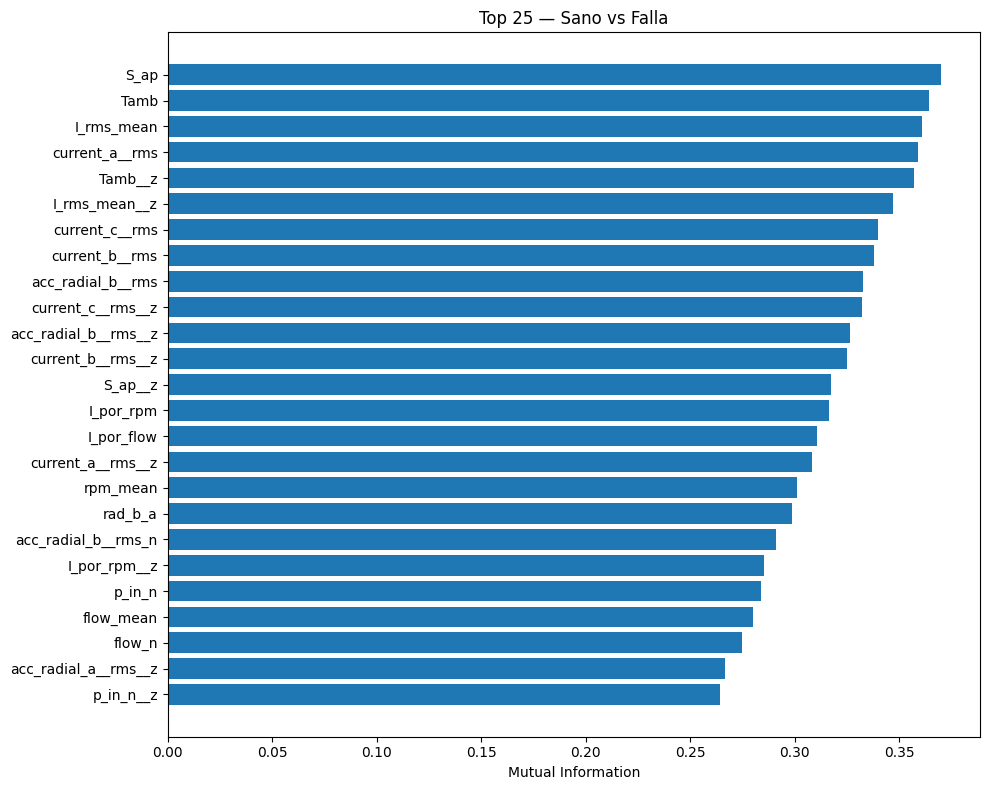

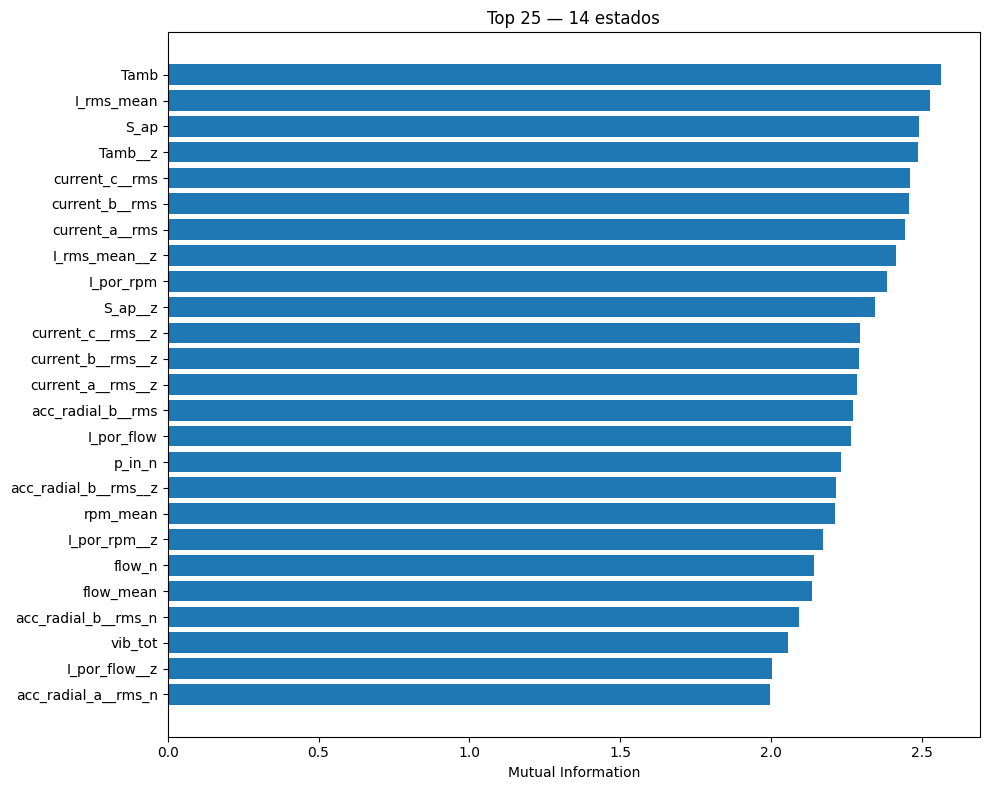

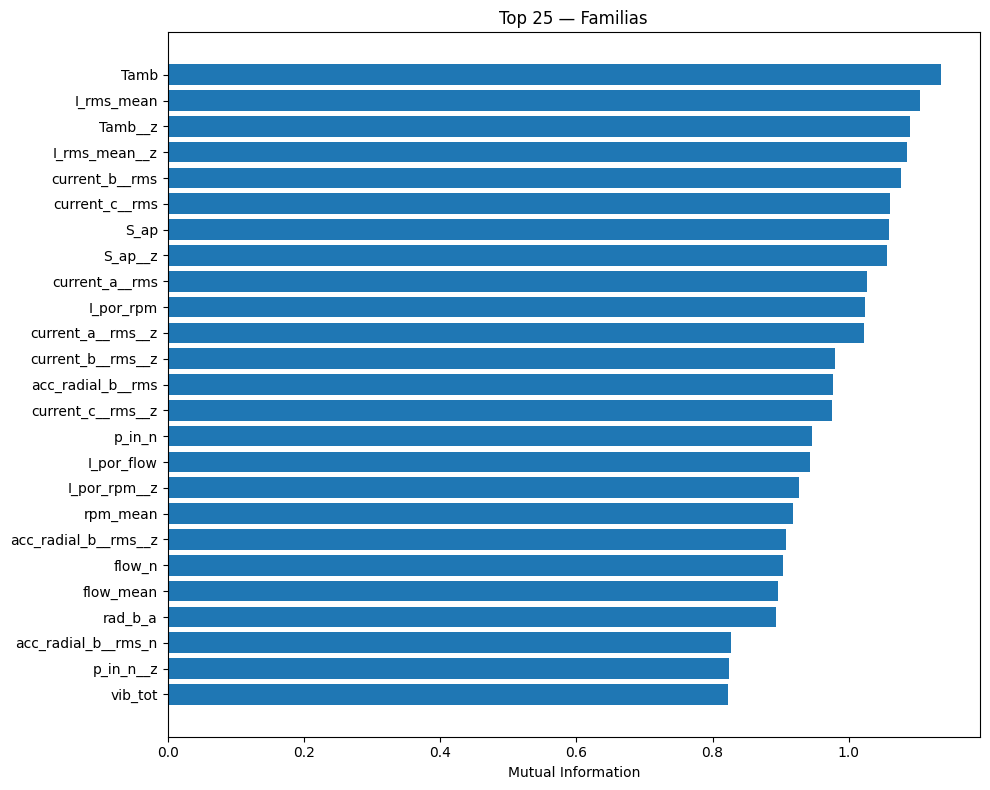

In [ ]:
def plot_top_mi(series, title, n=25):

    s = series.sort_values(ascending=False).head(n)
    s = s.sort_values()

    plt.figure(figsize=(10, 8))
    plt.barh(s.index, s.values)
    plt.xlabel("Mutual Information")
    plt.title(title)
    plt.tight_layout()
    plt.show()


plot_top_mi(
    mi["MI_binary"],
    "Top 25 — Sano vs Falla"
)

plot_top_mi(
    mi["MI_14"],
    "Top 25 — 14 estados"
)

plot_top_mi(
    mi["MI_family"],
    "Top 25 — Familias"
)

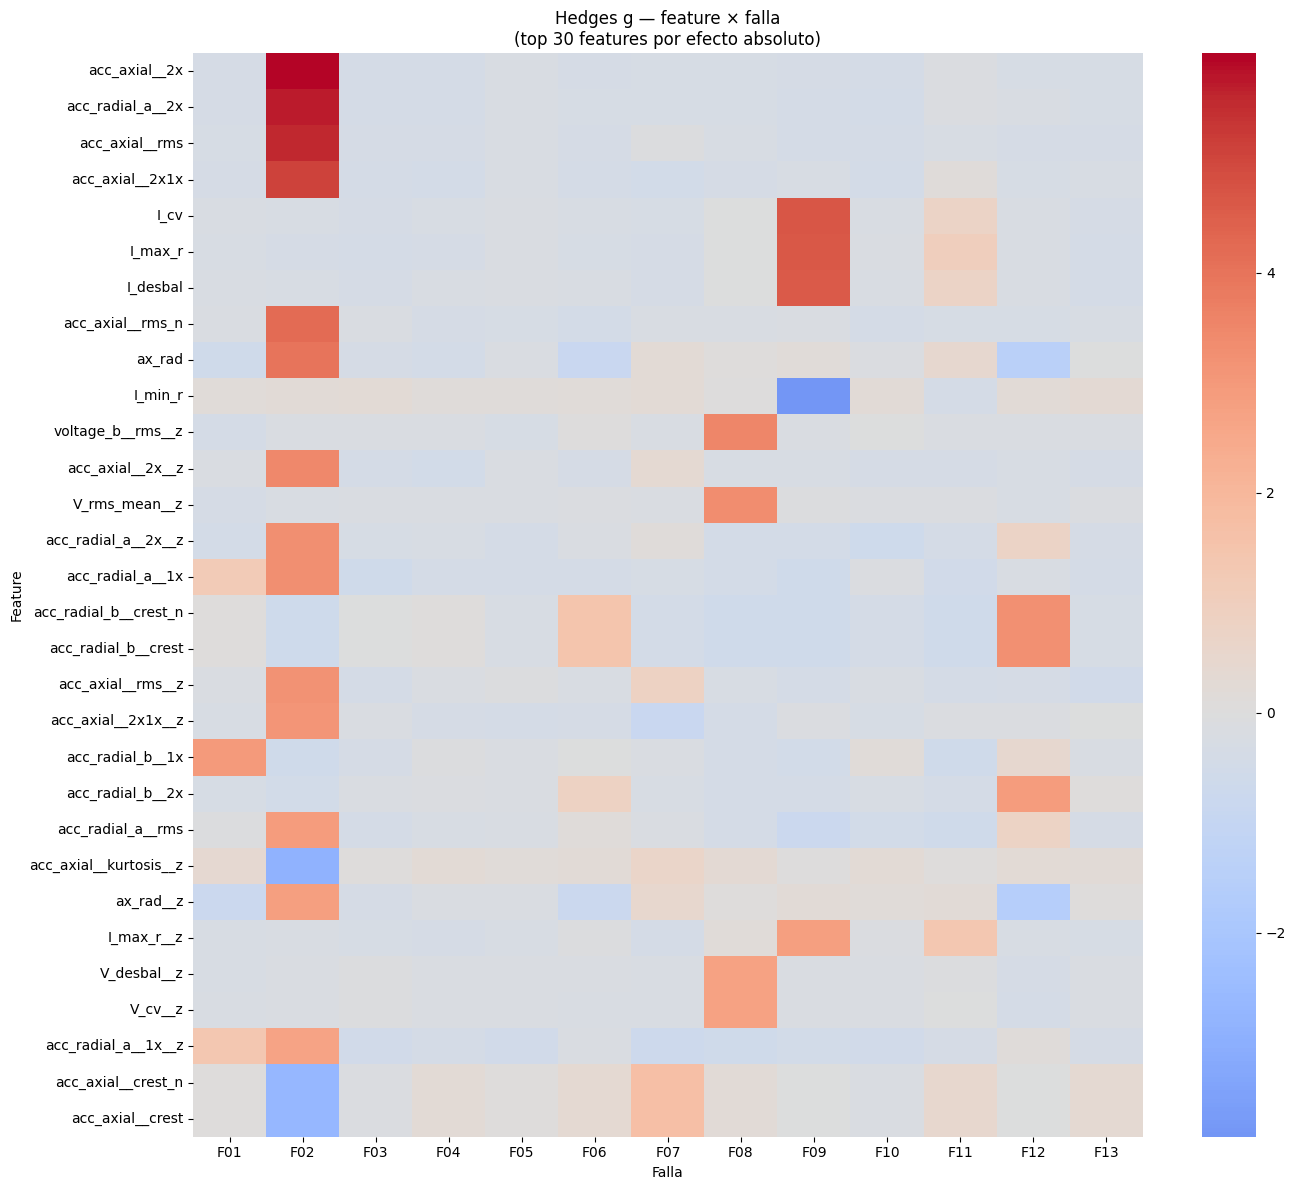

In [ ]:
top_effect_features = (
    effects.groupby("feature")["abs_hedges_g"]
    .max()
    .sort_values(ascending=False)
    .head(30)
    .index
)

plt.figure(figsize=(14, 12))

sns.heatmap(
    effect_matrix.loc[top_effect_features],
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title(
    "Hedges g — feature × falla\n"
    "(top 30 features por efecto absoluto)"
)

plt.xlabel("Falla")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

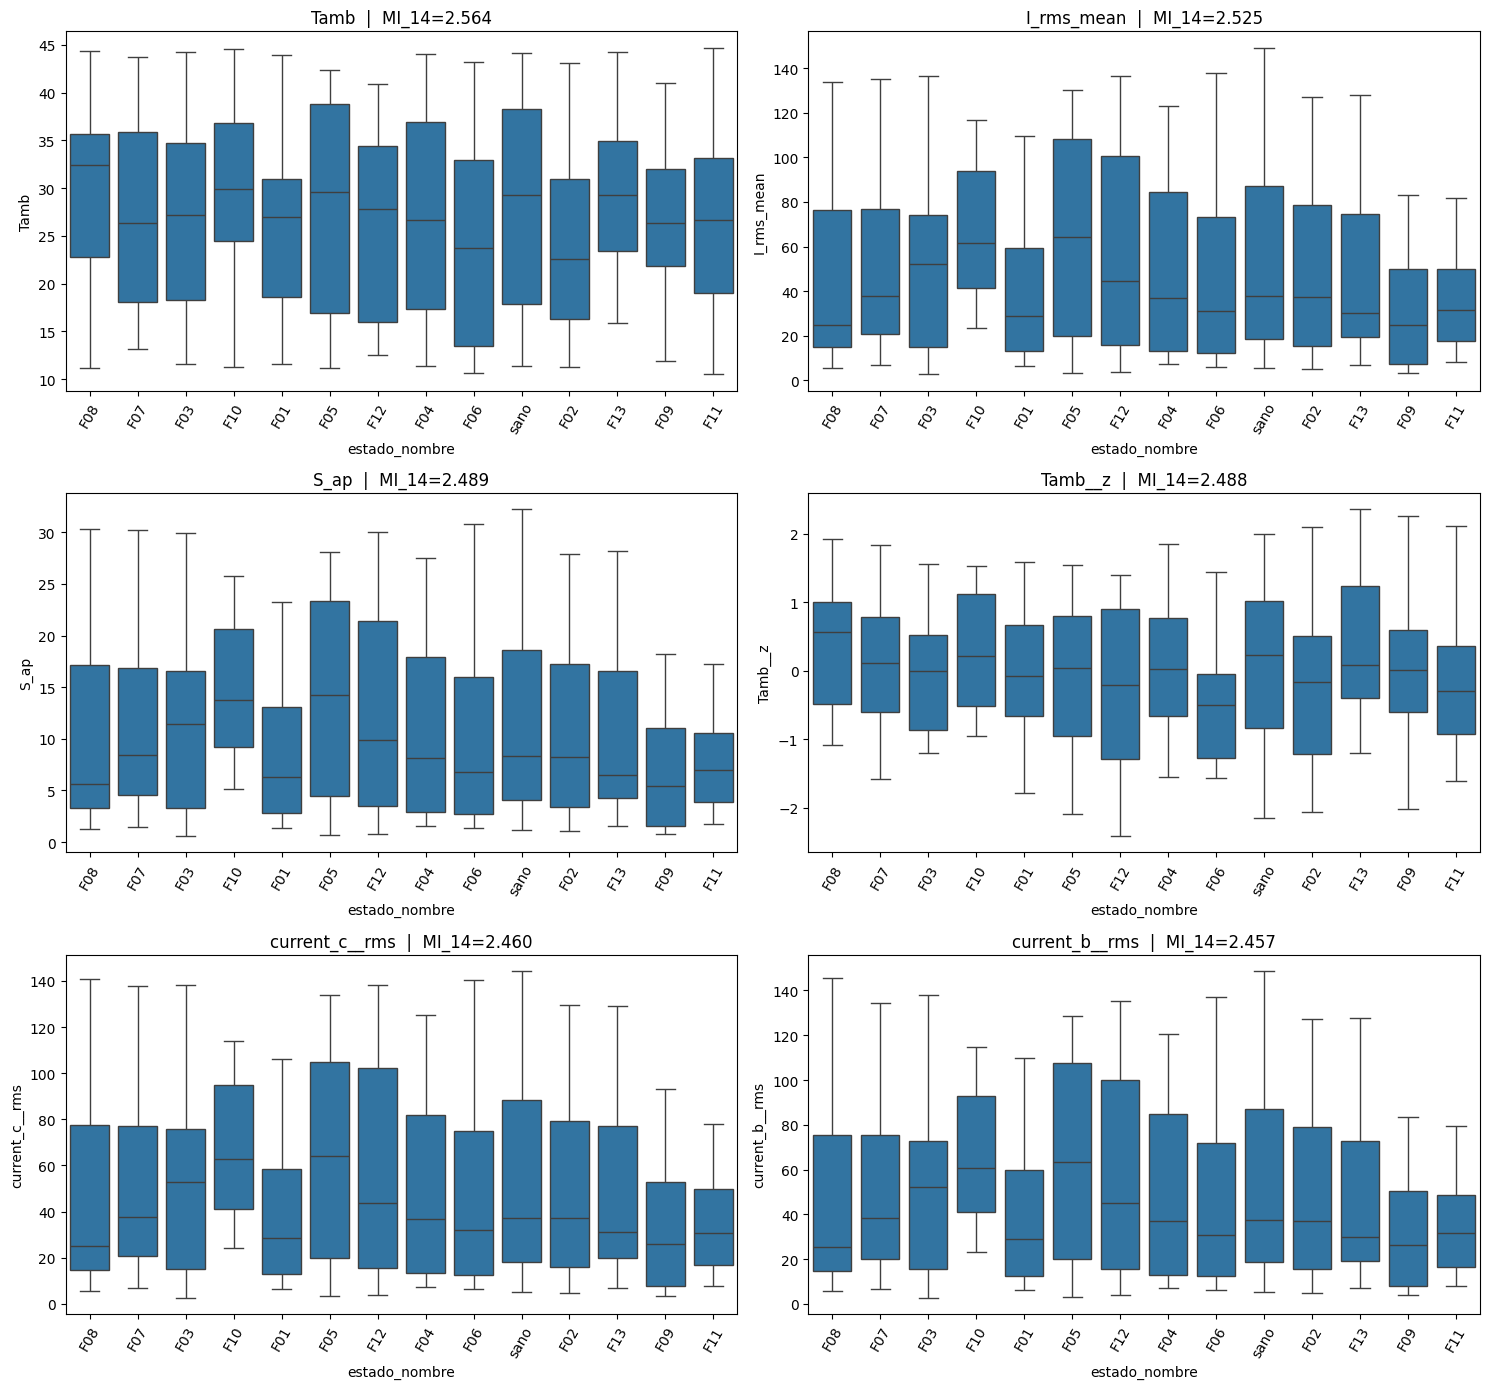

In [ ]:
top6 = (
    mi.sort_values("MI_14", ascending=False)
      .head(6)
      .index
      .tolist()
)

plot_df = X_num.copy()
plot_df["estado_nombre"] = [
    ESTADOS[e] for e in estado
]

fig, axes = plt.subplots(
    3, 2,
    figsize=(15, 14)
)

for ax, feat in zip(axes.flat, top6):

    sns.boxplot(
        data=plot_df,
        x="estado_nombre",
        y=feat,
        ax=ax,
        fliersize=1
    )

    ax.set_title(
        f"{feat}  |  MI_14={mi.loc[feat, 'MI_14']:.3f}"
    )

    ax.tick_params(
        axis="x",
        rotation=60
    )

plt.tight_layout()
plt.show()

### Qué hacemos con las nuevas variables fisicas?

In [ ]:
fis_audit = mi.loc[FIS_FEATS, [
    "MI_binary",
    "MI_14",
    "MI_family",
    "specificity_gain"
]].copy()

fis_audit = fis_audit.join(
    fis_redundancy.set_index("fis")[
        [
            "max_abs_pearson",
            "closest_pearson",
            "max_abs_spearman",
            "closest_spearman",
        ]
    ]
)

fis_audit["rank_MI14"] = (
    fis_audit["MI_14"]
    .rank(ascending=False)
)

fis_audit["rank_family"] = (
    fis_audit["MI_family"]
    .rank(ascending=False)
)

display(
    fis_audit.sort_values(
        ["MI_14", "MI_family"],
        ascending=False
    )
)

,MI_binary,MI_14,MI_family,specificity_gain,max_abs_pearson,closest_pearson,max_abs_spearman,closest_spearman,rank_MI14,rank_family
feature,,,,,,,,,,
S_ap,0.370132,2.488718,1.059284,-0.011905,0.999618,I_rms_mean,0.999776,I_rms_mean,1.0,1.0
I_por_rpm,0.316496,2.382228,1.023631,0.029762,0.919258,current_c__rms,0.964977,current_c__rms,2.0,2.0
I_por_flow,0.310733,2.263669,0.942417,0.000000,0.751598,current_c__rms,0.902025,current_b__rms,3.0,4.0
p_in_n,0.283689,2.231837,0.945915,0.029762,0.898112,rpm_mean,0.993050,rpm_mean,4.0,3.0
flow_n,0.274666,2.141331,0.903590,0.017857,0.877542,flow_mean,0.879708,flow_mean,5.0,5.0
acc_radial_b__rms_n,0.291264,2.093277,0.826495,-0.017857,0.685006,acc_radial_b__rms,0.650221,acc_radial_b__rms,6.0,7.0
vib_tot,0.253136,2.056565,0.822151,0.059524,0.704859,acc_radial_a__rms,0.816353,rpm_mean,7.0,8.0
acc_radial_a__rms_n,0.260725,1.996211,0.802419,0.011905,0.730998,acc_radial_a__rms,0.830694,rpm_mean,8.0,10.0
acc_axial__rms_n,0.233754,1.990685,0.815257,0.065476,0.895334,acc_axial__rms,0.844581,rpm_mean,9.0,9.0


Más adelante vimos que la combinación de las variables aunque parezcan muchas aportan más información juntas que individualmente, e incluso al aplicar el dataset completo el rendimiento de ambas es mayor que la suma de sus rendimientos individuales.

## 4. Protocolo de evaluación

Todo lo que sigue usa estas funciones y esta partición. Estaban duplicadas en
cuatro lugares distintos del notebook original; acá se definen una sola vez.

`compute_score` necesita el DataFrame de verdad completo (etiquetas y severidades)
más una entrega con `window_id` y las 13 probabilidades. `evaluar` arma esa entrega
desde una matriz OOF y devuelve las tres componentes; `correr` y `benchmark`
producen el OOF con la partición agrupada.

La partición es `StratifiedGroupKFold(5)` agrupando por `machine_id`: estratifica
por estado para que las fallas raras aparezcan en cada fold, y mantiene cada
máquina entera de un solo lado. Es la única partición que imita la relación real
entre train y test, donde las máquinas son disjuntas.

Se evalúa también **por fold**, para tener el desvío que decide si una mejora es
real o ruido.


In [ ]:
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

MODELOS = {
    "LightGBM": lambda: lgb.LGBMClassifier(
        objective="multiclass", num_class=14, n_estimators=600, learning_rate=0.05,
        num_leaves=31, min_child_samples=20, subsample=0.9, subsample_freq=1,
        colsample_bytree=0.8, reg_lambda=1.0, verbose=-1, random_state=RANDOM_STATE),
    "XGBoost": lambda: xgb.XGBClassifier(
        objective="multi:softprob", num_class=14, n_estimators=600, learning_rate=0.05,
        max_depth=6, min_child_weight=3, subsample=0.9, colsample_bytree=0.8,
        reg_lambda=1.0, tree_method="hist", verbosity=0, random_state=RANDOM_STATE),
    "CatBoost": lambda: CatBoostClassifier(
        loss_function="MultiClass", iterations=600, learning_rate=0.05, depth=6,
        l2_leaf_reg=3.0, random_seed=RANDOM_STATE, verbose=0, allow_writing_files=False),
    "RandomForest": lambda: make_pipeline(
        SimpleImputer(strategy="median"),
        RandomForestClassifier(n_estimators=600, min_samples_leaf=2, max_features="sqrt",
                               n_jobs=-1, random_state=RANDOM_STATE)),
    "ExtraTrees": lambda: make_pipeline(
        SimpleImputer(strategy="median"),
        ExtraTreesClassifier(n_estimators=600, min_samples_leaf=2, max_features="sqrt",
                             n_jobs=-1, random_state=RANDOM_STATE)),
    "RegLogistica": lambda: make_pipeline(
        SimpleImputer(strategy="median"), StandardScaler(),
        LogisticRegression(max_iter=2000, C=0.5, random_state=RANDOM_STATE)),
}

# Combinaciones de ensamble que se evalúan en todo el notebook.
# (la etiqueta "LightGBM solo (mejor individual)" del original era incorrecta:
#  el mejor individual sobre ana_z es XGBoost, no LightGBM)
CANDIDATOS = {
    "LightGBM solo":           ["LightGBM"],
    "LGB + XGB":               ["LightGBM", "XGBoost"],
    "LGB + XGB + Cat":         ["LightGBM", "XGBoost", "CatBoost"],
    "LGB + XGB + Cat + RF":    ["LightGBM", "XGBoost", "CatBoost", "RandomForest"],
    "LGB + RF + RegLogistica": ["LightGBM", "RandomForest", "RegLogistica"],
}

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
FOLDS = list(cv.split(X_train, estado, train.machine_id.to_numpy()))
for k, (a, b) in enumerate(FOLDS):
    print("fold %d: %4d ajuste / %3d validación | máquinas de validación: %d"
          % (k, len(a), len(b), train.machine_id.iloc[b].nunique()))


fold 0: 1407 ajuste / 343 validación | máquinas de validación: 5
fold 1: 1386 ajuste / 364 validación | máquinas de validación: 5
fold 2: 1358 ajuste / 392 validación | máquinas de validación: 6
fold 3: 1407 ajuste / 343 validación | máquinas de validación: 5
fold 4: 1442 ajuste / 308 validación | máquinas de validación: 5


In [ ]:
def evaluar(proba13, idx=None):
    """proba13: (n, 13) alineado con `train`. idx: subconjunto de filas."""
    idx = np.arange(len(train)) if idx is None else idx
    entrega = pd.DataFrame({"window_id": train.window_id.iloc[idx].to_numpy()})
    for j, f in enumerate(FAULT_IDS):
        entrega[f] = np.clip(proba13[idx][:, j], 0, 1)
    return compute_score(train.iloc[idx], entrega)["overall"]

def familia_de(e):
    return "sano" if e == 0 else FAMILIES[FAULT_IDS[e - 1]]

def correr(nombre, ctor, X, folds=None, config=None):
    """OOF de un modelo sobre la matriz X, con la partición agrupada por máquina."""
    folds = FOLDS if folds is None else folds
    oof = np.zeros((len(X), 14))
    for a, b in folds:
        modelo = ctor()
        modelo.fit(X.iloc[a], estado[a])
        oof[b] = modelo.predict_proba(X.iloc[b])
    r = evaluar(oof[:, 1:])
    por_fold = [evaluar(oof[:, 1:], b)["final_score"] for _, b in folds]
    fam_real = np.array([familia_de(e) for e in estado])
    fam_pred = np.array([familia_de(e) for e in oof.argmax(1)])
    fila = dict(
        modelo=nombre, final=r["final_score"], cost=r["cost_score"],
        prob=r["prob_score"], diag=r["diag_score"], brier=r["brier"],
        macro_f1=r["macro_f1"], acc_estado=(oof.argmax(1) == estado).mean(),
        acc_familia=(fam_real == fam_pred).mean(), sd_folds=float(np.std(por_fold)))
    return oof, ({"config": config, **fila} if config is not None else fila)

def benchmark(X, config, modelos=None, folds=None, verbose=True):
    """Corre todos los modelos sobre X. Devuelve (tabla, dict de OOFs)."""
    modelos = MODELOS if modelos is None else modelos
    oofs, filas = {}, []
    for nombre, ctor in modelos.items():
        oofs[nombre], fila = correr(nombre, ctor, X, folds=folds, config=config)
        filas.append(fila)
        if verbose:
            print("  %-13s | final=%6.2f | cost=%5.2f | prob=%5.2f | diag=%5.2f | sd_folds=%.2f"
                  % (nombre, fila["final"], fila["cost"], fila["prob"],
                     fila["diag"], fila["sd_folds"]))
    return pd.DataFrame(filas), oofs

def ensamblar(oofs, nombres):
    """Promedio simple de probabilidades, renormalizado."""
    P = np.mean([oofs[n] for n in nombres], axis=0)
    return P / P.sum(axis=1, keepdims=True)

def evaluar_ensambles(oofs, candidatos, folds=None):
    folds = FOLDS if folds is None else folds
    filas = []
    for nombre, combo in candidatos.items():
        P = ensamblar(oofs, combo)
        r = evaluar(P[:, 1:])
        por_fold = [evaluar(P[:, 1:], b)["final_score"] for _, b in folds]
        filas.append(dict(ensamble=nombre, final=r["final_score"], cost=r["cost_score"],
                          prob=r["prob_score"], diag=r["diag_score"],
                          sd_folds=float(np.std(por_fold)),
                          por_fold=" ".join("%.1f" % v for v in por_fold)))
    return pd.DataFrame(filas)

def mostrar(tabla, index=False):
    """Formato común para todas las tablas de resultados."""
    fmt = {"final": "{:.2f}", "cost": "{:.2f}", "prob": "{:.2f}", "diag": "{:.2f}",
           "sd_folds": "{:.2f}", "brier": "{:.4f}", "macro_f1": "{:.3f}",
           "acc_estado": "{:.3f}", "acc_familia": "{:.3f}"}
    s = tabla.style.format({k: v for k, v in fmt.items() if k in tabla.columns})
    if not index:
        s = s.hide(axis="index")
    return s.background_gradient(subset=["final"], cmap="BuGn")


In [ ]:
FAMS = sorted(set(FAMILIES.values()))
FIDX = {g: np.array([i for i, f in enumerate(FAULT_IDS) if FAMILIES[f] == g]) for g in FAMS}

def acciones(P13):
    S = P13.sum(1); n = len(P13)
    c = np.empty((n, 3 + len(FAMS)))
    c[:, 0] = 10 * S; c[:, 1] = 7 + 3.5 * S; c[:, 2] = 12
    for k, g in enumerate(FAMS):
        c[:, 3 + k] = 4 + 8 * (S - P13[:, FIDX[g]].sum(1))
    nom = np.array(["MONITOR", "DERATE", "STOP"] + ["INSPECT_" + g for g in FAMS])
    return pd.Series(nom[c.argmin(1)])

# Modificado: P0 debe ser solo las probabilidades numéricas de las 13 fallas (no 'sano')
P0_prev = np.tile(prev.loc[FAULT_IDS, "prevalencia"].to_numpy(), (len(train), 1))
print("acciones que elige la regla para el baseline P0:")
print(acciones(P0_prev).value_counts().to_string())

acciones que elige la regla para el baseline P0:
INSPECT_mechanical    1750


### Piso y techo

Sin un piso y un techo, los números no significan nada. El piso es el baseline
oficial de la cátedra (prevalencia constante). El techo es el oráculo: lo que
daría el modelo perfecto.


In [ ]:
# Piso: P0, la prevalencia observada repetida en todas las filas.
P0 = np.tile(train[LABEL_COLUMNS].mean().to_numpy(), (len(train), 1))
r_p0 = evaluar(P0)

# Techo: las etiquetas exactas.
r_or = evaluar(train[LABEL_COLUMNS].to_numpy(dtype=float))

print("P0 prevalencia   final = %6.2f  (cost %5.2f)" % (r_p0["final_score"], r_p0["cost_score"]))
print("oráculo perfecto final = %6.2f  (cost %5.2f)" % (r_or["final_score"], r_or["cost_score"]))
print("""
El oráculo no llega a 100: aun conociendo la falla exacta hay que pagar la
inspección de $4. Con naive_cost = %.2f y costo mínimo alcanzable
0.876 x 4 = %.2f, cost_score se planta en %.2f.""" %
      (r_or["naive_cost"], 0.876 * 4, r_or["cost_score"]))

P0 prevalencia   final =  30.78  (cost 22.55)
oráculo perfecto final =  73.96  (cost 62.80)

El oráculo no llega a 100: aun conociendo la falla exacta hay que pagar la
inspección de $4. Con naive_cost = 9.42 y costo mínimo alcanzable
0.876 x 4 = 3.50, cost_score se planta en 62.80.


## 5. Benchmark multimodelo (tabular)

Seis algoritmos, la misma partición, la misma métrica. Se corre sobre las dos
matrices tabulares para poder atribuir la mejora a las features y no al modelo:

- **`ana_z`** (92 columnas): las 46 originales más su z-score por máquina.
- **`fis_z`** (174 columnas): agrega las 42 variables físicas de la sección 3.


In [ ]:
tabla_ana, oofs = benchmark(X_train, "ana_z")


  LightGBM      | final= 43.30 | cost=33.97 | prob=78.53 | diag=38.10 | sd_folds=4.87
  XGBoost       | final= 45.52 | cost=36.91 | prob=80.02 | diag=36.80 | sd_folds=4.68
  CatBoost      | final= 43.70 | cost=34.61 | prob=81.43 | diag=31.84 | sd_folds=4.10
  RandomForest  | final= 44.44 | cost=35.94 | prob=82.65 | diag=27.59 | sd_folds=5.10
  ExtraTrees    | final= 43.28 | cost=35.23 | prob=81.93 | diag=22.36 | sd_folds=4.57
  RegLogistica  | final= 45.19 | cost=37.69 | prob=76.33 | diag=35.40 | sd_folds=3.13


In [ ]:
tabla = (tabla_ana.drop(columns="config")
         .sort_values("final", ascending=False)
         .reset_index(drop=True))
tabla.insert(2, "vs_P0", tabla.final - r_p0["final_score"])
tabla.insert(3, "pct_techo", 100 * tabla.final / r_or["final_score"])
display(tabla.style.format({
    "final": "{:.2f}", "vs_P0": "+{:.2f}", "pct_techo": "{:.1f}%", "cost": "{:.2f}",
    "prob": "{:.2f}", "diag": "{:.2f}", "brier": "{:.4f}", "macro_f1": "{:.3f}",
    "acc_estado": "{:.3f}", "acc_familia": "{:.3f}", "sd_folds": "{:.2f}"})
    .background_gradient(subset=["final"], cmap="BuGn"))


,modelo,final,vs_P0,pct_techo,cost,prob,diag,brier,macro_f1,acc_estado,acc_familia,sd_folds
0,XGBoost,45.52,+14.74,61.5%,36.91,80.02,36.80,0.0499,0.368,0.446,0.616,4.68
1,RegLogistica,45.19,+14.41,61.1%,37.69,76.33,35.40,0.0592,0.354,0.392,0.615,3.13
2,RandomForest,44.44,+13.66,60.1%,35.94,82.65,27.59,0.0434,0.276,0.467,0.605,5.10
3,CatBoost,43.70,+12.91,59.1%,34.61,81.43,31.84,0.0464,0.318,0.450,0.587,4.10
4,LightGBM,43.30,+12.51,58.5%,33.97,78.53,38.10,0.0537,0.381,0.441,0.588,4.87
5,ExtraTrees,43.28,+12.50,58.5%,35.23,81.93,22.36,0.0452,0.224,0.454,0.583,4.57


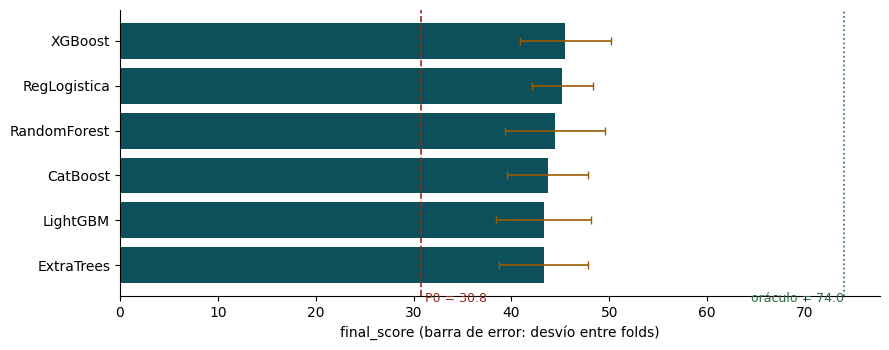

In [ ]:
fig, ax = plt.subplots(figsize=(9, 3.6))
orden = tabla.sort_values("final")
ax.barh(orden.modelo, orden.final, xerr=orden.sd_folds, color="#0E4F5C",
        error_kw=dict(ecolor="#9A5B00", capsize=3, lw=1.2))
ax.axvline(r_p0["final_score"], color="#8F2A1D", ls="--", lw=1.2)
ax.text(r_p0["final_score"], -0.6, " P0 = %.1f" % r_p0["final_score"],
        color="#8F2A1D", fontsize=9, va="top")
ax.axvline(r_or["final_score"], color="#2E6B45", ls=":", lw=1.2)
ax.text(r_or["final_score"], -0.6, " oráculo = %.1f" % r_or["final_score"],
        color="#2E6B45", fontsize=9, va="top", ha="right")
ax.set_xlabel("final_score (barra de error: desvío entre folds)")
ax.set_xlim(0, r_or["final_score"] * 1.05)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

### El spread entre algoritmos es menor que el ruido

Este es el resultado principal de la etapa tabular, y no es el que se esperaba.
Los seis modelos caen entre **43.28 y 45.52**: 2.24 puntos de spread, contra un
desvío entre folds de **3.13 a 5.10** en cada uno de ellos. Las barras de error se
solapan casi por completo.

**Cambiar de algoritmo no mueve la aguja.** Los seis, incluida una regresión
logística, aterrizan en la misma banda. Cuando modelos con sesgos inductivos tan
distintos convergen al mismo número, el límite no está en el algoritmo sino en la
información disponible en las features.

Vale la pena mirar la descomposición, porque los modelos no fallan igual.


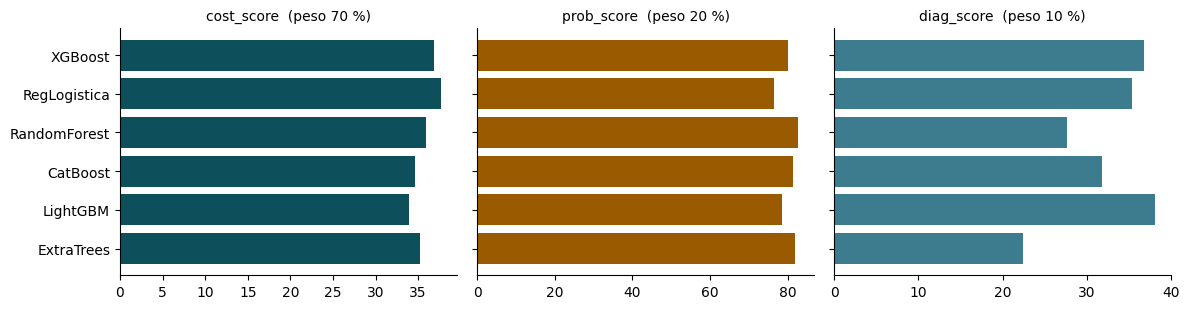

              cost  prob  diag
modelo                        
XGBoost      36.91 80.02 36.80
RegLogistica 37.69 76.33 35.40
RandomForest 35.94 82.65 27.59
CatBoost     34.61 81.43 31.84
LightGBM     33.97 78.53 38.10
ExtraTrees   35.23 81.93 22.36


In [ ]:
comp = tabla.set_index("modelo")[["cost", "prob", "diag"]]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), sharey=True)
for ax, col, color, peso in zip(axes, comp.columns,
                                ["#0E4F5C", "#9A5B00", "#3D7B8F"], ["70 %", "20 %", "10 %"]):
    ax.barh(comp.index, comp[col], color=color)
    ax.set_title("%s_score  (peso %s)" % (col, peso), fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    ax.invert_yaxis()
plt.tight_layout(); plt.show()

print(comp.to_string(float_format=lambda v: "%.2f" % v))

Los boosters (LightGBM 38.10, XGBoost 36.80 de `diag_score`) discriminan mejor y
empujan más ventanas por encima del umbral de 0.5 del macro-F1. Los bagging
(RandomForest 82.65, ExtraTrees 81.93 de `prob_score`) promedian muchos árboles y
salen mejor calibrados, con Brier más bajo — LightGBM, el mejor en `diag`, es
anteúltimo en `prob` con 78.53.

Nadie gana en las tres componentes. **Eso es una invitación al ensamble**, no a
elegir un ganador: hay diversidad real que explotar.

### Importancia de features: modelos vs. información mutua

Contraste entre lo que cada modelo usa y lo que la MI dice que informa. Se calcula
sobre `X_eda`, que es la matriz `fis_z` sin las columnas de varianza cero (168
columnas en vez de 174); para modelos de árboles las constantes son irrelevantes,
así que la comparación es válida.


In [ ]:
MODEL_IMPORTANCE_NAMES = [
    "LightGBM",
    "RandomForest",
    "CatBoost",
    "RegLogistica",
]


def extract_importance(model):

    # CatBoost
    if hasattr(model, "get_feature_importance"):
        return np.asarray(model.get_feature_importance(), dtype=float)

    # LightGBM / otros árboles
    if hasattr(model, "feature_importances_"):
        return np.asarray(model.feature_importances_, dtype=float)

    # Pipelines
    if hasattr(model, "named_steps"):

        last = list(model.named_steps.values())[-1]

        if hasattr(last, "feature_importances_"):
            return np.asarray(last.feature_importances_, dtype=float)

        if hasattr(last, "coef_"):
            return np.mean(np.abs(last.coef_),axis=0)

    raise TypeError(f"No pude extraer importancia de {type(model)}")


importance_tables = []

for nombre in MODEL_IMPORTANCE_NAMES:

    fold_importances = []
    for a, b in FOLDS:
        model = MODELOS[nombre]()
        model.fit( X_eda.iloc[a], estado[a])
        imp = extract_importance(model)
        assert len(imp) == X_eda.shape[1]
        imp = imp / (imp.sum() + 1e-12)

        fold_importances.append(imp)

    mean_imp = np.mean(fold_importances,axis=0)

    df_imp = pd.DataFrame({
        "feature": X_eda.columns,
        "grupo": [FEATURE_GROUP[c] for c in X_eda.columns],
        "importance": mean_imp,
        "modelo": nombre,
    })

    importance_tables.append(df_imp)


model_importance = pd.concat(importance_tables, ignore_index=True)

for nombre in MODEL_IMPORTANCE_NAMES:

    print(f"\n===== {nombre} =====")
    display(
        model_importance[model_importance["modelo"] == nombre]
        .sort_values("importance", ascending=False).head(25)
    )


===== LightGBM =====


,feature,grupo,importance,modelo
2,acc_radial_a__kurtosis,original,0.023380,LightGBM
13,acc_axial__rms,original,0.021543,LightGBM
58,rad_b_a,fis,0.019804,LightGBM
0,Tamb,original,0.019628,LightGBM
160,flow_n__z,z,0.018924,LightGBM
91,acc_radial_b__rms__z,z,0.017861,LightGBM
7,acc_radial_b__rms,original,0.017129,LightGBM
3,acc_radial_a__crest,original,0.016366,LightGBM
124,rpm_mean__z,z,0.015447,LightGBM
84,Tamb__z,z,0.014988,LightGBM



===== RandomForest =====


,feature,grupo,importance,modelo
181,acc_axial__rms,original,0.020835,RandomForest
226,rad_b_a,fis,0.020321,RandomForest
225,ax_rad,fis,0.019864,RandomForest
185,acc_axial__2x,original,0.017404,RandomForest
214,acc_radial_a__crest_n,fis,0.017053,RandomForest
296,acc_radial_a__2x1x__z,z,0.016903,RandomForest
171,acc_radial_a__crest,original,0.016691,RandomForest
173,acc_radial_a__2x,original,0.016175,RandomForest
177,acc_radial_b__crest,original,0.015287,RandomForest
309,ax_rad__z,z,0.014887,RandomForest



===== CatBoost =====


,feature,grupo,importance,modelo
338,acc_radial_a__kurtosis,original,0.042290,CatBoost
394,rad_b_a,fis,0.031471,CatBoost
427,acc_radial_b__rms__z,z,0.031084,CatBoost
382,acc_radial_a__crest_n,fis,0.025866,CatBoost
424,acc_radial_a__1x__z,z,0.022398,CatBoost
466,acc_radial_a__crest_n__z,z,0.021778,CatBoost
349,acc_axial__rms,original,0.021598,CatBoost
463,acc_radial_a__1x_r__z,z,0.020091,CatBoost
477,ax_rad__z,z,0.018984,CatBoost
422,acc_radial_a__kurtosis__z,z,0.018916,CatBoost



===== RegLogistica =====


,feature,grupo,importance,modelo
664,flow_n__z,z,0.014697,RegLogistica
599,acc_radial_b__2x__z,z,0.014482,RegLogistica
631,acc_radial_a__1x_r__z,z,0.013107,RegLogistica
590,acc_radial_a__kurtosis__z,z,0.013000,RegLogistica
646,rad_b_a__z,z,0.012489,RegLogistica
633,acc_radial_a__lkurt__z,z,0.012067,RegLogistica
518,acc_axial__kurtosis,original,0.011674,RegLogistica
592,acc_radial_a__1x__z,z,0.011040,RegLogistica
636,acc_radial_b__1x_r__z,z,0.010887,RegLogistica
634,acc_radial_a__crest_n__z,z,0.010750,RegLogistica


In [ ]:
compare = mi[["grupo", "MI_14", "MI_family"]].copy()

for nombre in MODEL_IMPORTANCE_NAMES:
    tmp = (
        model_importance[model_importance["modelo"] == nombre]
        .set_index("feature")["importance"]
    )

    compare[f"imp_{nombre}"] = tmp

for nombre in MODEL_IMPORTANCE_NAMES:

    rank_model = compare[f"imp_{nombre}"].rank(ascending=False)
    rank_mi = compare["MI_14"].rank(ascending=False)
    rho = rank_model.corr(rank_mi,method="spearman")

    top_model = set(compare.nlargest(20, f"imp_{nombre}").index)

    top_mi = set(compare.nlargest(20,"MI_14").index)

    jaccard = (len(top_model & top_mi) / len(top_model | top_mi))

    print(
        f"{nombre:15s}"
        f" | Spearman MI_14 = {rho: .3f}"
        f" | Jaccard top20 = {jaccard: .3f}"
    )

LightGBM        | Spearman MI_14 =  0.741 | Jaccard top20 =  0.111
RandomForest    | Spearman MI_14 =  0.682 | Jaccard top20 =  0.026
CatBoost        | Spearman MI_14 =  0.707 | Jaccard top20 =  0.026
RegLogistica    | Spearman MI_14 =  0.527 | Jaccard top20 =  0.000


### Ensambles por promedio simple

Como ningún modelo gana en las tres componentes, se promedian probabilidades.


In [ ]:
display(mostrar(evaluar_ensambles(oofs, CANDIDATOS)))

ensamble,final,cost,prob,diag,sd_folds,por_fold
LightGBM solo,43.30,33.97,78.53,38.10,4.87,42.5 37.1 42.9 51.8 40.4
LGB + XGB,43.73,34.46,79.59,36.93,4.82,41.5 38.3 42.8 52.6 42.0
LGB + XGB + Cat,44.42,35.08,80.87,36.84,4.64,41.3 39.4 44.3 52.8 42.8
LGB + XGB + Cat + RF,44.66,35.41,81.74,35.25,4.35,41.0 40.2 44.9 52.4 43.6
LGB + RF + RegLogistica,47.33,39.18,82.10,34.92,3.27,44.4 45.7 49.0 52.5 43.7


El promedio simple da entre +0.4 y +4.0 puntos sobre LightGBM solo, y el mejor
candidato (`LGB + RF + RegLogistica`, 47.33) supera también al mejor individual de
la tabla anterior (XGBoost, 45.52) por 1.8 puntos, con el desvío entre folds más
bajo de todos (3.27).

Una advertencia honesta: ese candidato salió de buscar exhaustivamente entre las
41 combinaciones posibles sobre esta misma partición. **La búsqueda sobre el OOF
infla la estimación** — es la trampa de sobreajuste al OOF que figura en el kit del
equipo. La celda siguiente es la que lo dirime.


In [ ]:
# Confirmación con OTRA partición. Si la ventaja sobrevive a un cambio de
# semilla de folds, es real; si se evapora, era selección sobre el OOF.
SEMILLA_CONTROL = 2024
folds_ctrl = list(StratifiedGroupKFold(5, shuffle=True, random_state=SEMILLA_CONTROL)
                  .split(X_train, estado, train.machine_id.to_numpy()))

_, oofs_ctrl = benchmark(X_train, "ana_z / semilla 2024", folds=folds_ctrl, verbose=False)

print("%-34s %10s %10s" % ("candidato", "semilla 42", "semilla 2024"))
for nombre, combo in CANDIDATOS.items():
    a = evaluar(ensamblar(oofs,      combo)[:, 1:])["final_score"]
    b = evaluar(ensamblar(oofs_ctrl, combo)[:, 1:])["final_score"]
    print("%-34s %10.2f %10.2f" % (nombre, a, b))

### Resultado de la confirmación

| Candidato | semilla 42 | semilla 2024 | vs. LightGBM solo |
|---|---|---|---|
| LightGBM solo | 43.30 | 43.97 | — |
| LGB + XGB | 43.73 | 44.34 | +0.43 / +0.37 |
| LGB + XGB + Cat | 44.42 | 45.15 | +1.12 / +1.18 |
| LGB + XGB + Cat + RF | 44.66 | 45.23 | +1.36 / +1.26 |
| **LGB + RF + RegLogistica** | **47.33** | **46.44** | **+4.03 / +2.47** |

Dos lecturas:

1. **El orden se mantiene idéntico en las dos semillas**, y los cuatro ensambles
   mejoran a LightGBM solo en ambas. La ventaja del candidato sospechoso —el que
   había salido de buscar entre 41 combinaciones— se reduce de +4.03 a +2.47 al
   cambiar de partición, pero no se evapora. Eso descarta que fuera puro
   sobreajuste de selección, aunque confirma que +4.03 era optimista.
2. **La partición mueve tanto como el ensamble.** LightGBM pasa de 43.30 a 43.97
   sin que nada del modelo haya cambiado. Cualquier diferencia menor a ~1 punto
   entre configuraciones hay que leerla como ruido.

La lectura de por qué el ensamble funciona: la regresión logística es el único
modelo **lineal** del grupo. Sus errores están descorrelacionados de los de los
árboles, y en un promedio eso vale más que su desempeño individual. Es el
argumento clásico a favor de la diversidad por sobre la calidad individual.

### Con variables físicas (`fis_z`, 174 columnas)

Mismo benchmark, misma partición, misma métrica. La única diferencia es la matriz
de entrada: se agregan las 42 variables físicas de la sección 3 y sus z-scores.


In [ ]:
X_train_fis_z = construir(train, "fis_z")
X_test_fis_z  = construir(test,  "fis_z")
print("fis_z -> train", X_train_fis_z.shape, "| test", X_test_fis_z.shape, "\n")

tabla_fis, oofs_fis = benchmark(X_train_fis_z, "fis_z")

display(mostrar(tabla_fis.drop(columns="config")
                .sort_values("final", ascending=False).reset_index(drop=True),
                index=True))
display(mostrar(evaluar_ensambles(oofs_fis, CANDIDATOS)
                .sort_values("final", ascending=False)))


Dimensiones de X_train con variables físicas y z-score: (1750, 174)

Evaluando modelos individuales con variables físicas y z-score...
  - LightGBM: final = 48.83 (sd entre folds = 6.62)
  - XGBoost: final = 49.74 (sd entre folds = 6.00)
  - CatBoost: final = 50.86 (sd entre folds = 6.43)
  - RandomForest: final = 49.40 (sd entre folds = 5.83)
  - ExtraTrees: final = 47.09 (sd entre folds = 5.46)
  - RegLogistica: final = 50.26 (sd entre folds = 3.77)

--- Resultados de modelos individuales con variables físicas y z-score ---


,modelo,final,cost,prob,diag,brier,macro_f1,acc_estado,acc_familia,sd_folds
0,CatBoost,50.86,43.00,83.86,39.85,0.0403,0.399,0.518,0.678,6.43
1,RegLogistica,50.26,42.11,80.26,47.28,0.0493,0.473,0.497,0.669,3.77
2,XGBoost,49.74,41.09,82.69,44.41,0.0433,0.444,0.501,0.653,6.00
3,RandomForest,49.40,42.11,83.94,31.33,0.0402,0.313,0.510,0.659,5.83
4,LightGBM,48.83,39.90,81.49,46.09,0.0463,0.461,0.500,0.645,6.62
5,ExtraTrees,47.09,39.51,83.45,27.39,0.0414,0.274,0.512,0.643,5.46



Evaluando ensambles con variables físicas y z-score...
  - LightGBM solo (mejor individual): final = 48.83 (sd entre folds = 6.62)
  - LGB + XGB: final = 49.64 (sd entre folds = 6.02)
  - LGB + XGB + Cat: final = 50.49 (sd entre folds = 5.68)
  - LGB + XGB + Cat + RF: final = 50.72 (sd entre folds = 5.70)
  - LGB + RF + RegLogistica: final = 51.98 (sd entre folds = 5.44)

--- Resultados de ensambles con variables físicas y z-score ---


ensamble,final,cost,prob,diag,sd_folds,por_fold
LGB + RF + RegLogistica,51.98,43.51,84.45,46.30,5.44,53.9 48.6 52.8 59.2 42.9
LGB + XGB + Cat + RF,50.72,42.44,84.08,41.92,5.70,51.6 46.9 52.3 58.7 41.7
LGB + XGB + Cat,50.49,42.00,83.58,43.70,5.68,51.7 45.9 52.1 58.3 41.7
LGB + XGB,49.64,40.94,82.45,44.89,6.02,51.5 43.8 49.4 58.9 41.9
LightGBM solo (mejor individual),48.83,39.90,81.49,46.09,6.62,51.9 43.1 48.8 58.3 39.5


**Las variables físicas son la mejora más grande de todo el notebook.** Cada modelo
gana entre +4.0 y +7.2 puntos respecto de `ana_z`:

| Modelo | `ana_z` | `fis_z` | Δ |
|---|---|---|---|
| CatBoost | 43.70 | **50.86** | +7.16 |
| RegLogistica | 45.19 | 50.26 | +5.07 |
| XGBoost | 45.52 | 49.74 | +4.22 |
| RandomForest | 44.44 | 49.40 | +4.96 |
| LightGBM | 43.30 | 48.83 | +5.53 |
| ExtraTrees | 43.28 | 47.09 | +3.81 |

El ensamble `LGB + RF + RegLogistica` vuelve a ganar y llega a **51.98**. Se
confirma lo que decía el spread de la sección anterior: la palanca son las
features, no el algoritmo.

### Conclusión de la etapa tabular

Con descriptores tabulares y variables físicas derivadas se llega a **51.98**
(ensamble) contra un piso de 30.78 y un techo teórico de 73.96 del oráculo. Unos
dos tercios de lo alcanzable.

Lo que quedó establecido:

- **Buscar un algoritmo mejor es tiempo perdido**, y el tuneo de hiperparámetros
  todavía más: mueve menos que el cambio de familia de modelo, que ya vimos que
  mueve 2.24 puntos sobre un ruido de partición de 3 a 5.
- **El ensamble por diversidad deliberada** (LightGBM + RandomForest + regresión
  logística) da entre +1.1 y +4.0 según la matriz, y sale de modelos que ya están
  entrenados. Es la mejora más barata disponible.
- **`diag_score` es donde más margen relativo queda**: pesa 10 % y está en 27–47
  según el modelo, contra `prob_score` que ya está en 80–84.

Lo que falta probar: los descriptores tabulares traen un solo armónico por canal
(1x y 2x), y las frecuencias que separan las fallas de rodamiento entre sí (BPFO,
BPFI, BSF) no están en la tabla. La confusión intra-familia mecánica —seis de las
trece fallas— no se resuelve con lo que hay acá. La `acc_familia` se estanca en
0.64–0.68, y `cost_score` es exactamente lo que paga por ella. **Las señales crudas
son la vía que queda**, y es la sección 6.


## 6. Señales crudas (NPZ)

Tres canales por ventana: `acc_radial_a` a 20 kHz, `current_a` a 10 kHz y
`pressure_in` a 200 Hz. Cada archivo `raw_signals/S<hash>.npz` contiene una sesión
completa; `raw_signal_index.csv` mapea `window_id` → archivo y canales.

Se extraen features espectrales por canal, se estudia cuánta de esa señal es de la
máquina y no de la falla, y se agrega cada canal de a uno para medir su aporte
marginal.


In [ ]:
from scipy.signal import welch

INDEX_PATH = RAW_ROOT / "raw_signal_index.csv"
index_df = pd.read_csv(INDEX_PATH)

print("index_df:", index_df.shape)
print("\nColumnas del índice:")
print(index_df.columns.tolist())


In [ ]:
def parse_channels(x):

    if pd.isna(x):
        return []

    x = str(x).strip()

    if not x:
        return []

    return [
        ch.strip()
        for ch in x.split("|")
        if ch.strip()
    ]


index_df["channels_parsed"] = (index_df["channels"].apply(parse_channels))

all_channels = sorted({
    ch
    for row in index_df["channels_parsed"]
    for ch in row
})

print("Canales encontrados:")

for ch in all_channels:
    print(" -", ch)

print("\nNúmero de canales por ventana:")

display(
    index_df["channels_parsed"]
    .apply(len)
    .value_counts()
    .sort_index()
)

Canales encontrados:
 - acc_radial_a
 - current_a
 - pressure_in

Número de canales por ventana:


,count
channels_parsed,
3,4032


In [ ]:
def resolve_npz_path(file_value):

    file_value = str(file_value)

    p = Path(file_value)

    candidates = [
        RAW_ROOT / p,
        RAW_ROOT / p.name,
        p,
    ]

    for candidate in candidates:
        if candidate.exists():
            return candidate

    raise FileNotFoundError("\nNo encontró el NPZ.\n"
        f"file = {file_value}\n\n"
        "Probé:\n"
        + "\n".join(
            str(c)for c in candidates))


def load_signal(row, channel):

    npz_path = resolve_npz_path(row["file"])

    key = (
        f"{row['window_id']}"
        f"__{channel}"
    )

    with np.load(npz_path, allow_pickle=False) as data:

        if key not in data.files:

            raise KeyError(f"No existe la clave:\n"
                f"{key}\n"
                f"en:\n"
                f"{npz_path}")

        return np.asarray(data[key],dtype=np.float64)

In [ ]:
print("train:", train.shape)
print("index_df:", index_df.shape)

# Comprobar que estado corresponde fila por fila a train
assert len(estado) == len(train), (
    f"estado tiene {len(estado)} filas "
    f"pero train tiene {len(train)}"
)

# Copiamos train y agregamos estado
df_meta = train.copy()

df_meta["state"] = estado
df_meta["state_name"] = [ESTADOS[s] for s in estado]

# Agregar información del índice NPZ
df_meta = df_meta.merge(
    index_df[["window_id", "file","channels"]],
    on="window_id",
    how="left",
    validate="one_to_one"
)

# Comprobaciones
print("\nDespués del merge:")
print("df_meta:", df_meta.shape)

print("window_id duplicados:",df_meta["window_id"].duplicated().sum())

print("window_id sin archivo NPZ:", df_meta["file"].isna().sum())

print("window_id sin channels:", df_meta["channels"].isna().sum())

print("\nEstados:")
display(df_meta["state_name"].value_counts().sort_index())

print("\nEjemplo:")
display(
    df_meta[
        [
            "window_id",
            "machine_id",
            "session_id",
            "state",
            "state_name",
            "file",
            "channels"
        ]
    ].head()
)

train: (1750, 77)
index_df: (4032, 4)

Después del merge:
df_meta: (1750, 81)
window_id duplicados: 0
window_id sin archivo NPZ: 0
window_id sin channels: 0

Estados:


,count
state_name,
F01,168
F02,168
F03,161
F04,98
F05,112
F06,105
F07,91
F08,112
F09,84



Ejemplo:


,window_id,machine_id,session_id,state,state_name,file,channels
0,W0511a7920bdf7d480000,M0000022,S0511a7920bdf7d48,8,F08,raw_signals/S0511a7920bdf7d48.npz,acc_radial_a|current_a|pressure_in
1,W0511a7920bdf7d480001,M0000022,S0511a7920bdf7d48,8,F08,raw_signals/S0511a7920bdf7d48.npz,acc_radial_a|current_a|pressure_in
2,W0511a7920bdf7d480002,M0000022,S0511a7920bdf7d48,8,F08,raw_signals/S0511a7920bdf7d48.npz,acc_radial_a|current_a|pressure_in
3,W0511a7920bdf7d480003,M0000022,S0511a7920bdf7d48,8,F08,raw_signals/S0511a7920bdf7d48.npz,acc_radial_a|current_a|pressure_in
4,W0511a7920bdf7d480004,M0000022,S0511a7920bdf7d48,8,F08,raw_signals/S0511a7920bdf7d48.npz,acc_radial_a|current_a|pressure_in


In [ ]:
state_counts = (
    df_meta[["state", "state_name"]]
    .drop_duplicates()
    .sort_values("state")
)

print("Estados presentes en train:\n")

display(
    df_meta[["state","state_name"]]
    .value_counts()
    .sort_index()
    .rename("n")
    .reset_index()
)

print("\nEstados faltantes:",
    sorted(
        set(range(14))
        - set(df_meta["state"].unique())
    ))

Estados presentes en train:



,state,state_name,n
0,0,sano,217
1,1,F01,168
2,2,F02,168
3,3,F03,161
4,4,F04,98
5,5,F05,112
6,6,F06,105
7,7,F07,91
8,8,F08,112
9,9,F09,84



Estados faltantes: []


In [ ]:
# NPZ — 9. MUESTRAS REPRESENTATIVAS

STATES_TO_CHECK = [
    0,   # sano
    1,   # F01
    3,   # F03
    8,   # F08
    9,   # F09
    12,  # F12
    13,  # F13
]

sample_rows = []

for state_id in STATES_TO_CHECK:

    subset = df_meta[
        df_meta["state"] == state_id
    ]

    if subset.empty:
        print(f"AVISO: no hay muestras para "
            f"{ESTADOS[state_id]}")
        continue

    sample_rows.append(subset.sample(n=1,random_state=42).iloc[0])

samples_df = pd.DataFrame(sample_rows).reset_index(drop=True)

print("\nMuestras seleccionadas:",len(samples_df))

display(
    samples_df[
        [
            "window_id",
            "machine_id",
            "session_id",
            "state",
            "state_name",
            "file",
            "channels"
        ]])


Muestras seleccionadas: 7


,window_id,machine_id,session_id,state,state_name,file,channels
0,We24d8ebbd317184b0002,M0000041,Se24d8ebbd317184b,0,sano,raw_signals/Se24d8ebbd317184b.npz,acc_radial_a|current_a|pressure_in
1,W7b8e3d476425169c0004,M0000026,S7b8e3d476425169c,1,F01,raw_signals/S7b8e3d476425169c.npz,acc_radial_a|current_a|pressure_in
2,Wdcaa76ed4f1fcf800000,M0000026,Sdcaa76ed4f1fcf80,3,F03,raw_signals/Sdcaa76ed4f1fcf80.npz,acc_radial_a|current_a|pressure_in
3,Wf3ec2ccbbc5997430005,M0000039,Sf3ec2ccbbc599743,8,F08,raw_signals/Sf3ec2ccbbc599743.npz,acc_radial_a|current_a|pressure_in
4,W513c733af3ec27fa0003,M0000009,S513c733af3ec27fa,9,F09,raw_signals/S513c733af3ec27fa.npz,acc_radial_a|current_a|pressure_in
5,Wb3a661f3e50335ff0000,M0000011,Sb3a661f3e50335ff,12,F12,raw_signals/Sb3a661f3e50335ff.npz,acc_radial_a|current_a|pressure_in
6,We8a5264b08e542690005,M0000011,Se8a5264b08e54269,13,F13,raw_signals/Se8a5264b08e54269.npz,acc_radial_a|current_a|pressure_in


In [ ]:
# NPZ — 10. TEST DE CARGA

FS = {
    "acc_radial_a": 20_000,
    "current_a": 10_000,
    "pressure_in": 200,
}

signal_checks = []

for _, row in samples_df.iterrows():
    for channel, fs in FS.items():
        try:
            signal = load_signal(row,channel)
            signal_checks.append({
                "state": row["state_name"],
                "window_id": row["window_id"],
                "channel": channel,
                "n": len(signal),
                "duration_s": len(signal) / fs,
                "mean": np.mean(signal),
                "std": np.std(signal),
                "rms": np.sqrt(
                    np.mean(signal ** 2)
                ),
            })

        except Exception as e:
            print("ERROR:", row["state_name"], channel, repr(e))

signal_checks_df = pd.DataFrame(signal_checks)
display(signal_checks_df)

,state,window_id,channel,n,duration_s,mean,std,rms
0,sano,We24d8ebbd317184b0002,acc_radial_a,40000,2.0,0.083488,0.013447,0.084564
1,sano,We24d8ebbd317184b0002,current_a,20000,2.0,-0.155986,18.265665,18.266331
2,sano,We24d8ebbd317184b0002,pressure_in,400,2.0,150.205065,0.927348,150.207928
3,F01,W7b8e3d476425169c0004,acc_radial_a,40000,2.0,0.123044,0.070725,0.141922
4,F01,W7b8e3d476425169c0004,current_a,20000,2.0,-0.108342,84.300202,84.300271
5,F01,W7b8e3d476425169c0004,pressure_in,400,2.0,132.697557,0.840119,132.700217
6,F03,Wdcaa76ed4f1fcf800000,acc_radial_a,40000,2.0,0.096105,0.060036,0.113315
7,F03,Wdcaa76ed4f1fcf800000,current_a,20000,2.0,0.013874,51.161868,51.161870
8,F03,Wdcaa76ed4f1fcf800000,pressure_in,400,2.0,124.228143,9.477806,124.589166
9,F08,Wf3ec2ccbbc5997430005,acc_radial_a,40000,2.0,0.091566,0.047555,0.103179


### Inspección espectral

Antes de extraer nada, mirar. Un PSD por estado en cada canal, y los armónicos de
la frecuencia de rotación marcados sobre el espectro de vibración.


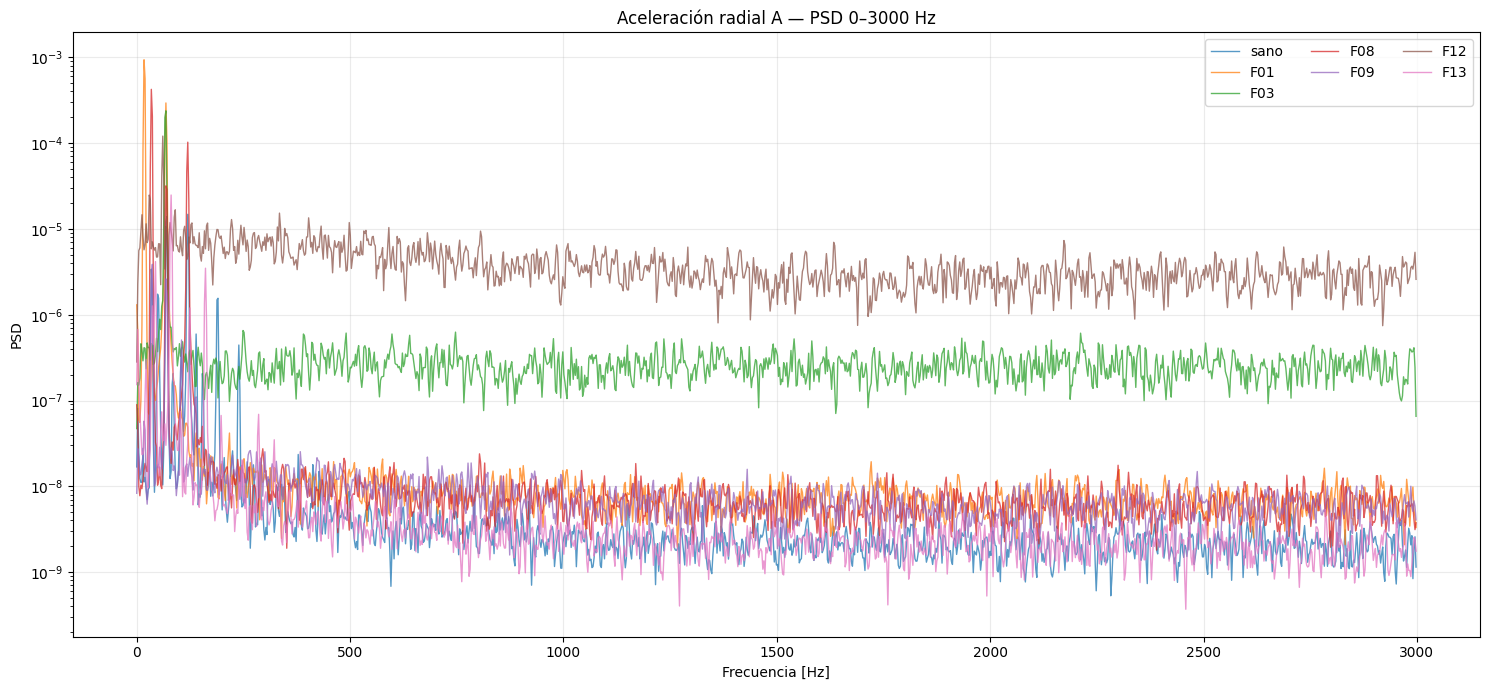

In [ ]:
FS_ACC = 20_000

plt.figure(figsize=(15, 7))

for _, row in samples_df.iterrows():

    try:
        x = load_signal(row,"acc_radial_a")
        f, pxx = welch(x,fs=FS_ACC,nperseg=min(8192, len(x)))
        mask = f <= 3000

        plt.semilogy(
            f[mask],
            pxx[mask],
            alpha=0.75,
            linewidth=1,
            label=row["state_name"]
        )

    except Exception as e:
        print("ERROR:",row["state_name"],e)

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD")
plt.title("Aceleración radial A — PSD 0–3000 Hz")
plt.grid(alpha=0.25)
plt.legend(ncol=3)
plt.tight_layout()
plt.show()

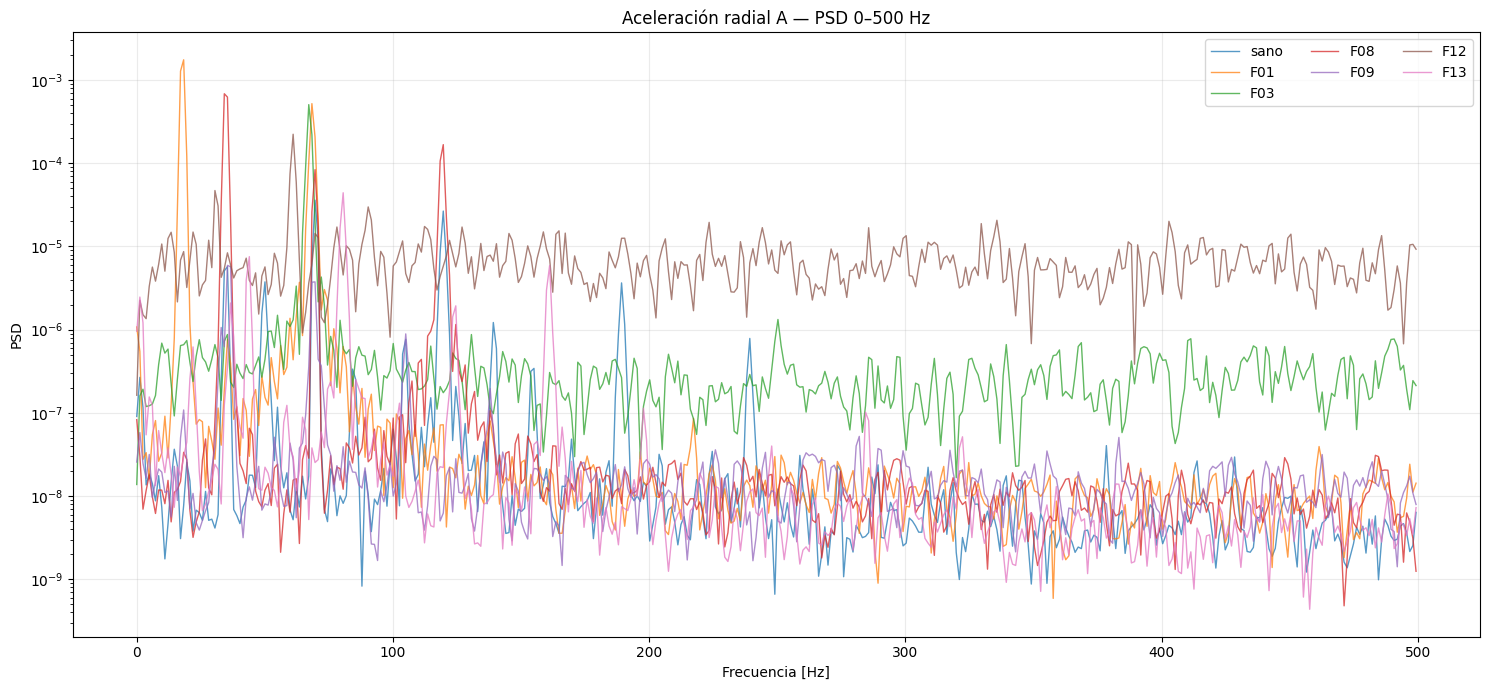

In [ ]:
plt.figure(figsize=(15, 7))

for _, row in samples_df.iterrows():
    try:
        x = load_signal(row,"acc_radial_a")
        f, pxx = welch(x,fs=FS_ACC,nperseg=min(16384, len(x)))
        mask = f <= 500
        plt.semilogy(
            f[mask],
            pxx[mask],
            alpha=0.75,
            linewidth=1,
            label=row["state_name"]
        )

    except Exception as e:
        print("ERROR:",row["state_name"],e)

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD")
plt.title("Aceleración radial A — PSD 0–500 Hz")
plt.grid(alpha=0.25)
plt.legend(ncol=3)
plt.tight_layout()
plt.show()

In [ ]:
rpm_info = samples_df[
    ["state_name","window_id","rpm_mean"]
].copy()

rpm_info["f_rot_hz"] = (rpm_info["rpm_mean"] / 60.0)

for h in range(1, 7):
    rpm_info[f"{h}x_hz"] = (rpm_info["f_rot_hz"] * h)

display(rpm_info)

,state_name,window_id,rpm_mean,f_rot_hz,1x_hz,2x_hz,3x_hz,4x_hz,5x_hz,6x_hz
0,sano,We24d8ebbd317184b0002,2115.7,35.261667,35.261667,70.523333,105.785,141.046667,176.308333,211.57
1,F01,W7b8e3d476425169c0004,1045.3,17.421667,17.421667,34.843333,52.265,69.686667,87.108333,104.53
2,F03,Wdcaa76ed4f1fcf800000,1017.8,16.963333,16.963333,33.926667,50.890,67.853333,84.816667,101.78
3,F08,Wf3ec2ccbbc5997430005,2106.2,35.103333,35.103333,70.206667,105.310,140.413333,175.516667,210.62
4,F09,W513c733af3ec27fa0003,1084.4,18.073333,18.073333,36.146667,54.220,72.293333,90.366667,108.44
5,F12,Wb3a661f3e50335ff0000,879.9,14.665000,14.665000,29.330000,43.995,58.660000,73.325000,87.99
6,F13,We8a5264b08e542690005,1259.5,20.991667,20.991667,41.983333,62.975,83.966667,104.958333,125.95


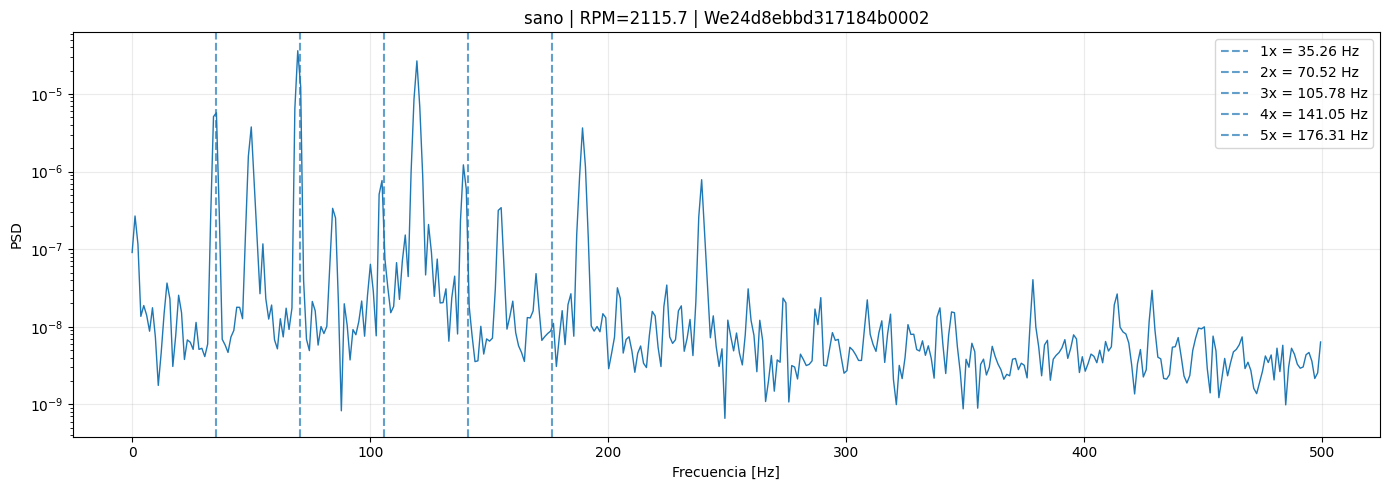

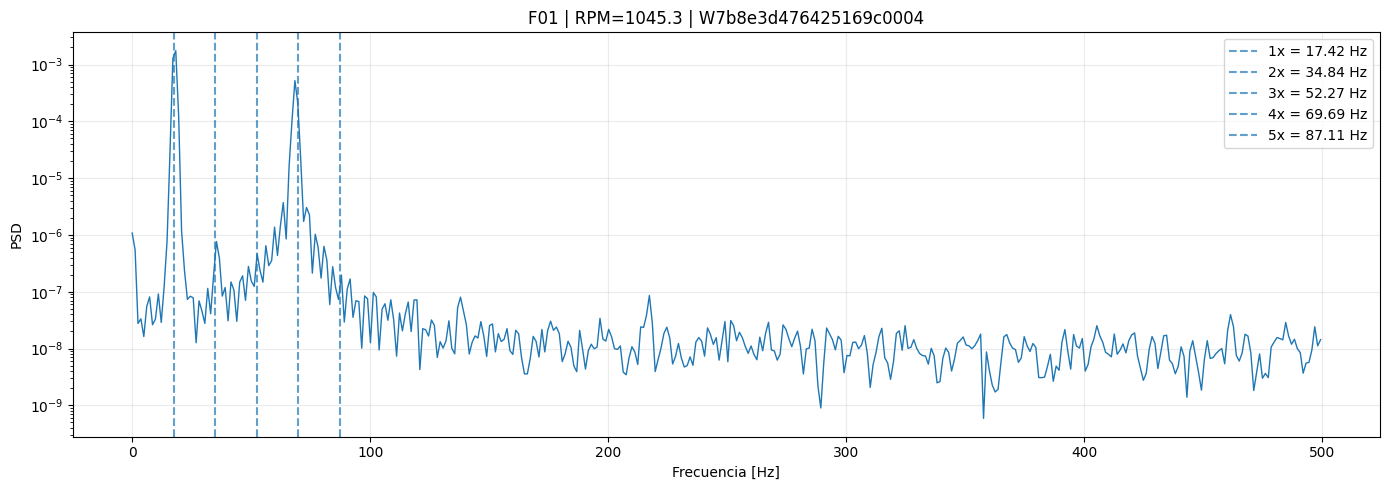

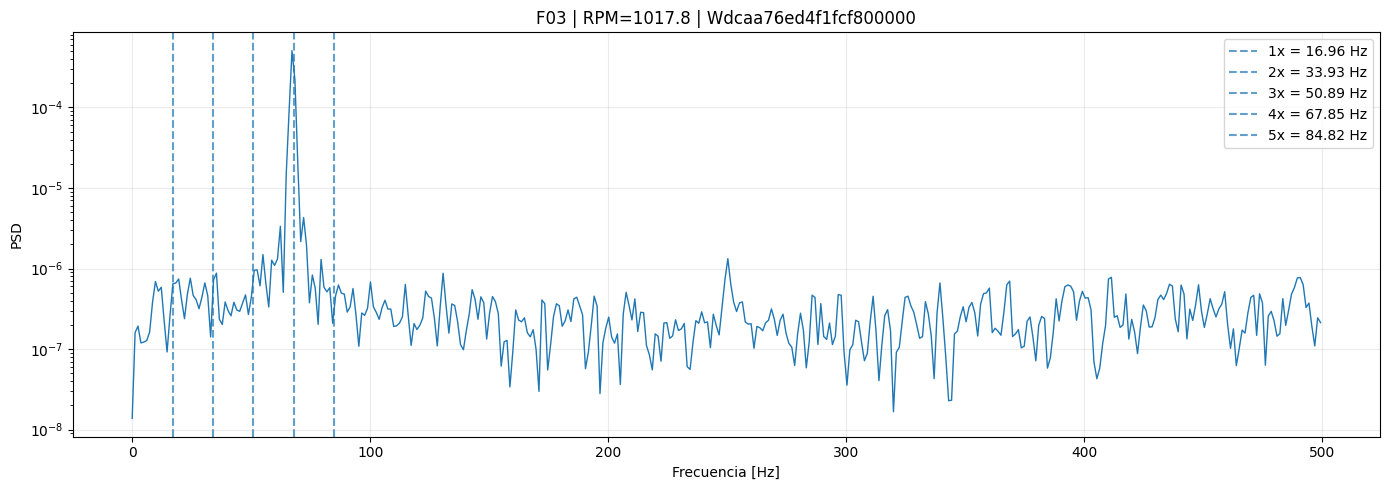

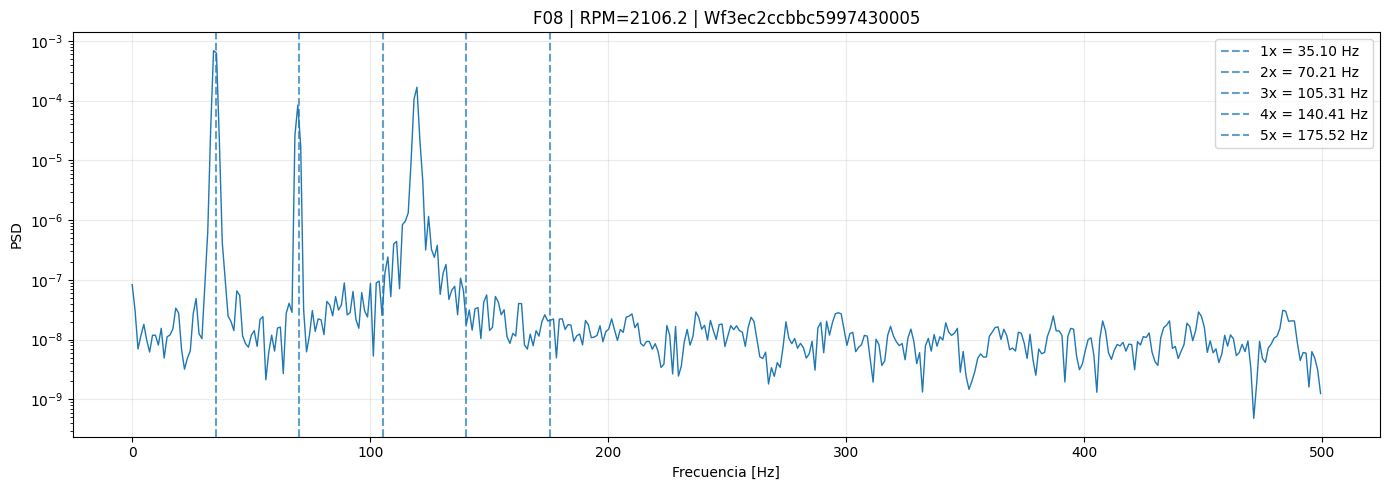

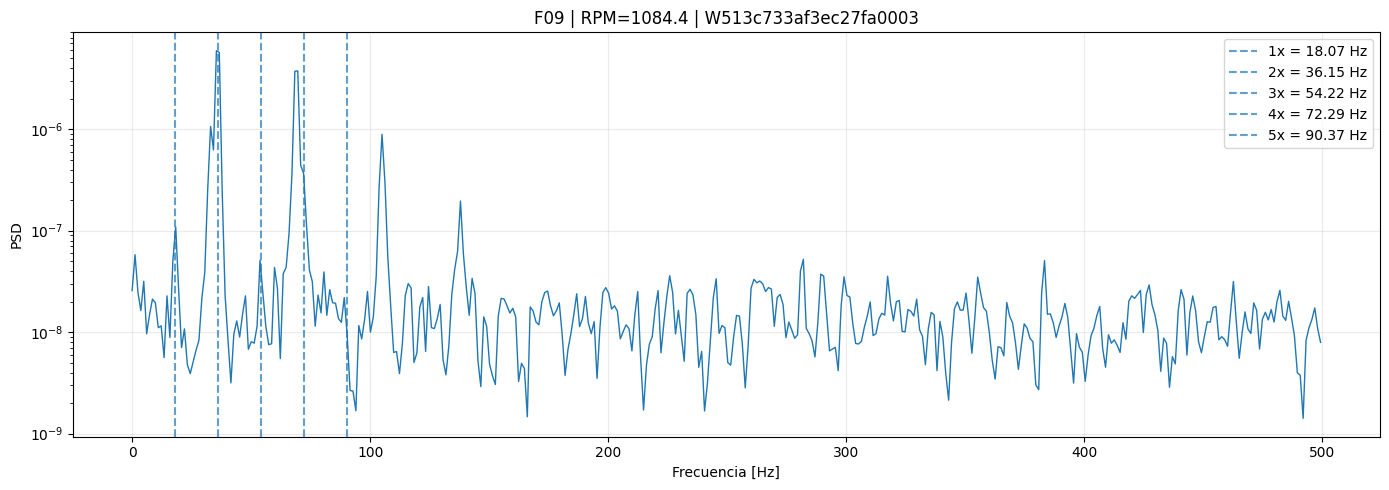

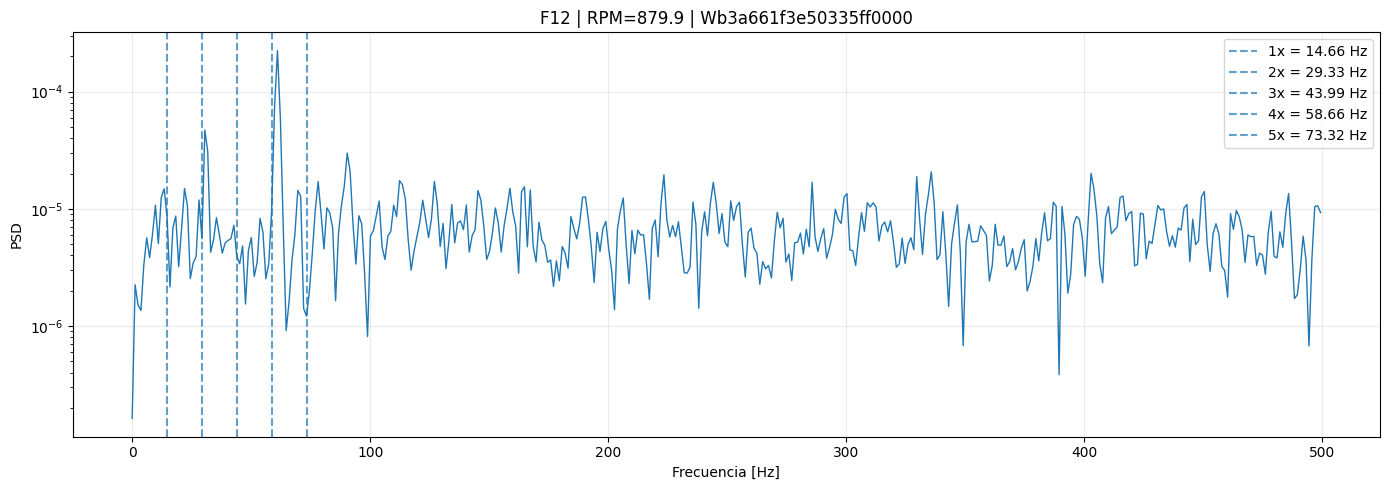

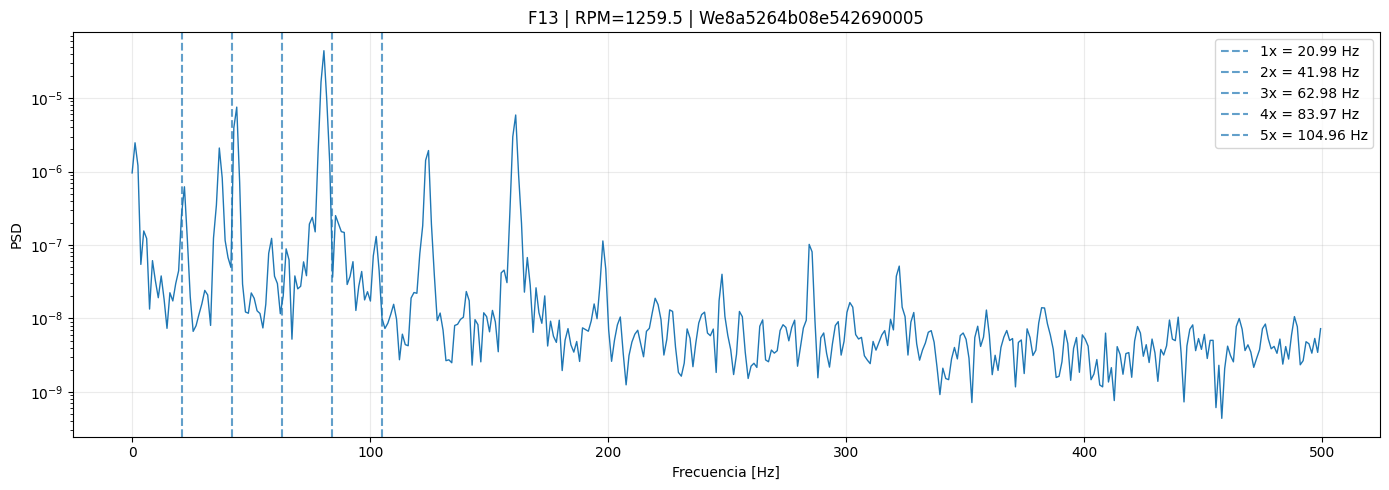

In [ ]:
for _, row in samples_df.iterrows():

    try:
        x = load_signal(row,"acc_radial_a")
        f, pxx = welch(x,fs=FS_ACC,nperseg=min(16384, len(x)))
        mask = f <= 500
        plt.figure(figsize=(14, 5))
        plt.semilogy(
            f[mask],
            pxx[mask],
            linewidth=1
        )

        rpm = row["rpm_mean"]
        f_rot = rpm / 60.0

        for h in range(1, 6):
            fh = h * f_rot
            if fh <= 500:
                plt.axvline(
                    fh,
                    linestyle="--",
                    alpha=0.7,
                    label=f"{h}x = {fh:.2f} Hz"
                )

        plt.xlabel("Frecuencia [Hz]")
        plt.ylabel("PSD")
        plt.title(
            f"{row['state_name']} | "
            f"RPM={rpm:.1f} | "
            f"{row['window_id']}"
        )

        plt.grid(alpha=0.25)
        plt.legend()
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print("ERROR:",row["state_name"],e)

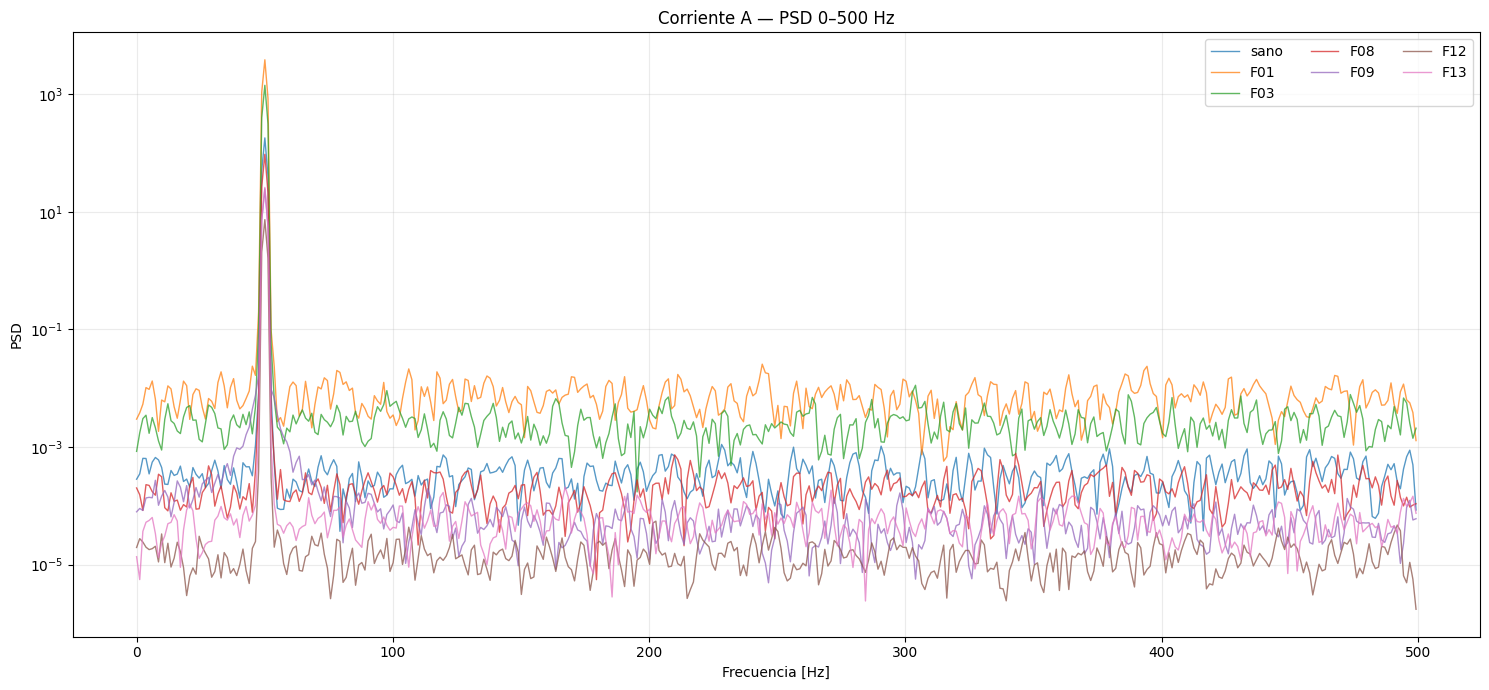

In [ ]:
FS_CUR = 10_000

plt.figure(figsize=(15, 7))

for _, row in samples_df.iterrows():
    try:
        x = load_signal(row,"current_a")
        f, pxx = welch(x,fs=FS_CUR,nperseg=min(8192, len(x)))

        mask = f <= 500

        plt.semilogy(
            f[mask],
            pxx[mask],
            alpha=0.75,
            linewidth=1,
            label=row["state_name"]
        )

    except Exception as e:

        print(
            "ERROR:",
            row["state_name"],
            e
        )

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD")

plt.title(
    "Corriente A — PSD 0–500 Hz"
)

plt.grid(alpha=0.25)
plt.legend(ncol=3)

plt.tight_layout()
plt.show()

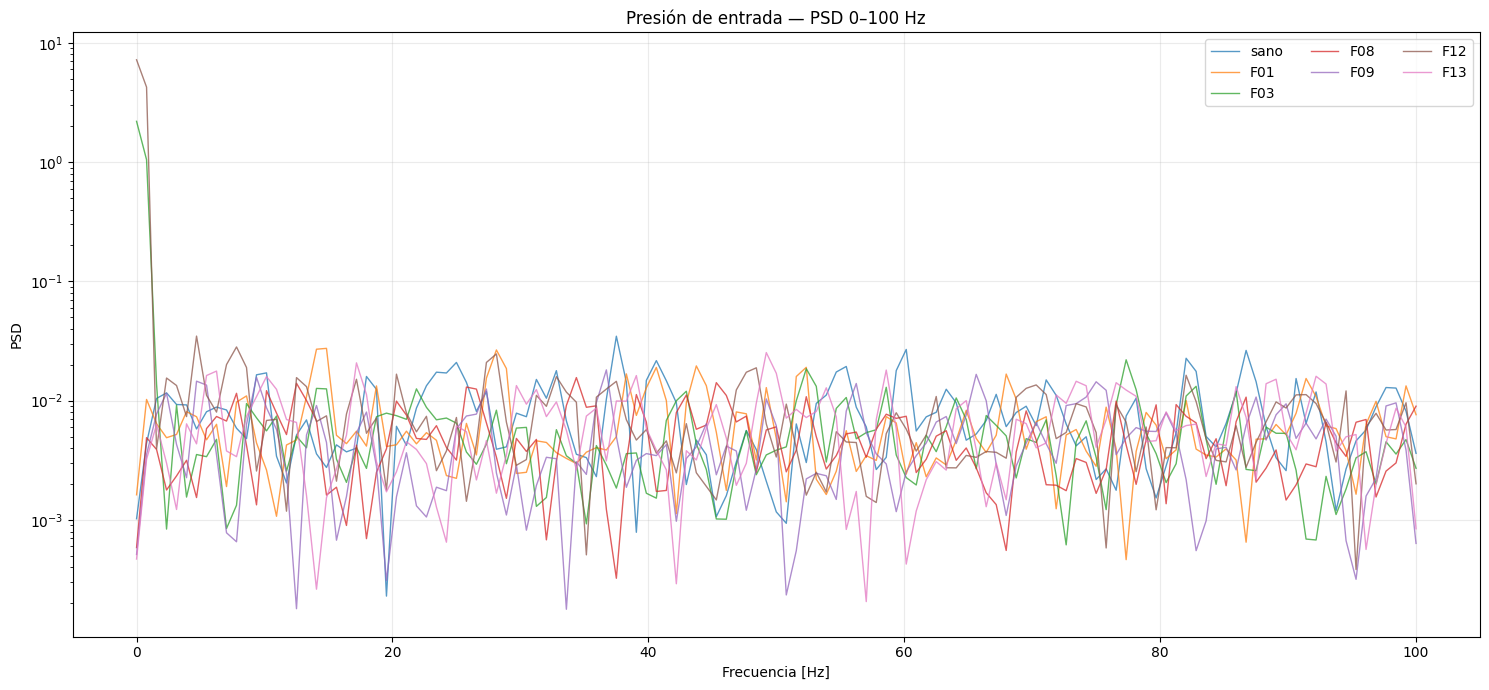

In [ ]:
FS_PRESS = 200

plt.figure(figsize=(15, 7))

for _, row in samples_df.iterrows():
    try:
        x = load_signal(row,  "pressure_in")
        f, pxx = welch( x,fs=FS_PRESS,  nperseg=min(256, len(x)) )

        mask = f <= 100
        plt.semilogy(
            f[mask],
            pxx[mask],
            alpha=0.75,
            linewidth=1,
            label=row["state_name"]
        )

    except Exception as e:
        print( "ERROR:", row["state_name"],e)

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD")
plt.title("Presión de entrada — PSD 0–100 Hz")
plt.grid(alpha=0.25)
plt.legend(ncol=3)
plt.tight_layout()
plt.show()

### Extracción de features espectrales — vibración

Bloques reutilizables: PSD por Welch, potencia integrada en banda, pico en banda,
descriptores espectrales globales (centroide, ancho de banda, entropía), armónicos
1x–5x relativos a la frecuencia de rotación, y variabilidad entre 4 segmentos de la
ventana.


In [ ]:
from scipy.signal import welch

EPS = 1e-12

def compute_psd(
    x,
    fs,
    nperseg=4096
):
    """
    Devuelve frecuencia y PSD usando Welch.
    """

    x = np.asarray(x, dtype=np.float64)
    x = x[np.isfinite(x)]
    if len(x) < 32:
        return np.array([]), np.array([])

    nperseg = min(nperseg, len(x))
    f, pxx = welch( x,fs=fs, nperseg=nperseg, detrend="constant")
    return f, pxx

def band_power(
    f,
    pxx,
    f_low,
    f_high
):
    """
    Potencia integrada dentro de una banda.
    """
    mask = ((f >= f_low) & (f < f_high))

    if not np.any(mask):
        return 0.0

    return np.trapezoid(
        pxx[mask],
        f[mask]
    )


def peak_in_band(
    f,
    pxx,
    f_low,
    f_high
):
    """
    Frecuencia y potencia del pico
    dentro de una banda.
    """

    mask = ((f >= f_low) &(f <= f_high))

    if not np.any(mask):
        return np.nan, 0.0

    fb = f[mask]
    pb = pxx[mask]

    idx = np.argmax(pb)

    return (fb[idx],pb[idx])


def spectral_basic_features(
    x,
    fs,
    prefix,
    fmax=None,
    nperseg=4096
):

    f, pxx = compute_psd(
        x,
        fs,
        nperseg=nperseg)

    out = {}
    if len(f) == 0:
        return out

    if fmax is not None:
        mask = f <= fmax
        f = f[mask]
        pxx = pxx[mask]
    if len(f) == 0:
        return out

    total_power = np.trapezoid(pxx,f)
    total_power = max(total_power,EPS)
    prob = pxx / (np.sum(pxx) + EPS)
    centroid = np.sum(f * prob)
    bandwidth = np.sqrt(np.sum(((f - centroid) ** 2) * prob))

    entropy = -np.sum(prob *np.log(prob + EPS))

    peak_idx = np.argmax(pxx)

    out[
        f"{prefix}__spec_total_power"
    ] = total_power

    out[
        f"{prefix}__spec_centroid"
    ] = centroid

    out[
        f"{prefix}__spec_bandwidth"
    ] = bandwidth

    out[
        f"{prefix}__spec_entropy"
    ] = entropy

    out[
        f"{prefix}__spec_peak_freq"
    ] = f[peak_idx]

    out[
        f"{prefix}__spec_peak_power"
    ] = pxx[peak_idx]

    return out

In [ ]:
def vibration_rpm_features(
    x,
    fs,
    rpm,
    prefix="vib"
):

    out = {}
    if not np.isfinite(rpm) or rpm <= 0:
        return out
    f, pxx = compute_psd(
        x,
        fs,
        nperseg=16384
    )

    if len(f) == 0:
        return out

    f_rot = rpm / 60.0

    # Potencia total
    total = np.trapezoid(pxx, f) + EPS

    out[
        f"{prefix}__total_power"
    ] = total
    # Armónicos 1x ... 5x
    harmonic_powers = {}

    for h in range(1, 6):

        fc = h * f_rot
        # Banda relativa al armónico
        bw = max( 0.15 * f_rot,1.0)
        power = band_power(f,pxx,max(0, fc - bw),fc + bw)
        rel_power = ( power / total)
        name = (f"{prefix}__h{h}")

        out[
            f"{name}_power"
        ] = power

        out[
            f"{name}_rel_power"
        ] = rel_power

        harmonic_powers[h] = rel_power

    # Ratios diagnósticos

    p1 = harmonic_powers.get(1, 0.0)
    p2 = harmonic_powers.get(2, 0.0)
    p3 = harmonic_powers.get(3, 0.0)

    out[
        f"{prefix}__h2_h1_ratio"
    ] = p2 / (p1 + EPS)

    out[
        f"{prefix}__h3_h1_ratio"
    ] = p3 / (p1 + EPS)

    out[
        f"{prefix}__harmonics_2to5_ratio"
    ] = (
        sum(
            harmonic_powers.get(h, 0.0)
            for h in range(2, 6)
        )
        /
        (p1 + EPS)
    )
    # Bandas amplias

    for lo, hi in [
        (0, 25),
        (25, 50),
        (50, 100),
        (100, 200),
        (200, 500),
        (500, 1000),
    ]:

        power = band_power(f, pxx,lo, hi)

        out[
            f"{prefix}__band_{lo}_{hi}"
        ] = power / total

    return out

In [ ]:
def segment_features(
    x,
    prefix,
    n_segments=4
):

    x = np.asarray(x,dtype=np.float64)
    x = x[np.isfinite(x)]
    if len(x) < n_segments * 10:
        return {}

    segments = np.array_split(x,n_segments)

    rms_values = []
    std_values = []
    peak_values = []

    for seg in segments:
        rms = np.sqrt(np.mean(seg ** 2))

        std = np.std(seg)
        peak = np.max(np.abs(seg))
        rms_values.append(rms)
        std_values.append(std)
        peak_values.append(peak)

    rms_values = np.asarray(rms_values)
    std_values = np.asarray(std_values)
    peak_values = np.asarray(peak_values)

    out = {}

    out[
        f"{prefix}__seg_rms_mean"
    ] = np.mean(rms_values)

    out[
        f"{prefix}__seg_rms_std"
    ] = np.std(rms_values)

    out[
        f"{prefix}__seg_rms_cv"
    ] = (np.std(rms_values) /(np.mean(rms_values) + EPS))

    out[
        f"{prefix}__seg_rms_max"
    ] = np.max(rms_values)

    out[
        f"{prefix}__seg_rms_min"
    ] = np.min(rms_values)

    out[
        f"{prefix}__seg_rms_range"
    ] = (np.max(rms_values)-np.min(rms_values))

    out[
        f"{prefix}__seg_peak_cv"
    ] = (np.std(peak_values) /(np.mean(peak_values) + EPS))

    return out

In [ ]:
def extract_vibration_features(
    row
):

    x = load_signal(
        row,
        "acc_radial_a"
    )

    rpm = float(
        row["rpm_mean"]
    )

    out = {}
    # Espectral global

    out.update(spectral_basic_features( x,fs=20_000,prefix="raw_vib",fmax=3000,nperseg=16384))

    # Relación con RPM
    out.update(
        vibration_rpm_features(x, fs=20_000, rpm=rpm, prefix="raw_vib"))
    # Variabilidad intra-ventana
    out.update(
        segment_features(x, prefix="raw_vib", n_segments=4))

    return out

In [ ]:
test_features = extract_vibration_features(samples_df.iloc[0])

print("Número de features RAW_VIB:",len(test_features))
display(
    pd.DataFrame([test_features]).T.rename(columns={0: "value"}))

Número de features RAW_VIB: 33


,value
raw_vib__spec_total_power,1.680838e-04
raw_vib__spec_centroid,1.491075e+02
raw_vib__spec_bandwidth,3.226352e+02
raw_vib__spec_entropy,2.970572e+00
raw_vib__spec_peak_freq,6.958008e+01
raw_vib__spec_peak_power,3.605419e-05
raw_vib__total_power,1.824563e-04
raw_vib__h1_power,1.386925e-05
raw_vib__h1_rel_power,7.601413e-02
raw_vib__h2_power,6.724209e-05


In [ ]:
raw_vib_rows = []

for i, (_, row) in enumerate(df_meta.iterrows()):

    try:
        feats = extract_vibration_features(row)
        feats["window_id"] = row["window_id"]
        raw_vib_rows.append(feats)
    except Exception as e:
        print(f"ERROR fila {i} | "f"{row['window_id']} | "f"{repr(e)}")

    if (i + 1) % 100 == 0:
        print(f"Procesadas {i+1}/{len(df_meta)}")

raw_vib_df = pd.DataFrame(raw_vib_rows)
print("\nRAW_VIB:",raw_vib_df.shape)

display(raw_vib_df.head())

Procesadas 100/1750
Procesadas 200/1750
Procesadas 300/1750
Procesadas 400/1750
Procesadas 500/1750
Procesadas 600/1750
Procesadas 700/1750
Procesadas 800/1750
Procesadas 900/1750
Procesadas 1000/1750
Procesadas 1100/1750
Procesadas 1200/1750
Procesadas 1300/1750
Procesadas 1400/1750
Procesadas 1500/1750
Procesadas 1600/1750
Procesadas 1700/1750

RAW_VIB: (1750, 34)


,raw_vib__spec_total_power,raw_vib__spec_centroid,raw_vib__spec_bandwidth,raw_vib__spec_entropy,raw_vib__spec_peak_freq,raw_vib__spec_peak_power,raw_vib__total_power,raw_vib__h1_power,raw_vib__h1_rel_power,raw_vib__h2_power,...,raw_vib__band_200_500,raw_vib__band_500_1000,raw_vib__seg_rms_mean,raw_vib__seg_rms_std,raw_vib__seg_rms_cv,raw_vib__seg_rms_max,raw_vib__seg_rms_min,raw_vib__seg_rms_range,raw_vib__seg_peak_cv,window_id
0,0.000115,164.415936,444.621673,3.200732,28.076172,0.000030,0.000134,0.000055,0.409107,0.000019,...,0.014988,0.017267,0.136287,0.000135,0.000987,0.136484,0.136138,0.000346,0.005993,W0511a7920bdf7d480000
1,0.000120,164.262270,444.940942,3.186914,28.076172,0.000032,0.000139,0.000058,0.413063,0.000020,...,0.013582,0.015394,0.136244,0.000125,0.000918,0.136386,0.136066,0.000320,0.024669,W0511a7920bdf7d480001
2,0.000124,161.219833,432.345351,3.210949,28.076172,0.000032,0.000143,0.000058,0.409266,0.000021,...,0.011443,0.015289,0.136283,0.000168,0.001235,0.136497,0.136066,0.000431,0.021781,W0511a7920bdf7d480002
3,0.000117,165.655103,447.107904,3.217200,28.076172,0.000030,0.000136,0.000056,0.409210,0.000019,...,0.013978,0.014763,0.136362,0.000126,0.000927,0.136497,0.136183,0.000314,0.029717,W0511a7920bdf7d480003
4,0.000117,163.223523,436.040972,3.243756,28.076172,0.000030,0.000135,0.000055,0.406237,0.000019,...,0.014261,0.017109,0.136356,0.000093,0.000679,0.136464,0.136232,0.000232,0.029334,W0511a7920bdf7d480004


In [ ]:
feature_cols_raw_vib = [
    c for c in raw_vib_df.columns
    if c != "window_id"
]

print(
    "Features:",
    len(feature_cols_raw_vib)
)
print(
    "NaN totales:",
    raw_vib_df[feature_cols_raw_vib]
    .isna()
    .sum()
    .sum()
)
print(
    "Inf totales:",
    np.isinf(
        raw_vib_df[feature_cols_raw_vib]
        .to_numpy(dtype=float)
    ).sum()
)
print(
    "Duplicados window_id:",
    raw_vib_df["window_id"]
    .duplicated()
    .sum()
)
print("\nFeatures constantes:")

constant_raw = [
    c for c in feature_cols_raw_vib
    if raw_vib_df[c].std() == 0
]
print(constant_raw)

Features: 33
NaN totales: 0
Inf totales: 0
Duplicados window_id: 0

Features constantes:
[]


In [ ]:
raw_vib_features = raw_vib_df.set_index(
    "window_id"
)

# Alinear exactamente con train
X_raw_vib = raw_vib_features.reindex(
    train["window_id"]
)

assert len(X_raw_vib) == len(train)

assert (
    X_raw_vib.index
    == train["window_id"]
).all()

print(
    "X_raw_vib:",
    X_raw_vib.shape
)

X_raw_vib: (1750, 33)


In [ ]:
from sklearn.feature_selection import mutual_info_classif

X_mi_raw = (X_raw_vib.replace([np.inf, -np.inf], np.nan))

X_mi_raw = (X_mi_raw.fillna(X_mi_raw.median()))

mi_raw = mutual_info_classif(
    X_mi_raw,
    estado,
    discrete_features=False,
    random_state=42
)

mi_raw_df = pd.DataFrame({
    "feature": X_raw_vib.columns,
    "MI_14": mi_raw
}).sort_values("MI_14", ascending=False)

display(mi_raw_df.head(20))

,feature,MI_14
6,raw_vib__total_power,1.998360
26,raw_vib__seg_rms_mean,1.953590
0,raw_vib__spec_total_power,1.913255
30,raw_vib__seg_rms_min,1.731859
29,raw_vib__seg_rms_max,1.726875
1,raw_vib__spec_centroid,1.718447
5,raw_vib__spec_peak_power,1.700294
3,raw_vib__spec_entropy,1.684301
22,raw_vib__band_50_100,1.550318
7,raw_vib__h1_power,1.526279


In [ ]:
X_base = construir(train,"fis_z").copy()

X_raw_aug = pd.concat(
    [
        X_base.reset_index(drop=True),
        X_raw_vib.reset_index(drop=True)
    ],
    axis=1
)

print("BASE+FIS+Z:", X_base.shape)
print("BASE+FIS+Z+RAW_VIB:",X_raw_aug.shape)

BASE+FIS+Z: (1750, 174)
BASE+FIS+Z+RAW_VIB: (1750, 207)


> **Corrección — comparación mal etiquetada**
>
> La versión original de la celda siguiente pasaba `X_raw_vib` (33 columnas, sólo
> las crudas) con la etiqueta `BASE+FIS+Z+RAW_VIB`. Los números que quedaron
> registrados eran de **RAW_VIB sola**, no de la matriz combinada, así que la
> comparación contra `BASE+FIS+Z` no medía lo que decía medir.
>
> Para el registro, esos números descartados fueron: RandomForest 42.25,
> ExtraTrees 41.70, CatBoost 41.20, XGBoost 40.58, LightGBM 39.63,
> RegLogistica 37.76. Leídos correctamente dicen algo útil —las 33 features
> crudas **solas** valen ~40 puntos, contra 47–51 de la matriz tabular— pero no
> dicen que agregarlas empeore.
>
> Acá se pasa `X_raw_aug`. Los outputs viejos se descartaron: **hay que volver a
> correr esta celda**.


In [ ]:
# CORRECCIÓN: acá iba `benchmark_features(X_raw_vib, "BASE+FIS+Z+RAW_VIB")`, que
# pasaba sólo las 33 columnas crudas con la etiqueta de la matriz combinada.
# Ahora se pasa X_raw_aug (207 columnas), que es lo que la etiqueta dice.
tabla_raw_abs, oofs_raw_abs = benchmark(X_raw_aug, "BASE+FIS+Z+RAW_VIB")

comparacion = pd.concat([tabla_fis, tabla_raw_abs], ignore_index=True)
display(comparacion.sort_values("final", ascending=False).reset_index(drop=True))


### La huella de la máquina en las features crudas

Antes de aceptar las features crudas hay que preguntarse cuánta de su varianza es
de la falla y cuánta es de la máquina. La partición está agrupada por `machine_id`,
así que una feature dominada por la máquina no sólo no ayuda: entrena al modelo a
memorizar máquinas que en el test no existen.


In [ ]:
X_tmp = X_raw_vib.copy()

# Agregamos machine_id respetando exactamente el orden de train
X_tmp["machine_id"] = train["machine_id"].to_numpy()

print("Filas:", len(X_tmp))
print("Features RAW_VIB:", X_raw_vib.shape[1])

# Promedio de cada feature por máquina
raw_machine_stats = (X_tmp.groupby("machine_id", sort=False).mean(numeric_only=True))

print("Máquinas:",raw_machine_stats.shape[0])
print("Features analizadas:",raw_machine_stats.shape[1])

display(raw_machine_stats.iloc[:, :10].round(6))

Filas: 1750
Features RAW_VIB: 33
Máquinas: 26
Features analizadas: 33


,raw_vib__spec_total_power,raw_vib__spec_centroid,raw_vib__spec_bandwidth,raw_vib__spec_entropy,raw_vib__spec_peak_freq,raw_vib__spec_peak_power,raw_vib__total_power,raw_vib__h1_power,raw_vib__h1_rel_power,raw_vib__h2_power
machine_id,,,,,,,,,,
M0000022,0.006791,365.217425,444.163939,3.254744,42.776925,0.001625,0.012194,0.002226,0.453000,0.000043
M0000032,0.014577,242.523589,330.752845,2.573294,37.175959,0.004590,0.017292,0.002951,0.205354,0.009915
M0000018,0.023537,295.835452,384.819663,2.904673,52.046342,0.007157,0.032542,0.002838,0.040828,0.014531
M0000043,0.010048,552.776346,607.776623,4.304941,33.264160,0.000937,0.023822,0.001859,0.391878,0.000144
M0000025,0.007241,84.372662,185.669329,1.857086,45.514788,0.002643,0.007490,0.005249,0.571719,0.000029
M0000045,0.007985,132.255359,196.573765,1.904774,90.775923,0.002440,0.008291,0.001171,0.065970,0.003591
M0000039,0.008279,437.825476,468.464931,3.747552,40.126256,0.002171,0.012473,0.002284,0.349813,0.003432
M0000014,0.032420,260.250666,450.033520,2.569196,49.161044,0.012157,0.036564,0.004526,0.037833,0.025274
M0000047,0.008284,482.417729,652.208649,4.195655,109.008789,0.002071,0.012999,0.003823,0.237507,0.000100


In [ ]:
machine_variability = pd.DataFrame({
    "mean_across_machines": raw_machine_stats.mean(),
    "std_across_machines": raw_machine_stats.std(),
    "min_machine_mean": raw_machine_stats.min(),
    "max_machine_mean": raw_machine_stats.max(),
})

machine_variability["relative_machine_variation"] = (
    machine_variability["std_across_machines"]  /
    (machine_variability["mean_across_machines"].abs() + 1e-12))

display(
    machine_variability
    .sort_values("relative_machine_variation", ascending=False)
    .head(20)
)

,mean_across_machines,std_across_machines,min_machine_mean,max_machine_mean,relative_machine_variation
raw_vib__harmonics_2to5_ratio,61.426355,180.126021,2.576758e-02,908.464776,2.932390
raw_vib__h4_rel_power,0.015393,0.040887,3.385754e-04,0.198290,2.656218
raw_vib__h2_h1_ratio,25.034202,50.919210,1.304338e-02,213.110082,2.033986
raw_vib__h4_power,0.000052,0.000094,3.424842e-06,0.000434,1.792541
raw_vib__h3_rel_power,0.002085,0.003692,3.009373e-04,0.018415,1.771356
raw_vib__h3_h1_ratio,0.221133,0.367171,1.056395e-03,1.651229,1.660407
raw_vib__band_100_200,0.114988,0.155909,3.925853e-03,0.664199,1.355868
raw_vib__h2_power,0.008875,0.010703,2.926058e-05,0.041634,1.206009
raw_vib__h5_power,0.000010,0.000012,4.418196e-07,0.000047,1.192179
raw_vib__band_0_25,0.044926,0.052314,2.108455e-04,0.187544,1.164449


In [ ]:
total_std = X_raw_vib.std()

# Variación de cada feature dentro de cada máquina
within_std = (X_tmp.groupby("machine_id")[X_raw_vib.columns].std().mean())

variation_ratio = pd.DataFrame({
    "total_std": total_std,
    "within_machine_std": within_std
})

variation_ratio["between_machine_signal"] = (
    variation_ratio["total_std"] / (variation_ratio["within_machine_std"] + 1e-12)
)

display(
    variation_ratio
    .sort_values("between_machine_signal",mascending=False)
    .head(20)
)

,total_std,within_machine_std,between_machine_signal
raw_vib__harmonics_2to5_ratio,395.525690,92.796880,4.262274
raw_vib__h2_h1_ratio,72.288162,22.575379,3.202080
raw_vib__h4_rel_power,0.065918,0.021690,3.039074
raw_vib__h3_rel_power,0.006337,0.002503,2.531926
raw_vib__seg_rms_cv,0.016509,0.007080,2.331714
raw_vib__h3_h1_ratio,0.661404,0.286546,2.308198
raw_vib__band_100_200,0.210550,0.095649,2.201282
raw_vib__h5_rel_power,0.001455,0.000674,2.157790
raw_vib__h4_power,0.000160,0.000076,2.096803
raw_vib__seg_rms_std,0.002127,0.001158,1.836812


### Diagnóstico de la variabilidad entre máquinas (between_machine_signal)

Los resultados muestran una alerta fuerte: la gran mayoría de los ratios armónicos y potencias relativas están fuertemente dominados por la máquina física (machine_id) y no por la condición operativa.  
1. Features con fuga / sesgo extremo (between_machine_signal >> 2.0)
* raw_vib__harmonics_2to5_ratio (4.26): La varianza total es 4 veces mayor que la variabilidad interna; su media por máquina oscila entre $0.025$ y $908.46$.raw_vib__h2_h1_ratio (3.20): Medias por máquina que van desde $0.013$ hasta $213.11$.
* raw_vib__h4_rel_power (3.04), raw_vib__h3_rel_power (2.53), raw_vib__h3_h1_ratio (2.31).raw_vib__seg_rms_cv (2.33): El coeficiente de variación temporal también cambia más por máquina que por estado de falla.

Consecuencia: Un modelo basado en árboles usará estas features para memorizar qué máquina está evaluando (M000007, M000028, etc.) en lugar de aprender el patrón de la falla. En un test con máquinas no vistas, estas variables degradarán el score.  

2. Features con mejor balance (between_machine_signal < 1.5)
* raw_vib__band_200_500 (1.41)
* raw_vib__spec_total_power (1.41)
* raw_vib__h3_power (1.51)
* raw_vib__spec_peak_power (1.54)

Interpretación: Las energías absolutas por banda ancha y potencias totales mantienen una relación más cercana a $1.0$, lo que indica que la variación producida por eventos de operación/falla tiene un peso comparable al de la máquina base.  

Recomendaciones para el pipeline de features

* Descartar o penalizar ratios armónicos crudos de alto orden:

* Excluir harmonics_2to5_ratio, h2_h1_ratio y h4_rel_power en su forma actual, o regularizarlos.

* Priorizar bandas de energía e integrales espectrales: Mantener variables agregadas de banda ancha (band_100_200, band_200_500, spec_total_power) que presentan menor huella de máquina individual.  

* Validación estricta por máquina: Evaluar cualquier subconjunto de features RAW usando obligatoriamente GroupKFold(groups=train['machine_id']) para comprobar si realmente generalizan a máquinas no vistas.  

In [ ]:
RAW_VIB_DROP = [
    "raw_vib__harmonics_2to5_ratio",
    "raw_vib__h2_h1_ratio",
    "raw_vib__h4_rel_power",
    "raw_vib__h3_rel_power",
    "raw_vib__h3_h1_ratio",
    "raw_vib__seg_rms_cv",
]

# Drop the identified high-variability features from X_raw_vib
X_raw_vib = X_raw_vib.drop(columns=RAW_VIB_DROP, errors='ignore')

print(f"Dropped features: {RAW_VIB_DROP}")
print(f"New shape of X_raw_vib: {X_raw_vib.shape}")

Dropped features: ['raw_vib__harmonics_2to5_ratio', 'raw_vib__h2_h1_ratio', 'raw_vib__h4_rel_power', 'raw_vib__h3_rel_power', 'raw_vib__h3_h1_ratio', 'raw_vib__seg_rms_cv']
New shape of X_raw_vib: (1750, 27)


### Normalización robusta por máquina

Mismo criterio que en la sección 2, pero con MAD en vez de desvío estándar: las
potencias espectrales son mucho más sesgadas que los descriptores tabulares y la
mediana absoluta de desviaciones aguanta mejor las colas.


In [ ]:
def robust_z_by_machine(X, machine_id):

    X = X.copy()

    machines = pd.Series(machine_id, index=X.index)

    result = pd.DataFrame(
        index=X.index,
        columns=X.columns,
        dtype=float
    )

    for machine in machines.unique():
        mask = machines == machine
        X_m = X.loc[mask]
        med = X_m.median()
        mad = (X_m.sub(med).abs().median())

        scale = 1.4826 * mad

        # Fallback si MAD = 0
        std = X_m.std()
        scale = scale.where(scale > 1e-9,std)
        scale = scale.replace(0,1.0)
        result.loc[mask] = ( X_m - med ) / scale
    return result

RAW_VIB_Z = robust_z_by_machine( X_raw_vib,train["machine_id"].to_numpy())
RAW_VIB_Z.columns = [ c + "__mZ"for c in RAW_VIB_Z.columns]
print("RAW_VIB_Z:", RAW_VIB_Z.shape)
display(RAW_VIB_Z.head())

RAW_VIB_Z: (1750, 27)


,raw_vib__spec_total_power__mZ,raw_vib__spec_centroid__mZ,raw_vib__spec_bandwidth__mZ,raw_vib__spec_entropy__mZ,raw_vib__spec_peak_freq__mZ,raw_vib__spec_peak_power__mZ,raw_vib__total_power__mZ,raw_vib__h1_power__mZ,raw_vib__h1_rel_power__mZ,raw_vib__h2_power__mZ,...,raw_vib__band_50_100__mZ,raw_vib__band_100_200__mZ,raw_vib__band_200_500__mZ,raw_vib__band_500_1000__mZ,raw_vib__seg_rms_mean__mZ,raw_vib__seg_rms_std__mZ,raw_vib__seg_rms_max__mZ,raw_vib__seg_rms_min__mZ,raw_vib__seg_rms_range__mZ,raw_vib__seg_peak_cv__mZ
window_id,,,,,,,,,,,,,,,,,,,,,
W0511a7920bdf7d480000,-0.786243,0.838624,0.772364,0.623621,-1.214083,-0.855112,-0.740264,-0.853539,0.106018,-2.500067,...,17.634921,4.523447,1.305508,1.339408,-0.314679,-0.772337,-0.319868,-0.278417,-0.870180,-0.881299
W0511a7920bdf7d480001,-0.785235,0.836748,0.773797,0.614709,-1.214083,-0.853909,-0.739733,-0.852190,0.114455,-2.296576,...,17.788827,4.851918,1.107779,1.106110,-0.315622,-0.785061,-0.321988,-0.280034,-0.885392,0.561137
W0511a7920bdf7d480002,-0.784484,0.799611,0.717266,0.630209,-1.214083,-0.853713,-0.739369,-0.851733,0.106358,-2.131875,...,18.453555,5.060202,0.806937,1.093065,-0.314759,-0.726873,-0.319600,-0.280034,-0.820605,0.338105
W0511a7920bdf7d480003,-0.785766,0.853749,0.783523,0.634240,-1.214083,-0.854905,-0.740083,-0.853169,0.106238,-2.363606,...,18.076065,4.774839,1.163427,1.027623,-0.313010,-0.783271,-0.319600,-0.277416,-0.889108,0.951000
W0511a7920bdf7d480004,-0.785881,0.824069,0.733853,0.651365,-1.214083,-0.855219,-0.740159,-0.853530,0.099897,-2.405175,...,18.156004,4.846418,1.203258,1.319665,-0.313143,-0.828596,-0.320303,-0.276324,-0.936742,0.921451


In [ ]:
X_BASE = construir(train,"fis_z").copy()

X_BASE_RAW_Z = pd.concat([
        X_BASE.reset_index(drop=True),
        RAW_VIB_Z.reset_index(drop=True)
    ],axis=1
)

print("BASE+FIS+Z:", X_BASE.shape)
print("BASE+FIS+Z+RAW_VIB_Z:",X_BASE_RAW_Z.shape)

BASE+FIS+Z: (1750, 174)
BASE+FIS+Z+RAW_VIB_Z: (1750, 201)


In [ ]:
# Sólo los tres boosters: sobre 201 columnas, los seis modelos tardan de más y
# ExtraTrees / RegLogistica ya mostraron que no son competitivos acá.
MODELOS_RAPIDOS = {n: MODELOS[n] for n in ["LightGBM", "XGBoost"]}
results_raw_z_df, oofs_raw_z = benchmark(X_BASE_RAW_Z, "BASE+FIS+Z+RAW_VIB_Z",
                                         modelos=MODELOS_RAPIDOS)
display(results_raw_z_df.drop(columns="config"))

LightGBM     | final=50.42 | cost=41.98 | prob=81.93 | diag=46.52
XGBoost      | final=50.86 | cost=42.13 | prob=83.43 | diag=46.87
CatBoost     | final=50.88 | cost=42.61 | prob=84.14 | diag=42.29


,modelo,final,cost,prob,diag,brier,macro_f1,sd_folds
0,LightGBM,50.422104,41.977555,81.926959,46.524234,0.045183,0.465242,4.278743
1,XGBoost,50.863346,42.129208,83.430031,46.868938,0.041425,0.468689,4.071934
2,CatBoost,50.884230,42.608432,84.144928,42.293417,0.039638,0.422934,4.288339


Con la vibración normalizada por máquina, las tres configuraciones quedan en
50.42 / 50.86 / 50.88 (LightGBM / XGBoost / CatBoost), contra 48.83 / 49.74 / 50.86
de `fis_z` sola. LightGBM gana +1.59 y XGBoost +1.11; CatBoost queda igual (+0.02).

Es una mejora chica y desparejamente distribuida, del orden del desvío entre folds
(≈4.2). No alcanza para declarar victoria, pero la dirección es la correcta y el
`diag_score` de LightGBM sube de 46.09 a 46.52.

### Corriente (`current_a`, 10 kHz)

El canal donde deberían verse las fallas eléctricas: bandas alrededor de la
fundamental de 50 Hz, armónicos 2x–6x y bandas laterales.


In [ ]:
def extract_current_features(row):

    x = load_signal(row,"current_a")

    out = {}
    f, pxx = compute_psd( x,fs=10_000, nperseg=16384)

    if len(f) == 0:
        return out

    total = (np.trapezoid(pxx, f)+ EPS)

    for lo, hi in [
        (0, 25),
        (25, 45),
        (45, 55),
        (55, 75),
        (75, 100),
        (100, 200),
        (200, 500),
    ]:

        p = band_power(f,pxx,lo,hi)
        out[f"raw_cur__band_{lo}_{hi}"] = p / total

    # Fundamental 50 Hz

    p50 = band_power( f, pxx,47,53)
    out["raw_cur__50hz_rel"] = p50 / total

    # Armónicos

    harmonic_relative = []
    for h in range(2, 7):
        center = 50 * h
        p = band_power(f, pxx,center - 3,center + 3)
        rel = p / total
        out[ f"raw_cur__h{h}_rel"] = rel
        harmonic_relative.append(rel)

    # Features espectrales básicas
    out.update(spectral_basic_features(x,fs=10_000,prefix="raw_cur",fmax=500, nperseg=8192))
    # Variabilidad dentro de la ventana
    out.update(segment_features(x,prefix="raw_cur",n_segments=4))

    return out

In [ ]:
raw_cur_rows = []

for i, (_, row) in enumerate(
    df_meta.iterrows()
):

    try:
        feats = extract_current_features(row)
        feats["window_id"] = (row["window_id"])

        raw_cur_rows.append(feats)

    except Exception as e:
        print(f"ERROR {i}: "f"{row['window_id']} | "f"{repr(e)}")

    if (i + 1) % 100 == 0:
        print(f"{i+1}/{len(df_meta)}")

raw_cur_df = pd.DataFrame(raw_cur_rows)

print("RAW_CURRENT:",raw_cur_df.shape)

100/1750
200/1750
300/1750
400/1750
500/1750
600/1750
700/1750
800/1750
900/1750
1000/1750
1100/1750
1200/1750
1300/1750
1400/1750
1500/1750
1600/1750
1700/1750
RAW_CURRENT: (1750, 27)


In [ ]:
cur_cols = [
    c for c in raw_cur_df.columns
    if c != "window_id"
]

X_raw_cur = (raw_cur_df.set_index("window_id").reindex(train["window_id"]))

assert len(X_raw_cur) == len(train)
assert X_raw_cur.isna().sum().sum() == 0
X_raw_cur_Z = robust_z_by_machine(X_raw_cur, train["machine_id"].to_numpy())

X_raw_cur_Z.columns = [c + "__mZ" for c in X_raw_cur_Z.columns]

print("RAW_CURRENT:", X_raw_cur.shape)
print("RAW_CURRENT_Z:", X_raw_cur_Z.shape)

RAW_CURRENT: (1750, 26)
RAW_CURRENT_Z: (1750, 26)


In [ ]:
X_BASE_VIB = pd.concat(
    [X_BASE.reset_index(drop=True), RAW_VIB_Z.reset_index(drop=True)],
    axis=1
)

X_BASE_VIB_CUR = pd.concat(
    [X_BASE_VIB.reset_index(drop=True),X_raw_cur_Z.reset_index(drop=True)],
    axis=1
)

print("BASE+FIS+Z+RAW_VIB_Z:",X_BASE_VIB.shape)
print("BASE+FIS+Z+RAW_VIB_Z+RAW_CURRENT_Z:",X_BASE_VIB_CUR.shape)

BASE+FIS+Z+RAW_VIB_Z: (1750, 201)
BASE+FIS+Z+RAW_VIB_Z+RAW_CURRENT_Z: (1750, 227)


In [ ]:
resultados_current_df, oofs_cur = benchmark(
    X_BASE_VIB_CUR, "BASE+FIS+Z+RAW_VIB_Z+RAW_CURRENT_Z", modelos=MODELOS_RAPIDOS)
display(resultados_current_df.drop(columns="config"))

LightGBM     | final=52.84 | cost=44.14 | prob=83.41 | diag=52.55
XGBoost      | final=52.68 | cost=44.16 | prob=84.04 | diag=49.65


,modelo,final,cost,prob,diag,brier,macro_f1,sd_folds
0,LightGBM,52.838044,44.143160,83.411929,52.554463,0.041470,0.525545,5.077949
1,XGBoost,52.681767,44.155293,84.038037,49.654551,0.039905,0.496546,4.189512


**El aporte más claro de las señales crudas.** LightGBM pasa de 50.42 a **52.84**
(+2.42) y XGBoost de 50.86 a **52.68** (+1.82). Y lo más relevante: `diag_score`
salta de 46.52 a 52.55 en LightGBM, que es exactamente la componente donde se dijo
que quedaba margen.

### Control: ¿la corriente sola alcanza?

La misma matriz pero sin las features de vibración, para separar el aporte de cada
canal en vez de leerlos como un bloque.


In [ ]:
X_BASE_CUR = pd.concat([X_BASE.reset_index(drop=True),
                        X_raw_cur_Z.reset_index(drop=True)], axis=1)
print("BASE+FIS+Z+RAW_CURRENT_Z:", X_BASE_CUR.shape)

resultados_current_solo, _ = benchmark(X_BASE_CUR, "BASE+FIS+Z+RAW_CURRENT_Z",
                                       modelos=MODELOS_RAPIDOS)
display(resultados_current_solo.drop(columns="config"))


BASE+FIS+Z+RAW_CURRENT_Z: (1750, 200)
LightGBM     | final=51.15 | cost=42.41 | prob=82.58 | diag=49.41
XGBoost      | final=51.72 | cost=43.34 | prob=83.14 | diag=47.53


,modelo,final,cost,prob,diag,brier,macro_f1,sd_folds
0,LightGBM,51.146405,42.414316,82.578467,49.406902,0.043554,0.494069,6.872410
1,XGBoost,51.717215,43.336366,83.142993,47.531602,0.042143,0.475316,6.194797


Sin vibración: 51.15 / 51.72 (LightGBM / XGBoost), contra 52.84 / 52.68 con los dos
canales. **Los dos aportan**, y aportan cosas distintas: la corriente sola ya supera
a la vibración sola, pero la combinación gana a cualquiera de las dos.

### Presión de entrada (`pressure_in`, 200 Hz)

El último canal. Muestreo mucho más bajo, así que sólo tiene sentido mirar bandas de
baja frecuencia — donde deberían aparecer cavitación y obstrucción.


In [ ]:
def extract_pressure_features(row):

    x = load_signal(row,"pressure_in")

    out = {}
    # PSD
    f, pxx = compute_psd( x,fs=200,nperseg=min(256, len(x)))

    if len(f) == 0:
        return out

    total = (np.trapezoid(pxx, f)+ EPS)

    # Bandas de baja frecuencia
    for lo, hi in [
        (0, 2),
        (2, 5),
        (5, 10),
        (10, 20),
        (20, 50),
        (50, 100),
    ]:

        p = band_power(f, pxx, lo,hi)

        out[ f"raw_prs__band_{lo}_{hi}"] = p / total

    # Energía total y pico
    out["raw_prs__total_power"] = total

    peak_idx = np.argmax(pxx)

    out[  "raw_prs__peak_freq"] = f[peak_idx]

    out["raw_prs__peak_power"] = pxx[peak_idx]

    # Espectro
    out.update(
        spectral_basic_features(x,fs=200,prefix="raw_prs",fmax=100,nperseg=min(256, len(x)))
    )

    # Dinámica dentro de los 2 s
    out.update(
        segment_features(x,prefix="raw_prs",n_segments=4))

    return out

In [ ]:
raw_prs_rows = []

for i, (_, row) in enumerate(
    df_meta.iterrows()
):

    try:

        feats = extract_pressure_features(
            row
        )

        feats["window_id"] = (
            row["window_id"]
        )

        raw_prs_rows.append(
            feats
        )

    except Exception as e:

        print(
            f"ERROR {i}: "
            f"{row['window_id']} | "
            f"{repr(e)}"
        )

    if (i + 1) % 100 == 0:

        print(
            f"{i+1}/{len(df_meta)}"
        )


raw_prs_df = pd.DataFrame(
    raw_prs_rows
)

print(
    "RAW_PRESSURE:",
    raw_prs_df.shape
)

100/1750
200/1750
300/1750
400/1750
500/1750
600/1750
700/1750
800/1750
900/1750
1000/1750
1100/1750
1200/1750
1300/1750
1400/1750
1500/1750
1600/1750
1700/1750
RAW_PRESSURE: (1750, 23)


In [ ]:
prs_cols = [
    c for c in raw_prs_df.columns
    if c != "window_id"
]

X_raw_prs = (
    raw_prs_df
    .set_index("window_id")
    .reindex(
        train["window_id"]
    )
)

assert X_raw_prs.shape == (
    len(train),
    len(prs_cols)
)

assert (
    X_raw_prs.isna().sum().sum()
    == 0
)

X_raw_prs_Z = robust_z_by_machine(
    X_raw_prs,
    train["machine_id"].to_numpy()
)

X_raw_prs_Z.columns = [
    c + "__mZ"
    for c in X_raw_prs_Z.columns
]

print(
    "RAW_PRESSURE:",
    X_raw_prs.shape
)

print(
    "RAW_PRESSURE_Z:",
    X_raw_prs_Z.shape
)

RAW_PRESSURE: (1750, 22)
RAW_PRESSURE_Z: (1750, 22)


In [ ]:
X_BASE_VIB_CUR_PRS = pd.concat([
    X_BASE_VIB_CUR.reset_index(drop=True),
    X_raw_prs_Z.reset_index(drop=True)], axis=1)

print("BASE+FIS+Z+VIB_Z+CURRENT_Z:", X_BASE_VIB_CUR.shape)
print("BASE+FIS+Z+VIB_Z+CURRENT_Z+PRESSURE_Z:", X_BASE_VIB_CUR_PRS.shape)


BASE+FIS+Z+VIB_Z+CURRENT_Z: (1750, 227)
BASE+FIS+Z+VIB_Z+CURRENT_Z+PRESSURE_Z: (1750, 249)


In [ ]:
results_pressure_df, oofs_prs = benchmark(
    X_BASE_VIB_CUR_PRS, "BASE+FIS+Z+VIB_Z+CUR_Z+PRS_Z", modelos=MODELOS_RAPIDOS)
display(results_pressure_df.drop(columns="config"))


LightGBM     | final=52.48 | cost=43.79 | prob=83.33 | diag=51.57
XGBoost      | final=53.07 | cost=44.45 | prob=84.24 | diag=51.04


,modelo,final,cost,prob,diag,brier,macro_f1,sd_folds
0,LightGBM,52.476564,43.791325,83.328875,51.568614,0.041678,0.515686,4.589631
1,XGBoost,53.070049,44.452533,84.244108,51.044544,0.039390,0.510445,4.476963


**La presión no aporta.** XGBoost sube de 52.68 a 53.07 (+0.39) y LightGBM baja de
52.84 a 52.48 (−0.36), con un desvío entre folds de 4.5 en ambos. Es ruido.

Tiene sentido físico: a 200 Hz y con ventanas de 2 s, el espectro de presión tiene
demasiado poca resolución para separar cavitación de obstrucción, y los
descriptores tabulares (`pressure_in_mean`, `delta_p_mean`, `flow_mean`) ya
capturan el nivel medio.

Se conservan las features igual —cuestan poco y no dañan— pero no se cuentan como
mejora. **El mejor número medido del notebook es 53.07 (XGBoost, 249 columnas).**


## 7. Matriz completa: tabular + físicas + NPZ

Consolidación de todo lo anterior sobre train **y test**, que es lo que hace falta
para entregar. Es la parte que en el notebook original estaba a medio escribir.

> **Correcciones — esta sección tenía dos bugs y nunca llegó a correr**
>
> 1. **`SyntaxError`.** Existían dos celdas casi idénticas (copy-paste de Colab);
>    la primera quedó truncada con un paréntesis sin cerrar. Se fusionaron en una.
>
> 2. **Desajuste de columnas entre train y test.** En train, `RAW_VIB_Z` pasa por
>    `RAW_VIB_DROP` y queda con 27 columnas; en test ese drop **nunca se aplicaba**,
>    así que quedaba con 33. La matriz de train tenía 249 columnas y la de test 255:
>    `predict_proba` habría fallado. Acá la extracción del lado test pasa por la
>    misma función que el lado train, con el mismo drop, y hay un `assert` que
>    compara las listas de columnas.


In [ ]:
# CORRECCIÓN (ver la nota de arriba): el lado test pasa por la misma función que
# el lado train, con el mismo RAW_VIB_DROP, y se verifica que las columnas coincidan.

def extraer_lote(df_meta_, extractor, etiqueta, cada=250):
    """Aplica un extractor fila por fila y devuelve el DataFrame de features."""
    filas = []
    for i, (_, row) in enumerate(df_meta_.iterrows()):
        try:
            feats = extractor(row)
            feats["window_id"] = row["window_id"]
            filas.append(feats)
        except Exception as e:
            print(f"ERROR {etiqueta} {i}: {row['window_id']} | {repr(e)}")
        if (i + 1) % cada == 0:
            print(f"  {etiqueta}: {i+1}/{len(df_meta_)}")
    return pd.DataFrame(filas)

def bloque_raw(df_meta_, tabla, extractor, etiqueta, drop=()):
    """Extrae, alinea con `tabla`, dropea columnas y normaliza por máquina."""
    bruto = (extraer_lote(df_meta_, extractor, etiqueta)
             .set_index("window_id").reindex(tabla["window_id"]))
    bruto = bruto.drop(columns=list(drop), errors="ignore")
    z = robust_z_by_machine(bruto, tabla["machine_id"].to_numpy())
    z.columns = [c + "__mZ" for c in z.columns]
    return bruto, z

# --- Lado test -------------------------------------------------------------
df_meta_test = test.merge(index_df[["window_id", "file", "channels"]],
                          on="window_id", how="left", validate="one_to_one")

_, RAW_VIB_Z_test   = bloque_raw(df_meta_test, test, extract_vibration_features,
                                 "vib_test", RAW_VIB_DROP)
_, X_raw_cur_Z_test = bloque_raw(df_meta_test, test, extract_current_features, "cur_test")
_, X_raw_prs_Z_test = bloque_raw(df_meta_test, test, extract_pressure_features, "prs_test")

# --- Matrices combinadas ---------------------------------------------------
X_train_combined_raw = pd.concat([
    X_train_fis_z.reset_index(drop=True),
    RAW_VIB_Z.reset_index(drop=True),
    X_raw_cur_Z.reset_index(drop=True),
    X_raw_prs_Z.reset_index(drop=True)], axis=1)

X_test_combined_raw = pd.concat([
    X_test_fis_z.reset_index(drop=True),
    RAW_VIB_Z_test.reset_index(drop=True),
    X_raw_cur_Z_test.reset_index(drop=True),
    X_raw_prs_Z_test.reset_index(drop=True)], axis=1)

print("\ntrain combinado:", X_train_combined_raw.shape)
print("test  combinado:", X_test_combined_raw.shape)

assert list(X_train_combined_raw.columns) == list(X_test_combined_raw.columns), \
    "train y test no tienen las mismas columnas (era el bug de esta sección)"
print("columnas de train y test alineadas")


In [ ]:
tabla_comb, oofs_comb = benchmark(X_train_combined_raw, "combinada")

display(mostrar(tabla_comb.drop(columns="config")
                .sort_values("final", ascending=False).reset_index(drop=True),
                index=True))
display(mostrar(evaluar_ensambles(oofs_comb, CANDIDATOS)
                .sort_values("final", ascending=False)))


In [ ]:
# Misma confirmación de estabilidad que en la sección 5, sobre la matriz completa.
folds_ctrl_comb = list(StratifiedGroupKFold(5, shuffle=True, random_state=SEMILLA_CONTROL)
                       .split(X_train_combined_raw, estado, train.machine_id.to_numpy()))

_, oofs_ctrl_comb = benchmark(X_train_combined_raw, "combinada / semilla 2024",
                              folds=folds_ctrl_comb, verbose=False)

print("%-28s %12s %12s" % ("candidato", "semilla 42", "semilla 2024"))
for nombre, combo in CANDIDATOS.items():
    a = evaluar(ensamblar(oofs_comb,      combo)[:, 1:])["final_score"]
    b = evaluar(ensamblar(oofs_ctrl_comb, combo)[:, 1:])["final_score"]
    print("%-28s %12.2f %12.2f" % (nombre, a, b))


## 8. Entrega

Generación de los CSV de submission. El formato es una fila por `window_id` del
test y 14 columnas: `window_id,F01,...,F13` con probabilidades finitas en [0, 1].

Se conservan las tres tandas —baseline del kit, `ana_z`, `fis_z`— como registro de
lo que se fue enviando, más la de la matriz completa, que es la que corresponde al
mejor número medido.


In [ ]:
p_full = estimate_prevalences(train)
submission = prevalence_submission(test.window_id, p_full)
submission = validate_prediction_package(test, submission)

# Ensure OUTPUT_DIR exists (it was defined earlier as Path('./outputs'))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

submission.to_csv(OUTPUT_DIR / 'baseline_submission.csv', index=False)
print(f'Submission escrita: {submission.shape}')
print(f'Archivo: {OUTPUT_DIR / "baseline_submission.csv"}')
display(submission.head())

Submission escrita: (1848, 14)
Archivo: outputs/baseline_submission.csv


,window_id,F01,F02,F03,F04,F05,F06,F07,F08,F09,F10,F11,F12,F13
0,W000adee795ae7cdb0000,0.096,0.096,0.092,0.056,0.064,0.06,0.052,0.064,0.048,0.048,0.056,0.092,0.052
1,W000adee795ae7cdb0001,0.096,0.096,0.092,0.056,0.064,0.06,0.052,0.064,0.048,0.048,0.056,0.092,0.052
2,W000adee795ae7cdb0002,0.096,0.096,0.092,0.056,0.064,0.06,0.052,0.064,0.048,0.048,0.056,0.092,0.052
3,W000adee795ae7cdb0003,0.096,0.096,0.092,0.056,0.064,0.06,0.052,0.064,0.048,0.048,0.056,0.092,0.052
4,W000adee795ae7cdb0004,0.096,0.096,0.092,0.056,0.064,0.06,0.052,0.064,0.048,0.048,0.056,0.092,0.052


In [ ]:
# Verificar formato de la entrega
assert submission.shape[1] == 14, 'Debe tener 14 columnas: window_id + F01..F13'
assert list(submission.columns) == ['window_id'] + FAULT_IDS, 'Columnas en orden incorrecto'
assert submission[FAULT_IDS].min().min() >= 0, 'Probabilidades >= 0'
assert submission[FAULT_IDS].max().max() <= 1, 'Probabilidades <= 1'
assert submission.window_id.is_unique, 'window_id único'
assert set(submission.window_id) == set(test.window_id), 'IDs coinciden con test'
print('Formato validado correctamente.')

Formato validado correctamente.


In [ ]:
def generar_submits(X_tr, X_te, sufijo, modelos=None, candidatos=None):
    """Entrena en el train completo y escribe un CSV por ensamble candidato.

    Reemplaza las tres copias de este mismo bloque que había en el notebook
    original (una por matriz de features).
    """
    modelos    = MODELOS    if modelos    is None else modelos
    candidatos = CANDIDATOS if candidatos is None else candidatos
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    preds = {}
    for nombre, ctor in modelos.items():
        m = ctor()
        m.fit(X_tr, estado)
        preds[nombre] = m.predict_proba(X_te)
        print(f"  entrenado: {nombre}")

    escritos = {}
    for nombre_ens, combo in candidatos.items():
        P = np.mean([preds[n] for n in combo], axis=0)
        P = P / P.sum(axis=1, keepdims=True)

        sub = pd.DataFrame({"window_id": test.window_id.to_numpy()})
        for j, f in enumerate(FAULT_IDS):
            sub[f] = np.clip(P[:, j + 1], 0, 1)   # col 0 del modelo = "sano"
        sub = validate_prediction_package(test, sub)

        slug = nombre_ens.lower().replace(" ", "_").replace("+", "plus")
        ruta = OUTPUT_DIR / f"{slug}_{sufijo}_submission.csv"
        sub.to_csv(ruta, index=False)
        escritos[nombre_ens] = (ruta, sub)
        print(f"  {nombre_ens:26s} -> {ruta}")

    return preds, escritos

def verificar_submit(sub):
    """Chequeos de formato de la consigna sobre una entrega ya armada."""
    assert sub.shape == (len(test), 14), "debe tener 1 fila por window_id y 14 columnas"
    assert list(sub.columns) == ["window_id"] + FAULT_IDS, "columnas en orden incorrecto"
    assert sub.window_id.is_unique, "window_id repetido"
    assert set(sub.window_id) == set(test.window_id), "los IDs no coinciden con test"
    P = sub[FAULT_IDS].to_numpy()
    assert np.isfinite(P).all(), "hay valores no finitos"
    assert P.min() >= 0 and P.max() <= 1, "probabilidades fuera de [0, 1]"
    print("formato validado |", sub.shape,
          "| suma media de probabilidades de falla: %.3f" % P.sum(axis=1).mean())
    return sub


In [ ]:
# Registro de lo que se fue enviando en cada etapa.
print("--- ana_z (92 columnas) ---")
_, subs_ana = generar_submits(X_train, X_test, "ana_z")

print("\n--- fis_z (174 columnas) ---")
_, subs_fis = generar_submits(X_train_fis_z, X_test_fis_z, "fis_z")


### Submit de la mejor configuración

La matriz completa (249 columnas) es la que dio los mejores números medidos:
XGBoost 53.07 y LightGBM 52.48.

La celda entrena sobre el train entero y escribe **seis CSV**: uno por cada
combinación de `CANDIDATOS` —cinco, de las cuales `LightGBM solo` es en realidad
un modelo individual— más uno de XGBoost solo. Cuál de los seis se sube se
decide abajo, en `QUE_SUBIR`.

**Antes de elegir, ojo con esto:** sobre esta matriz el ensamble **nunca se
midió**, porque la celda de benchmark de la sección 7 no llegó a correrse. Lo
único con número propio acá es XGBoost (53.07) y LightGBM (52.48). Que el
ensamble gane es una extrapolación de lo que pasó en `ana_z` (+4.03) y en
`fis_z` (+1.12) — razonable, pero sin medir, y encima usa RandomForest y
RegLogistica, que tampoco se corrieron sobre estas 249 columnas. Corré primero
el benchmark de la sección 7 y elegí con evidencia.

Si además corrés la sección 10, la entrega de 10.8 reemplaza a ésta.


In [ ]:
print("--- matriz combinada (249 columnas) ---")
preds_comb, subs_comb = generar_submits(X_train_combined_raw, X_test_combined_raw,
                                        "combinada")

# El mejor individual medido en OOF sobre esta matriz fue XGBoost (53.07).
sub_xgb = pd.DataFrame({"window_id": test.window_id.to_numpy()})
for j, f in enumerate(FAULT_IDS):
    sub_xgb[f] = np.clip(preds_comb["XGBoost"][:, j + 1], 0, 1)
sub_xgb = validate_prediction_package(test, sub_xgb)
sub_xgb.to_csv(OUTPUT_DIR / "xgboost_combinada_submission.csv", index=False)
print("  XGBoost solo               ->", OUTPUT_DIR / "xgboost_combinada_submission.csv")


In [ ]:
# Verificación final del CSV que se va a subir.
#
# Opciones, todas escritas por la celda anterior:
#   "XGBoost solo"            -> 53.07 en OOF sobre esta matriz (el mejor MEDIDO)
#   "LightGBM solo"           -> 52.48 en OOF sobre esta matriz
#   "LGB + XGB"               -> sin medir sobre las 249 columnas
#   "LGB + XGB + Cat"         -> sin medir
#   "LGB + XGB + Cat + RF"    -> sin medir
#   "LGB + RF + RegLogistica" -> sin medir acá; ganó en ana_z y en fis_z
QUE_SUBIR = "XGBoost solo"

ELEGIDO = sub_xgb if QUE_SUBIR == "XGBoost solo" else subs_comb[QUE_SUBIR][1]
print("elegido para subir:", QUE_SUBIR)
verificar_submit(ELEGIDO)

print("\nMapeo de columnas modelo -> entrega:")
print("  col  0 = sano  (no se entrega)")
for j, f in enumerate(FAULT_IDS):
    print(f"  col {j+1:2d} = {f}  ->  columna '{f}' de la entrega")

print("\nDistribución de probabilidades:")
display(ELEGIDO[FAULT_IDS].describe().T)
display(ELEGIDO.head())


## 9. Registro para el probatorio

Las decisiones tomadas, con su evidencia, para no tener que reconstruirlas después.


In [ ]:
REGISTRO = [
    dict(tipo="hallazgo", texto="El problema no es multilabel",
         evidencia="is_combo = 0 en las 1750 filas; E[#fallas] = P(falla) = 0.876",
         decision="Softmax de 14 estados en vez de 13 binarios independientes"),
    dict(tipo="hallazgo", texto="Train y test no comparten máquinas",
         evidencia="intersección de machine_id vacía (26 vs 22); KS medio 0.139",
         decision="z-score por machine_id + StratifiedGroupKFold agrupado"),
    dict(tipo="decision", texto="Normalización por máquina",
         evidencia="KS medio 0.139 -> 0.059; variables con KS>0.2: 11 -> 0",
         decision="Se conservan features originales y normalizadas"),
    dict(tipo="hallazgo", texto="El algoritmo no es la palanca",
         evidencia="6 modelos entre 43.28 y 45.52 sobre ana_z, con sd entre folds de 3.13 a 5.10",
         decision="Se abandona la búsqueda de modelo; se pasa a features y ensamble"),
    dict(tipo="descarte", texto="Tuneo de hiperparámetros",
         evidencia="el cambio de familia de modelo mueve 2.24 puntos sobre un ruido de partición de 3 a 5",
         decision="no se invierte tiempo hasta agotar las features"),
    dict(tipo="hallazgo", texto="Las variables físicas son la mejora más grande",
         evidencia="ana_z 43.3-45.5 -> fis_z 47.1-50.9; ensamble 47.33 -> 51.98",
         decision="fis_z pasa a ser la matriz base de todo lo que sigue"),
    dict(tipo="decision", texto="Ensamble por diversidad, no por calidad individual",
         evidencia="LGB+RF+RegLogistica gana en las dos semillas de folds (47.33/46.44)",
         decision="se incluye el modelo lineal aunque sea el peor individual"),
    dict(tipo="hallazgo", texto="Las features crudas cargan huella de máquina",
         evidencia="between_machine_signal > 2 en 6 ratios armónicos; medias por máquina de 0.025 a 908",
         decision="se dropean esos 6 y el resto se normaliza con mediana/MAD por máquina"),
    dict(tipo="hallazgo", texto="La corriente es el canal crudo que más aporta",
         evidencia="LightGBM 50.42 -> 52.84; diag_score 46.52 -> 52.55",
         decision="se incorpora RAW_CURRENT_Z a la matriz final"),
    dict(tipo="descarte", texto="Señal de presión",
         evidencia="XGBoost +0.39 y LightGBM -0.36, con sd entre folds de 4.5",
         decision="se conservan las features pero no se cuentan como mejora"),
]
registro = pd.DataFrame(REGISTRO)
display(registro)
registro.to_json("registro_benchmark.json", orient="records", force_ascii=False, indent=2)
print("guardado en registro_benchmark.json")


# 10. Palancas de mejora

Punto de partida: **53.07** (XGBoost sobre las 249 columnas de la sección 7).

La observación que ordena todo lo que sigue: **la estructura de costos sólo ve
familias**. Las cuatro acciones son MONITOR, INSPECT *familia*, DERATE y STOP;
ninguna referencia una falla individual. El costo realizado de una ventana
depende de si está sana, de su severidad y de su **familia** — nada más.
Confundir F03 con F04 con F05 es gratis para `cost_score`.

Aritmética de la métrica, para decidir dónde invertir:

| Para ganar **+1 punto de final** hace falta |
|---|
| +1.43 de `cost_score` — hoy 44.45 |
| +5.0 de `prob_score` — hoy 84.24 (Brier 0.0394) |
| +10.0 de `diag_score` — hoy 51.04 (macro-F1 0.510) |

`prob` ya está en 84 sobre 100 y `diag` pesa 10 %. **`cost` es el único
componente con recorrido**, y su variable maestra es la precisión de familia:

| acc. de familia | mean_cost | cost_score | final aprox. |
|---|---|---|---|
| 0.68 (hoy) | 5.23 | 44.45 | 53.1 |
| 0.75 | 4.93 | 47.7 | 55.4 |
| 0.85 | 4.56 | 51.6 | 58.1 |
| 1.00 (oráculo) | 3.50 | 62.80 | 73.96 |

Las cinco palancas de esta sección, en orden de valor esperado:

| § | Palanca | Δ final estimado |
|---|---|---|
| 10.1–10.2 | Estructura de sesión: agregación y pooling | +3 a +8, **condicionado a la verificación de 10.1** |
| 10.3 | Diagnóstico: de dónde sale el costo | 0 (dirige las demás) |
| 10.4 | Cabezas jerárquicas sano → familia → falla | +1 a +3 |
| 10.5 | Calibración por temperatura | +0.3 a +0.8 |
| 10.6 | Features de señal orientadas a familia | +1 a +2 |
| 10.7 | `train_unlabeled` para la normalización por máquina | +0.5 a +1.5 |

Nada de esto está corrido: son celdas listas para ejecutar. Cada palanca se
mide con `evaluar()` sobre la misma partición agrupada, y las que se eligen
mirando el OOF se confirman con la semilla 2024, igual que en la sección 5.


## 10.1 La verificación que gobierna todo: ¿el estado es constante por sesión?

Los números de la sección 1, mirados de nuevo:

```
train:  1750 ventanas / 250 sesiones = 7.00 exactas
test:   1848 ventanas / 264 sesiones = 7.00 exactas
```

Siete ventanas por sesión, exactas de los dos lados. Eso es diseño, no
casualidad. Si cada sesión captura una máquina en una condición fija, hay
**siete mediciones del mismo estado** y hoy se predice cada una por separado,
tirando una reducción de varianza de factor √7.

La celda decide si las dos palancas de 10.2 aplican. No hay fuga: las sesiones
están anidadas dentro de máquinas y la partición agrupa por `machine_id`, así
que una sesión nunca se parte entre folds.


In [ ]:
ses = train["session_id"].to_numpy()
estados_por_sesion = pd.Series(estado).groupby(ses).nunique()

print("ventanas por sesión — train:",
      train.groupby("session_id").size().value_counts().to_dict())
print("ventanas por sesión — test :",
      test.groupby("session_id").size().value_counts().to_dict())
print("máquinas por sesión — train:",
      train.groupby("session_id").machine_id.nunique().value_counts().to_dict())

print("\nestados distintos dentro de cada sesión:")
print(estados_por_sesion.value_counts().sort_index().to_string())

SESION_HOMOGENEA = bool((estados_por_sesion == 1).all())
print("\nSESION_HOMOGENEA =", SESION_HOMOGENEA)

if SESION_HOMOGENEA:
    print("-> cada sesión es un único estado: aplican las dos palancas de 10.2")
else:
    impuras = int((estados_por_sesion > 1).sum())
    print(f"-> {impuras} sesiones mezclan estados. El pooling de 10.2 no aplica;")
    print("   las features de sesión pueden servir igual, pero medilas antes de usarlas.")


## 10.2 Dos palancas sobre la estructura de sesión

Si 10.1 dio `True`, hay dos cosas distintas que hacer, y conviene medirlas por
separado porque una puede funcionar sin la otra:

1. **Features de sesión**: agregar la media y el desvío de cada feature dentro
   de su sesión. La media es una versión con menos ruido de la misma medición;
   el desvío captura variabilidad intra-sesión, que es justo lo que define a
   F09 (*pérdida de fase / intermitencia*).
2. **Pooling de predicciones**: combinar las 7 probabilidades de una sesión en
   una sola. Es independiente del modelo y de las features — se aplica sobre
   cualquier OOF que ya tengas.

Para el pooling se prueban tres combinadores, porque no es obvio cuál gana:

- **aritmética** — el promedio simple. Reduce varianza sin afilar.
- **geométrica** — promedio de log-probabilidades. Afila un poco.
- **producto** — la regla de Bayes si las 7 ventanas fueran condicionalmente
  independientes dado el estado. No lo son (misma máquina, misma sesión), así
  que va a sobre-afilar; se incluye para ver cuánto.

`cost_score` y `diag_score` favorecen afilar; `prob_score` lo castiga. Que
decida el OOF.

**Advertencia:** el pooling asume que las sesiones del *test* también son
homogéneas. Las 7 ventanas exactas por sesión en test lo hacen muy probable,
pero es una asunción sobre datos que no se pueden mirar.


In [ ]:
def agregar_sesion(X, tabla, stats=("mean", "std")):
    """Agrega, por sesión, los estadísticos de cada feature. No mira etiquetas."""
    X = X.reset_index(drop=True)
    s = tabla["session_id"].to_numpy()
    partes = [X]
    for st in stats:
        partes.append(X.groupby(s).transform(st).add_suffix(f"__s{st}"))
    return pd.concat(partes, axis=1).replace([np.inf, -np.inf], np.nan).fillna(0.0)


def poolear_sesion(P, tabla, modo="aritmetica"):
    """Combina las probabilidades de las ventanas de una misma sesión.

    modo: "aritmetica" (promedio), "geometrica" (promedio de logs) o
    "producto" (regla de Bayes con independencia condicional).
    """
    s = pd.Series(tabla["session_id"].to_numpy())
    if modo == "aritmetica":
        Q = pd.DataFrame(P).groupby(s.to_numpy()).transform("mean").to_numpy()
    else:
        L = pd.DataFrame(np.log(np.clip(P, 1e-12, None)))
        Lm = L.groupby(s.to_numpy()).transform("mean").to_numpy()
        if modo == "producto":
            Lm = Lm * s.map(s.value_counts()).to_numpy()[:, None]
        Lm = Lm - Lm.max(axis=1, keepdims=True)
        Q = np.exp(Lm)
    return Q / Q.sum(axis=1, keepdims=True)


def comparar_pooling(P14, tabla=None, etiqueta=""):
    """Evalúa el OOF crudo y sus tres versiones pooleadas por sesión."""
    tabla = train if tabla is None else tabla
    filas = [dict(pooling="sin pooling", **{k: v for k, v in evaluar(P14[:, 1:]).items()
                                            if k in ("final_score", "cost_score",
                                                     "prob_score", "diag_score")})]
    for modo in ("aritmetica", "geometrica", "producto"):
        r = evaluar(poolear_sesion(P14, tabla, modo)[:, 1:])
        filas.append(dict(pooling=modo, **{k: r[k] for k in
                     ("final_score", "cost_score", "prob_score", "diag_score")}))
    out = pd.DataFrame(filas).rename(columns=lambda c: c.replace("_score", ""))
    out.insert(1, "vs_crudo", out["final"] - out["final"].iloc[0])
    if etiqueta:
        print(etiqueta)
    return out


In [ ]:
# Palanca 2 primero: es independiente del modelo y se aplica sobre lo que ya hay.
P_comb = ensamblar(oofs_comb, CANDIDATOS["LGB + RF + RegLogistica"])
display(mostrar(comparar_pooling(P_comb), index=False))


### ¿Hay algo que promediar? Varianza intra-sesión

10.1 dio `True` y aun así el pooling de la celda anterior no mejoró. La
explicación es que los errores de las 7 ventanas de una sesión están
**correlacionados**: comparten máquina y sesión, así que lo que el modelo se
equivoca sobre esa sesión se lo equivoca en las siete. Promediar limpia el ruido
de ventana, que es de segundo orden, y no toca el sesgo de sesión, que es el que
manda. La reducción de varianza de √7 que uno esperaría asume independencia
condicional, y no la hay.

Antes de pagar el benchmark de 747 columnas de la palanca 1, conviene medir
cuánta variación existe **dentro** de cada sesión. Si es casi cero, la media de
sesión es un duplicado de la ventana y el desvío de sesión es cero: las features
de sesión no pueden aportar nada y la palanca 1 se saltea.

Lo que dice el número, por feature:

- **cerca de 0** → las 7 ventanas son casi idénticas en esa variable.
- **cerca de 1** → la variable se mueve tanto dentro de una sesión como entre
  sesiones distintas; ahí `__sstd` sí tiene contenido (es la firma de F09,
  pérdida de fase / intermitencia).

Y una consecuencia más grande para calibrar expectativas: si las ventanas de una
sesión son redundantes, el **n efectivo no son 1750 filas sino 250 sesiones**
(264 en test). Con 14 clases eso deja unas 18 sesiones por clase. El techo que
se ve no es sólo de features: es de tamaño de muestra. Esa es la razón de fondo
por la que las cabezas jerárquicas de 10.4 son la palanca que sigue — agrupar
las 13 fallas en 4 familias multiplica por tres las muestras por clase de la
cabeza que decide el 70 % del score.


In [ ]:
# ¿Cuánta de la varianza de cada feature ocurre DENTRO de una sesión?
ses_arr = train["session_id"].to_numpy()

var_total  = X_train_combined_raw.var()
var_within = X_train_combined_raw.groupby(ses_arr).var().mean()

frac_intra = (var_within / var_total.replace(0, np.nan))
frac_intra = frac_intra.replace([np.inf, -np.inf], np.nan).dropna().sort_values()

print("fracción de varianza intra-sesión sobre %d features" % len(frac_intra))
print("  0 = las 7 ventanas son idénticas | 1 = varían tanto dentro como entre sesiones\n")
print(frac_intra.describe().round(4).to_string())
print("\nfeatures con menos de 0.05: %d de %d"
      % ((frac_intra < 0.05).sum(), len(frac_intra)))

print("\n--- las 15 que MÁS varían dentro de la sesión (candidatas para __sstd) ---")
display(frac_intra.tail(15).iloc[::-1].to_frame("frac_intra").round(4))

print("--- las 10 que MENOS varían (duplicados dentro de la sesión) ---")
display(frac_intra.head(10).to_frame("frac_intra").round(4))

VALE_LA_PENA_SESION = float(frac_intra.median()) > 0.15
print("\nmediana = %.4f  ->  VALE_LA_PENA_SESION = %s"
      % (frac_intra.median(), VALE_LA_PENA_SESION))
if not VALE_LA_PENA_SESION:
    print("Las ventanas de una sesión son casi duplicados: saltear la palanca 1 e ir a 10.3.")


In [ ]:
# Palanca 1: features de sesión sobre la matriz completa.
#
# Se corre con MODELOS_RAPIDOS (LightGBM + XGBoost) y no con los seis: agregar_sesion
# triplica el ancho de la matriz, 249 -> 747 columnas, y RandomForest / ExtraTrees
# (600 árboles) sobre eso tardan de más. La pregunta acá es sólo "¿las features de
# sesión aportan?", y para eso alcanza comparar los MISMOS dos modelos contra sí
# mismos. Si aportan, recién ahí conviene re-correr con MODELOS completo para tener
# el ensamble comparable.
if SESION_HOMOGENEA:
    X_train_ses = agregar_sesion(X_train_combined_raw, train)
    X_test_ses  = agregar_sesion(X_test_combined_raw,  test)
    print("con features de sesión -> train", X_train_ses.shape, "| test", X_test_ses.shape)
    assert list(X_train_ses.columns) == list(X_test_ses.columns)

    tabla_ses, oofs_ses = benchmark(X_train_ses, "combinada + sesión",
                                    modelos=MODELOS_RAPIDOS)

    # Comparación pareja: los mismos dos modelos, con y sin features de sesión.
    if "tabla_comb" in globals():
        comp_ses = pd.DataFrame({
            "sin sesión": tabla_comb.set_index("modelo").loc[list(MODELOS_RAPIDOS), "final"],
            "con sesión": tabla_ses.set_index("modelo")["final"]})
        comp_ses["delta"] = comp_ses["con sesión"] - comp_ses["sin sesión"]
        print("\nMismos modelos, con y sin features de sesión:")
        display(comp_ses.round(2))
    else:
        print("\n(corré antes el benchmark de la sección 7 para la comparación pareja)")

    display(mostrar(tabla_ses.drop(columns="config"), index=True))

    # OJO: este ensamble es LightGBM + XGBoost. No lo compares contra el de
    # LGB + RF + RegLogistica de la celda anterior: son modelos distintos.
    P_ses = ensamblar(oofs_ses, list(MODELOS_RAPIDOS))
    display(mostrar(comparar_pooling(P_ses), index=False))
else:
    print("10.1 dio False: se saltea.")


## 10.3 De dónde sale el costo

En vez de adivinar qué features agregar, medir dónde se pagan los dólares. La
función reconstruye el costo por ventana según la tabla de la consigna y lo
descompone por familia real y acción elegida.

No es el scoring oficial — es una reconstrucción — así que la última línea
compara el costo medio reconstruido contra el que implica `compute_score`. Si
no coinciden dentro de unos centavos, la reconstrucción está mal y el desglose
no se puede leer.

Un detalle de interpretación: inspeccionar una máquina **sana** cuesta $4, no
$12. El recargo de $8 es por inspeccionar la familia equivocada *habiendo* una
falla en otra familia. Es lo que asume la función `acciones` de la sección 4
(`4 + 8·(S − P_familia)`), y es coherente con que el oráculo se plante en
`cost_score = 62.80 = 100·(1 − 0.876·4/9.42)`.


In [ ]:
FAM_DE_ESTADO = np.array(["sano"] + [FAMILIES[f] for f in FAULT_IDS])
FAMS_ORD      = sorted(set(FAMILIES.values()))
FAM_IDX       = {g: i for i, g in enumerate(FAMS_ORD)}
ESTADOS_DE_FAM = {g: np.array([k for k in range(1, 14)
                               if FAMILIES[FAULT_IDS[k - 1]] == g]) for g in FAMS_ORD}

def costo_realizado(P14):
    """Costo por ventana reconstruido desde la tabla de la consigna."""
    acc  = acciones(P14[:, 1:]).to_numpy()
    sev  = train[SEVERITY_COLS].to_numpy().max(axis=1)
    hay  = estado > 0
    fam  = FAM_DE_ESTADO[estado]
    fn   = np.where(~hay, 0.0, np.where(sev > 0.5, 15.0, 5.0))   # falso negativo

    costo = np.full(len(acc), np.nan)
    costo[acc == "MONITOR"] = fn[acc == "MONITOR"]
    costo[acc == "STOP"]    = 12.0
    m = acc == "DERATE"
    costo[m] = 7.0 + 0.35 * fn[m]
    for g in FAMS_ORD:
        m = acc == ("INSPECT_" + g)
        costo[m] = 4.0 + 8.0 * (hay[m] & (fam[m] != g))
    return costo, acc, fam


def diagnostico_costo(P14, naive_cost=None):
    """Descompone el costo por familia real y por acción elegida."""
    costo, acc, fam = costo_realizado(P14)
    r = evaluar(P14[:, 1:])
    naive = r["naive_cost"] if naive_cost is None else naive_cost
    esperado = naive * (1 - r["cost_score"] / 100)

    print("costo medio reconstruido : %.4f" % costo.mean())
    print("costo medio segun scoring: %.4f   (naive_cost = %.4f)" % (esperado, naive))
    dif = abs(costo.mean() - esperado)
    print("diferencia               : %.4f  ->  %s" %
          (dif, "reconstruccion OK" if dif < 0.05 else "REVISAR: no coinciden"))

    d = pd.DataFrame({"familia_real": fam, "accion": acc, "costo": costo})
    print("\n--- aporte al costo medio, por familia real x accion ---")
    piv = (d.groupby(["familia_real", "accion"])["costo"]
             .agg(n="size", total="sum")
             .assign(aporte=lambda t: t["total"] / len(d))
             .sort_values("aporte", ascending=False))
    display(piv.head(20).style.format({"total": "{:.1f}", "aporte": "{:.4f}"}))

    print("\n--- matriz de confusion a nivel familia (argmax) ---")
    pred = FAM_DE_ESTADO[P14.argmax(axis=1)]
    display(pd.crosstab(fam, pred, rownames=["real"], colnames=["predicho"]))
    print("acc. de familia: %.4f" % (fam == pred).mean())
    return piv


In [ ]:
_ = diagnostico_costo(P_comb)


Lo que hay que leer en esas tres salidas:

- **Aporte por familia × acción.** Las filas de arriba son las que hay que
  atacar. Si domina `sano → INSPECT_*`, el problema es la detección sano/falla
  y la palanca es la cabeza binaria de 10.4. Si domina
  `structural → INSPECT_mechanical`, el problema es F07 contra las mecánicas y
  la palanca son los subarmónicos de 10.6.
- **Confusión de familia.** Cada celda fuera de la diagonal con falla real
  cuesta $8 extra. Cuatro clases más `sano`: es un problema mucho más chico y
  mejor balanceado que las 14 clases.
- **`acc. de familia`.** Es la variable de la tabla del encabezado. Todo lo que
  la mueva mueve el 70 % del score.


## 10.4 Cabezas jerárquicas

Con 1750 filas y 14 clases quedan entre 85 y 170 ejemplos por clase. La cabeza
de familia, en cambio, ve 4 clases con entre 200 y 900 ejemplos cada una —
estima muchísimo mejor **justo la cantidad que gobierna el 70 % del score**,
que el softmax plano de 14 estima de rebote.

$$P(F_k) = P(\text{falla}) \cdot P(\text{familia}(k) \mid \text{falla})
           \cdot P(k \mid \text{familia}(k))$$

Tres niveles de cabezas, todas sobre las mismas features y los mismos folds:

- **binaria** sano vs falla (217 vs 1533)
- **familia** dado que hay falla (4 clases)
- **falla dentro de la familia**, una por familia. `structural` tiene una sola
  falla (F07), así que su cabeza es la identidad; `hydraulic` tiene dos.

No reemplaza al plano: se **mezcla** con él y el peso lo decide el OOF. Como esa
elección mira el OOF, se confirma con la semilla 2024.


In [ ]:
def _proba_alineada(modelo, X, clases_objetivo):
    """predict_proba reindexado a `clases_objetivo`; las clases ausentes van a 0."""
    P = modelo.predict_proba(X)
    out = np.zeros((len(X), len(clases_objetivo)))
    pos = {c: i for i, c in enumerate(clases_objetivo)}
    for j, c in enumerate(modelo.classes_):
        if c in pos:
            out[:, pos[c]] = P[:, j]
    return out


def correr_jerarquico(ctor, X, folds=None, suavizado=1e-3):
    """OOF de la composición sano -> familia -> falla dentro de la familia."""
    folds = FOLDS if folds is None else folds
    y_bin = (estado > 0).astype(int)
    y_fam = np.array([FAM_IDX[FAM_DE_ESTADO[e]] if e > 0 else -1 for e in estado])
    oof = np.zeros((len(X), 14))

    for a, b in folds:
        Xb = X.iloc[b]

        m = ctor(); m.fit(X.iloc[a], y_bin[a])
        p_falla = _proba_alineada(m, Xb, [0, 1])[:, 1]

        af = a[y_bin[a] == 1]                      # sólo ventanas con falla
        m = ctor(); m.fit(X.iloc[af], y_fam[af])
        p_fam = _proba_alineada(m, Xb, list(range(len(FAMS_ORD))))

        P = np.zeros((len(b), 14))
        P[:, 0] = 1.0 - p_falla
        for g in FAMS_ORD:
            ks = ESTADOS_DE_FAM[g]
            ag = af[y_fam[af] == FAM_IDX[g]]
            if len(ks) == 1:                        # structural: una sola falla
                p_in = np.ones((len(b), 1))
            elif len(np.unique(estado[ag])) < 2:    # fold sin variedad: uniforme
                p_in = np.full((len(b), len(ks)), 1.0 / len(ks))
            else:
                m = ctor(); m.fit(X.iloc[ag], estado[ag])
                p_in = _proba_alineada(m, Xb, list(ks)) + suavizado
                p_in = p_in / p_in.sum(axis=1, keepdims=True)
            P[:, ks] = p_falla[:, None] * p_fam[:, [FAM_IDX[g]]] * p_in
        oof[b] = P / P.sum(axis=1, keepdims=True)
    return oof


def barrer_mezcla(P_a, P_b, pesos=np.linspace(0, 1, 11), nombres=("plano", "jerarquico")):
    """Mezcla lineal de dos OOF y evalúa cada peso."""
    filas = []
    for w in pesos:
        P = (1 - w) * P_a + w * P_b
        P = P / P.sum(axis=1, keepdims=True)
        r = evaluar(P[:, 1:])
        filas.append(dict(w=round(float(w), 2),
                          **{k.replace("_score", ""): r[k] for k in
                             ("final_score", "cost_score", "prob_score", "diag_score")}))
    out = pd.DataFrame(filas)
    print("w = 0 -> %s puro   |   w = 1 -> %s puro" % nombres)
    return out


In [ ]:
oof_jer = {n: correr_jerarquico(MODELOS[n], X_train_combined_raw)
           for n in ["LightGBM", "XGBoost"]}

for n, P in oof_jer.items():
    r = evaluar(P[:, 1:])
    print("%-10s jerarquico | final=%6.2f | cost=%5.2f | prob=%5.2f | diag=%5.2f"
          % (n, r["final_score"], r["cost_score"], r["prob_score"], r["diag_score"]))

P_jer = ensamblar(oof_jer, ["LightGBM", "XGBoost"])
display(mostrar(barrer_mezcla(P_comb, P_jer), index=False))


## 10.4b Regularización y entrenamiento conscientes del n efectivo

El diagnóstico de varianza intra-sesión dio **0.0868**: el 91 % de la varianza de
una feature promedio ocurre *entre* sesiones, no dentro. Las 7 ventanas de una
sesión son prácticamente copias. Con eso, **el n efectivo son 250 sesiones en
train y 264 en test**, no 1750 y 1848 filas.

Eso invalida las dos palancas de 10.2 —ya medido: el pooling perdió y las
features de sesión no tienen de dónde sacar información— pero deja al descubierto
algo que sí se puede corregir. Los mínimos de hoja se fijaron como si hubiera
1750 muestras independientes:

| Parámetro | Valor | Equivale a |
|---|---|---|
| LightGBM `min_child_samples` | 20 | **2.9 sesiones** |
| RandomForest `min_samples_leaf` | 2 | **0.3 sesiones** |

Una hoja de RandomForest puede quedarse con **menos de una sesión**: el modelo
tiene permiso para memorizar sesiones enteras. Como las máquinas de test son
disjuntas, eso no generaliza.

Esto no contradice la conclusión de la sección 5 de que el tuneo de
hiperparámetros no paga. Aquello era búsqueda a ciegas sobre una grilla; esto es
una hipótesis dirigida, con una razón y una predicción: subir el mínimo de hoja a
varias sesiones debería mejorar, o al menos bajar el `sd_folds`.

Dos experimentos, los dos baratos:

1. **Subir el mínimo de hoja** a 3, 6 y 10 sesiones y comparar contra los valores
   actuales.
2. **Entrenar a nivel sesión**: una fila por sesión (la media de sus 7 ventanas),
   250 filas en vez de 1750. Elimina la duplicación de raíz. Se predice igual
   ventana por ventana, así que no arrastra la penalidad del pooling. La
   partición se deriva de `FOLDS`, así que la comparación es pareada.


In [ ]:
VENT_POR_SESION = int(round(len(train) / train.session_id.nunique()))
print("ventanas por sesión: %d | sesiones: train %d, test %d"
      % (VENT_POR_SESION, train.session_id.nunique(), test.session_id.nunique()))

def _lgb_min(m):
    return lambda: lgb.LGBMClassifier(
        objective="multiclass", num_class=14, n_estimators=600, learning_rate=0.05,
        num_leaves=31, min_child_samples=m, subsample=0.9, subsample_freq=1,
        colsample_bytree=0.8, reg_lambda=1.0, verbose=-1, random_state=RANDOM_STATE)

def _rf_min(m):
    return lambda: make_pipeline(
        SimpleImputer(strategy="median"),
        RandomForestClassifier(n_estimators=600, min_samples_leaf=m,
                               max_features="sqrt", n_jobs=-1, random_state=RANDOM_STATE))

MODELOS_REG = {f"LGB hoja>={k} ses": _lgb_min(k * VENT_POR_SESION) for k in (3, 6, 10)}
MODELOS_REG["RF hoja>=1 ses"] = _rf_min(VENT_POR_SESION)
MODELOS_REG["RF hoja>=3 ses"] = _rf_min(3 * VENT_POR_SESION)

tabla_reg, oofs_reg = benchmark(X_train_combined_raw, "regularización por sesión",
                                modelos=MODELOS_REG)

COLS = ["modelo", "final", "cost", "prob", "diag", "sd_folds"]
partes = [tabla_reg.drop(columns="config")[COLS]]
if "tabla_comb" in globals():
    ref = tabla_comb.set_index("modelo").loc[["LightGBM", "RandomForest"]].reset_index()
    ref["modelo"] = ["LGB hoja>=2.9 ses (actual)", "RF hoja>=0.3 ses (actual)"]
    partes.insert(0, ref[COLS])
display(mostrar(pd.concat(partes, ignore_index=True)
                .sort_values("final", ascending=False).reset_index(drop=True)))


In [ ]:
def correr_nivel_sesion(ctor, X_win, tabla, folds=None):
    """Entrena con UNA fila por sesión (la media) y predice ventana por ventana.

    La partición se deriva de `folds`, así que es exactamente la misma que la del
    resto del notebook: las sesiones nunca se parten porque se agrupa por máquina.
    """
    folds = FOLDS if folds is None else folds
    ses   = tabla["session_id"].to_numpy()
    Xs    = X_win.reset_index(drop=True).groupby(ses).mean()
    orden = Xs.index.to_numpy()
    pos   = {s: i for i, s in enumerate(orden)}
    est_s = pd.Series(estado).groupby(ses).first().reindex(orden).to_numpy()

    oof = np.zeros((len(X_win), 14))
    for a, b in folds:
        sa = np.array(sorted({pos[s] for s in ses[a]}))
        sb = np.array(sorted({pos[s] for s in ses[b]}))
        assert not (set(sa) & set(sb)), "una sesión quedó de los dos lados"
        m = ctor(); m.fit(Xs.iloc[sa], est_s[sa])
        fv = np.where(np.isin(ses, orden[sb]))[0]
        oof[fv] = _proba_alineada(m, X_win.iloc[fv], list(range(14)))
    return oof


filas_ns, oofs_ns = [], {}
for n in ("LightGBM", "XGBoost", "RandomForest"):
    oofs_ns[n] = correr_nivel_sesion(MODELOS[n], X_train_combined_raw, train)
    r = evaluar(oofs_ns[n][:, 1:])
    por_fold = [evaluar(oofs_ns[n][:, 1:], b)["final_score"] for _, b in FOLDS]
    filas_ns.append(dict(modelo=n + " (nivel sesión)",
                         **{k.replace("_score", ""): r[k] for k in
                            ("final_score", "cost_score", "prob_score", "diag_score")},
                         sd_folds=float(np.std(por_fold))))

COLS = ["modelo", "final", "cost", "prob", "diag", "sd_folds"]
partes = [pd.DataFrame(filas_ns)[COLS]]
if "tabla_comb" in globals():
    ref = tabla_comb.set_index("modelo").loc[["LightGBM", "XGBoost", "RandomForest"]].reset_index()
    ref["modelo"] = [m + " (nivel ventana)" for m in ref["modelo"]]
    partes.insert(0, ref[COLS])
display(mostrar(pd.concat(partes, ignore_index=True)
                .sort_values("final", ascending=False).reset_index(drop=True)))

P_ns = ensamblar(oofs_ns, ["LightGBM", "XGBoost", "RandomForest"])
print("ensamble a nivel sesión: final = %.2f" % evaluar(P_ns[:, 1:])["final_score"])


### Cómo leerlo

- Si **subir el mínimo de hoja mejora**, la hipótesis era correcta y conviene
  llevar ese valor a `MODELOS` para todo lo demás. Prestá atención también al
  `sd_folds`: aunque el `final` no suba, bajar la varianza entre folds ya vale,
  porque es menos riesgo de que la plataforma caiga lejos del OOF.
- Si **entrenar a nivel sesión empata** con el nivel ventana usando 7 veces menos
  filas, queda confirmado que las ventanas no aportan información — y ahí el
  entrenamiento a nivel sesión es preferible igual, porque es 7 veces más rápido
  y deja los hiperparámetros con su significado real.
- Si **el nivel sesión gana**, la duplicación estaba haciendo daño y hay que
  moverlo a la receta final de 10.8.

Con `sd_folds` alrededor de 3.7, nada de esto vale si no sobrevive a la semilla
2024.


## 10.5 Calibración por temperatura

Quedó nombrada como pendiente en la sección 5 y nunca se hizo. Isotónica sobre
14 clases con 1750 filas sobreajusta; la temperatura es **un solo parámetro**
sobre los logits, así que no puede sobreajustar de forma apreciable y no
cambia el orden de las clases — sólo qué tan afiladas quedan.

`T < 1` afila (sube `cost` y `diag`, puede bajar `prob`), `T > 1` suaviza (al
revés). Se ajusta dos veces, una maximizando `final_score` y otra maximizando
`prob_score`, para ver si el óptimo de la métrica compuesta coincide con el de
la calibración pura. Ajustar `T` sobre el OOF es selección sobre el OOF: la
celda siguiente lo confirma con la semilla 2024.


In [ ]:
from scipy.optimize import minimize_scalar

def softmax(L):
    L = L - L.max(axis=1, keepdims=True)
    E = np.exp(L)
    return E / E.sum(axis=1, keepdims=True)


def aplicar_T(P, T):
    return softmax(np.log(np.clip(P, 1e-12, None)) / T)


def calibrar_temperatura(P, objetivo="final_score", rango=(0.4, 3.0)):
    """Temperatura que maximiza el objetivo sobre el OOF."""
    r = minimize_scalar(lambda t: -evaluar(aplicar_T(P, t)[:, 1:])[objetivo],
                        bounds=rango, method="bounded")
    return float(r.x)


In [ ]:
filas = []
for obj in ("final_score", "prob_score"):
    T = calibrar_temperatura(P_comb, obj)
    r = evaluar(aplicar_T(P_comb, T)[:, 1:])
    filas.append(dict(ajustado_para=obj, T=T,
                      **{k.replace("_score", ""): r[k] for k in
                         ("final_score", "cost_score", "prob_score", "diag_score")}))

base = evaluar(P_comb[:, 1:])
filas.insert(0, dict(ajustado_para="sin calibrar", T=1.0,
                     **{k.replace("_score", ""): base[k] for k in
                        ("final_score", "cost_score", "prob_score", "diag_score")}))
display(mostrar(pd.DataFrame(filas), index=False))


## 10.5b Discriminadores hidráulica ↔ mecánica

El diagnóstico de 10.3 dio un culpable concreto. De los $2705 recuperables:

| Confusión | n | $ excedente |
|---|---|---|
| **hydraulic → INSPECT_mechanical** | 73 | **584** |
| **mechanical → INSPECT_hydraulic** | 44 | **352** |

Ese par solo son **$936, el 35 % de todo el costo recuperable**, o +3.97 puntos
finales si se eliminara por completo. La matriz de confusión lo confirma: de 252
ventanas hidráulicas, **59 se predicen mecánicas** — casi una de cada cuatro.

Tiene sentido físico. La cavitación produce vibración de banda ancha igual que un
rodamiento picado: mirando sólo el acelerómetro son indistinguibles. Lo que sí las
separa es la **relación entre caudal, altura y potencia**, que una falla mecánica
no altera y una hidráulica sí.

Las features de acá ajustan esa relación **por máquina** y usan el residuo:

- `hid_resid_H` — residuo de la curva de la bomba. Una bomba sana sigue
  H ≈ a + b·Q + c·Q² a rpm normalizado; cavitación (F12) y obstrucción (F13) la
  desplazan hacia abajo.
- `hid_resid_Q` — caudal esperado dada la corriente. Una obstrucción baja el
  caudal sin bajar el consumo.
- `hid_npsh` — presión de entrada respecto del caudal. Es el proxy de NPSH: si
  cae, hay riesgo de cavitación.
- `hid_resid_Pel` y `hid_resid_eff` — potencia y rendimiento respecto del punto
  de trabajo.

Todo sale de columnas tabulares (`flow_mean`, `delta_p_mean`, `pressure_in_mean`,
`rpm_mean`, corrientes y tensiones), así que cuesta milisegundos — al contrario de
10.6, que abre un NPZ por ventana. Por eso va antes: aísla la hipótesis más
valiosa y se mide sin pagar la extracción cara.

El ajuste es por máquina y no mira etiquetas, igual que el z-score de la
sección 2.


In [ ]:
def _residuo_por_maquina(y, cols, maq, min_filas=8):
    """Residuo de `y` respecto de un ajuste lineal sobre `cols`, ajustado por máquina.

    No mira etiquetas: mismo criterio que el z-score por máquina de la sección 2.
    """
    y = np.asarray(y, dtype=float)
    A = np.column_stack([np.ones(len(y))] + [np.asarray(c, dtype=float) for c in cols])
    ok = np.isfinite(y) & np.isfinite(A).all(axis=1)
    out = np.zeros(len(y))
    for m in np.unique(maq):
        k = np.where((maq == m) & ok)[0]
        if len(k) < max(min_filas, A.shape[1] + 1):
            continue
        coef, *_ = np.linalg.lstsq(A[k], y[k], rcond=None)
        out[k] = y[k] - A[k] @ coef
    return out


def features_hidraulicas(df):
    """Separan hidráulica de mecánica por la relación caudal-altura-potencia."""
    maq = df.machine_id.to_numpy()
    rpm = df.rpm_mean.clip(lower=1).to_numpy(dtype=float) / 1000.0
    q   = df.flow_mean.to_numpy(dtype=float) / rpm                 # caudal normalizado
    h   = df.delta_p_mean.to_numpy(dtype=float) / rpm ** 2         # altura normalizada
    pin = df.pressure_in_mean.to_numpy(dtype=float) / rpm ** 2

    im = df[["current_a__rms", "current_b__rms", "current_c__rms"]].mean(1).to_numpy(float)
    vm = df[["voltage_a__rms", "voltage_b__rms", "voltage_c__rms"]].mean(1).to_numpy(float)
    pot_el  = np.clip(im * vm, 1e-9, None)
    pot_hid = df.flow_mean.to_numpy(float) * df.delta_p_mean.to_numpy(float)
    i_n     = im / rpm

    X = pd.DataFrame(index=df.index)
    X["hid_resid_H"]   = _residuo_por_maquina(h, [q, q ** 2], maq)
    X["hid_resid_Q"]   = _residuo_por_maquina(q, [i_n, i_n ** 2], maq)
    X["hid_npsh"]      = _residuo_por_maquina(pin, [q], maq)
    X["hid_resid_Pel"] = _residuo_por_maquina(pot_el / rpm ** 3, [q, q ** 2], maq)
    X["hid_eff"]       = pot_hid / pot_el
    X["hid_resid_eff"] = _residuo_por_maquina(X["hid_eff"].to_numpy(), [q], maq)
    return X.replace([np.inf, -np.inf], np.nan).fillna(0.0)


def confusion_par(P14, fam_a="hydraulic", fam_b="mechanical"):
    """Cuántas ventanas de una familia se inspeccionan como la otra, y qué cuesta.

    Señal mucho más estable que el `final` para juzgar features dirigidas: seis
    columnas nuevas sobre 255 mueven el score menos que el ruido entre folds, pero
    el conteo de esta confusión se mueve de forma medible.
    """
    _, acc, fam = costo_realizado(P14)
    filas = []
    for real, pred in ((fam_a, fam_b), (fam_b, fam_a)):
        n = int(((fam == real) & (acc == "INSPECT_" + pred)).sum())
        filas.append({"real": real, "accion": "INSPECT_" + pred, "n": n, "exceso_$": n * 8})
    d = pd.DataFrame(filas)
    d.loc[len(d)] = {"real": "TOTAL", "accion": "", "n": int(d.n.sum()),
                     "exceso_$": int(d["exceso_$"].sum())}
    return d


In [ ]:
X_train_hid = pd.concat([X_train_combined_raw.reset_index(drop=True),
                         features_hidraulicas(train).reset_index(drop=True)], axis=1)
X_test_hid  = pd.concat([X_test_combined_raw.reset_index(drop=True),
                         features_hidraulicas(test).reset_index(drop=True)], axis=1)
assert list(X_train_hid.columns) == list(X_test_hid.columns), "columnas desalineadas"
print("con features hidráulicas -> train", X_train_hid.shape, "| test", X_test_hid.shape)

tabla_hid, oofs_hid = benchmark(X_train_hid, "combinada + hidráulicas",
                                modelos=MODELOS_RAPIDOS)

COLS = ["modelo", "final", "cost", "prob", "diag", "acc_familia", "sd_folds"]
partes = [tabla_hid.drop(columns="config")[COLS]]
if "tabla_comb" in globals():
    ref = tabla_comb.set_index("modelo").loc[list(MODELOS_RAPIDOS)].reset_index()
    ref["modelo"] = [m + " (sin hidráulicas)" for m in ref["modelo"]]
    partes.insert(0, ref[COLS])
display(mostrar(pd.concat(partes, ignore_index=True)))


In [ ]:
# El juez de estas features no es el `final`, es la confusión que las motivó.
P_hid = ensamblar(oofs_hid, list(MODELOS_RAPIDOS))
P_ref = ensamblar({k: v for k, v in oofs_comb.items() if k in MODELOS_RAPIDOS},
                  list(MODELOS_RAPIDOS))

antes   = confusion_par(P_ref).set_index(["real", "accion"])
despues = confusion_par(P_hid).set_index(["real", "accion"])
cmp_par = antes.join(despues, lsuffix="_antes", rsuffix="_despues")
cmp_par["delta_$"] = cmp_par["exceso_$_despues"] - cmp_par["exceso_$_antes"]
print("hidráulica <-> mecánica: mismos dos modelos, con y sin las features nuevas")
display(cmp_par)

for nom, P in (("sin hidráulicas", P_ref), ("con hidráulicas", P_hid)):
    r = evaluar(P[:, 1:])
    print("%-18s final=%6.2f | cost=%5.2f" % (nom, r["final_score"], r["cost_score"]))


### Cómo leerlo

Seis columnas nuevas sobre 255 casi seguro mueven el `final` menos que el
`sd_folds` de 4.5: el score global no alcanza para juzgarlas. **El juez es la
tabla de la confusión hidráulica ↔ mecánica.** Si esos 117 casos bajan, las
features funcionan aunque el `final` no se mueva todavía; si no bajan, la
hipótesis física era incorrecta y conviene no arrastrarlas.

Mirá también `acc_familia` en la tabla de arriba: es la variable que gobierna el
70 % del score, y con 0.7006 de punto de partida es una señal más estable que el
`final`.

Si funcionan, `X_train_hid` / `X_test_hid` pasan a ser la base de 10.6 en vez de
`X_train_combined_raw`.


## 10.6 Features de señal orientadas a la familia

Las features crudas actuales son genéricas: bandas de energía, centroide,
entropía, armónicos 1x–5x. Sirven para detectar que *algo* pasa, no para decir
*de qué familia*. Las tres tandas que siguen apuntan a las confusiones que
`cost_score` sí cobra.

**Corriente (`raw_cur2`).** Dos arreglos concretos sobre lo que ya hay:

- La fundamental se estimaba como 50 Hz fijo. Ahora sale del propio espectro
  (`argmax` en 40–70 Hz) y todo lo demás se mide relativo a esa estimación. Si
  la fundamental deriva entre máquinas, las bandas fijas `45-55` y los
  armónicos `50·h ± 3` están midiendo cosas distintas en cada una.
- **Bandas laterales de barras rotóricas (F10):** el indicador clásico, en
  `f_line·(1 ± 2ks)` con `s` el deslizamiento. Sale de `rpm_mean` y la
  fundamental estimada. Los pares de polos no se conocen, así que se emiten las
  tres hipótesis (`p = 1, 2, 3`) y el modelo elige. También bandas laterales en
  `f_line ± k·f_rot`, que separan excentricidad mecánica de falla eléctrica.

**Vibración (`raw_vib2`).** Lo que le faltaba al extractor original:

- **Subarmónicos 0.5x, 1.5x, 2.5x** — la firma de aflojamiento y pérdida de
  rigidez (**F07**). Es la única falla estructural, o sea su propia familia:
  confundirla cuesta $8. El extractor actual arranca en 1x y no la ve.
- **Ruido de alta frecuencia y planitud espectral en 1–9 kHz** — lubricación
  deficiente (**F06**) sube el piso de ruido de banda ancha sin generar picos
  discretos, que es exactamente lo que mide la planitud.
- **Envolvente** (band-pass en la banda de resonancia → Hilbert → espectro de
  la envolvente, en órdenes de `f_rot`). Es el método estándar para rodamientos
  y no necesita la geometría. Ojo: separar F03/F04/F05 entre sí es
  intra-familia mecánica, o sea **sólo `diag_score`**. Se incluye porque es
  barato y porque la energía total de la envolvente sí ayuda a sano/falla.

**Cross-canal (`raw_x`).** Coherencia vibración–corriente en 1x, 2x y la
fundamental. Una falla mecánica se ve en los dos canales; una eléctrica sólo en
corriente. Es un discriminador de familia directo, y no existe hoy. Es la parte
más cara de calcular (hay que remuestrear la vibración de 20 a 10 kHz), así que
está detrás de un flag.


In [ ]:
from scipy.signal import butter, sosfiltfilt, hilbert, coherence, resample_poly

def extract_current_features_v2(row):
    """Corriente con la fundamental estimada del espectro y bandas laterales de slip."""
    x = load_signal(row, "current_a")
    out = {}
    f, pxx = compute_psd(x, fs=10_000, nperseg=16384)
    if len(f) == 0:
        return out
    total = np.trapezoid(pxx, f) + EPS

    # --- fundamental estimada, no asumida -----------------------------------
    m = (f >= 40) & (f <= 70)
    f_line = float(f[m][np.argmax(pxx[m])]) if m.any() else 50.0
    p_line = band_power(f, pxx, f_line - 2, f_line + 2) + EPS
    out["raw_cur2__f_line"]    = f_line
    out["raw_cur2__line_rel"]  = p_line / total
    out["raw_cur2__thd"] = sum(band_power(f, pxx, h * f_line - 2, h * f_line + 2)
                               for h in range(2, 8)) / p_line

    # --- armónicos relativos a la fundamental estimada ----------------------
    for h in range(2, 8):
        fc = h * f_line
        out[f"raw_cur2__h{h}_db"] = 10 * np.log10(
            band_power(f, pxx, fc - 2, fc + 2) / p_line + EPS)

    # --- bandas laterales de barras rotóricas: f_line * (1 +- 2ks) ----------
    f_rot = float(row["rpm_mean"]) / 60.0
    for p in (1, 2, 3):                       # pares de polos desconocidos
        f_sync = f_line / p
        s = (f_sync - f_rot) / f_sync if f_sync > 0 else np.nan
        out[f"raw_cur2__slip_p{p}"] = s
        for k in (1, 2):
            for sg, nom in ((-1, "m"), (1, "p")):
                fc = f_line * (1 + sg * 2 * k * s) if np.isfinite(s) else np.nan
                v = (band_power(f, pxx, fc - 1, fc + 1)
                     if np.isfinite(fc) and fc > 0 else 0.0)
                out[f"raw_cur2__sb_p{p}k{k}{nom}"] = 10 * np.log10(v / p_line + EPS)

    # --- bandas laterales mecánicas: f_line +- k * f_rot --------------------
    for k in (1, 2):
        for sg, nom in ((-1, "m"), (1, "p")):
            fc = f_line + sg * k * f_rot
            v = band_power(f, pxx, fc - 1, fc + 1) if fc > 0 else 0.0
            out[f"raw_cur2__mec{k}{nom}"] = 10 * np.log10(v / p_line + EPS)

    return out


In [ ]:
def envolvente_features(x, fs, f_rot, banda=(2000.0, 8000.0), prefijo="raw_env"):
    """Demodulación: band-pass en resonancia -> Hilbert -> espectro de la envolvente.

    Las bandas se expresan en ÓRDENES de f_rot, así que no hace falta conocer la
    geometría del rodamiento: BPFO cae tipicamente en 3-7x, BPFI en 5-12x,
    BSF en 2-5x y la jaula (FTF) por debajo de 0.5x.
    """
    out = {}
    x = np.asarray(x, dtype=np.float64)
    x = x[np.isfinite(x)]
    if len(x) < 2048 or not np.isfinite(f_rot) or f_rot <= 0:
        return out

    nyq = fs / 2.0
    lo, hi = banda[0] / nyq, min(banda[1], 0.98 * nyq) / nyq
    if not (0 < lo < hi < 1):
        return out

    bp  = sosfiltfilt(butter(4, [lo, hi], btype="band", output="sos"), x)
    env = np.abs(hilbert(bp))
    env = env - env.mean()

    fe, pe = compute_psd(env, fs, nperseg=min(16384, len(env)))
    if len(fe) == 0:
        return out
    tot = np.trapezoid(pe, fe) + EPS

    out[f"{prefijo}__total"]   = tot
    out[f"{prefijo}__kurt_bp"] = float(pd.Series(bp).kurt())

    for lo_o, hi_o, nom in [(0.2, 0.6, "ftf"), (0.8, 1.2, "o1"), (1.8, 2.2, "o2"),
                            (2.5, 5.5, "bsf"), (3.0, 7.0, "bpfo"), (5.0, 12.0, "bpfi")]:
        out[f"{prefijo}__{nom}"] = band_power(fe, pe, lo_o * f_rot, hi_o * f_rot) / tot

    m = (fe >= 0.2 * f_rot) & (fe <= 15 * f_rot)
    if m.any():
        out[f"{prefijo}__peak_orden"] = float(fe[m][np.argmax(pe[m])] / f_rot)
        out[f"{prefijo}__peak_rel"]   = float(pe[m].max() / (pe[m].mean() + EPS))
    return out


def extract_vibration_features_v2(row):
    """Subarmónicos (F07), ruido de alta frecuencia (F06) y envolvente."""
    x = load_signal(row, "acc_radial_a")
    f_rot = float(row["rpm_mean"]) / 60.0
    out = {}

    f, pxx = compute_psd(x, fs=20_000, nperseg=16384)
    if len(f) == 0:
        return out
    total = np.trapezoid(pxx, f) + EPS

    # subarmónicos y semi-armónicos -> aflojamiento / pérdida de rigidez (F07)
    if f_rot > 0:
        bw = max(0.15 * f_rot, 1.0)
        for mult, nom in [(0.5, "05x"), (1.5, "15x"), (2.5, "25x"), (3.5, "35x")]:
            fc = mult * f_rot
            out[f"raw_vib2__{nom}_rel"] = band_power(
                f, pxx, max(0.0, fc - bw), fc + bw) / total
        sub = out["raw_vib2__05x_rel"] + out["raw_vib2__15x_rel"]
        p1x = band_power(f, pxx, max(0.0, f_rot - bw), f_rot + bw) / total
        out["raw_vib2__sub_sobre_1x"] = sub / (p1x + EPS)

    # ruido de banda ancha en alta -> lubricación deficiente (F06)
    for lo, hi in [(1000, 3000), (3000, 6000), (6000, 9000)]:
        out[f"raw_vib2__hf_{lo}_{hi}"] = band_power(f, pxx, lo, hi) / total

    # planitud espectral: banda ancha (ruido) vs picos discretos
    m = (f >= 1000) & (f <= 9000)
    if m.sum() > 8:
        p = pxx[m] + EPS
        out["raw_vib2__flatness_hf"] = float(np.exp(np.mean(np.log(p))) / p.mean())

    out.update(envolvente_features(x, 20_000, f_rot))
    return out


def extract_cross_features(row):
    """Coherencia vibración-corriente. Mecánica se ve en los dos canales; eléctrica no."""
    out = {}
    v = load_signal(row, "acc_radial_a")          # 20 kHz
    c = load_signal(row, "current_a")             # 10 kHz
    v10 = resample_poly(np.asarray(v, float), 1, 2)
    n = min(len(v10), len(c))
    if n < 4096:
        return out
    fco, cxy = coherence(v10[:n], np.asarray(c, float)[:n], fs=10_000,
                         nperseg=min(4096, n))
    f_rot = float(row["rpm_mean"]) / 60.0
    fl, pl = compute_psd(c, fs=10_000, nperseg=8192)
    m = (fl >= 40) & (fl <= 70)
    f_line = float(fl[m][np.argmax(pl[m])]) if m.any() else 50.0

    def coh(lo, hi):
        k = (fco >= lo) & (fco <= hi)
        return float(cxy[k].mean()) if k.any() else 0.0

    out["raw_x__coh_1x"]   = coh(f_rot - 2, f_rot + 2)
    out["raw_x__coh_2x"]   = coh(2 * f_rot - 2, 2 * f_rot + 2)
    out["raw_x__coh_line"] = coh(f_line - 2, f_line + 2)
    out["raw_x__coh_lo"]   = coh(0, 200)
    out["raw_x__coh_med"]  = coh(200, 1000)
    out["raw_x__coh_max"]  = float(cxy.max())
    return out


In [ ]:
USAR_CROSS = True    # la coherencia remuestrea la vibración: es la parte más lenta

EXTRACTORES_V2 = [("cur2", extract_current_features_v2),
                  ("vib2", extract_vibration_features_v2)]
if USAR_CROSS:
    EXTRACTORES_V2.append(("cross", extract_cross_features))

bloques_tr, bloques_te = [], []
for nom, ex in EXTRACTORES_V2:
    _, z_tr = bloque_raw(df_meta,      train, ex, f"{nom}_train")
    _, z_te = bloque_raw(df_meta_test, test,  ex, f"{nom}_test")
    comunes = [c for c in z_tr.columns if c in set(z_te.columns)]
    bloques_tr.append(z_tr[comunes])
    bloques_te.append(z_te[comunes])
    print(f"{nom}: {len(comunes)} features")

# Si 10.5b dio resultado, se parte de esa matriz; si no, de la de la sección 7.
BASE_TR = X_train_hid if "X_train_hid" in globals() else X_train_combined_raw
BASE_TE = X_test_hid  if "X_test_hid"  in globals() else X_test_combined_raw

X_train_v2 = pd.concat([BASE_TR.reset_index(drop=True)] +
                       [b.reset_index(drop=True) for b in bloques_tr], axis=1)
X_test_v2  = pd.concat([BASE_TE.reset_index(drop=True)] +
                       [b.reset_index(drop=True) for b in bloques_te], axis=1)

X_train_v2 = X_train_v2.replace([np.inf, -np.inf], np.nan).fillna(0.0)
X_test_v2  = X_test_v2.replace([np.inf, -np.inf], np.nan).fillna(0.0)

print("\ncon features v2 -> train", X_train_v2.shape, "| test", X_test_v2.shape)
assert list(X_train_v2.columns) == list(X_test_v2.columns), "columnas desalineadas"

tabla_v2, oofs_v2 = benchmark(X_train_v2, "combinada + v2", modelos=MODELOS_RAPIDOS)
display(mostrar(tabla_v2.drop(columns="config"), index=True))


## 10.7 `train_unlabeled` para la normalización por máquina

Nunca se tocó esta tabla. El uso más seguro no es pseudo-etiquetado: es
**estimar la mediana y el MAD por máquina con más ventanas**. La normalización
por máquina es la palanca central del notebook y hoy se calibra sólo con las
ventanas etiquetadas; si `train_unlabeled` trae más ventanas de las mismas
máquinas, esas estimaciones mejoran sin mirar una sola etiqueta.

La primera celda es un diagnóstico: si las máquinas no se solapan con las de
train, no hay nada que hacer y conviene saberlo antes de escribir el resto.


In [ ]:
import glob
cand = sorted(glob.glob(str(DATA / "*unlabeled*")))
print("archivos candidatos:", cand)

unl = None
if cand:
    p = Path(cand[0])
    unl = pd.read_parquet(p) if p.suffix == ".parquet" else pd.read_csv(p)
    m_unl, m_tr, m_te = (set(unl.machine_id), set(train.machine_id), set(test.machine_id))
    print("\ntrain_unlabeled:", unl.shape, "| máquinas:", len(m_unl))
    print("solapamiento con train:", len(m_unl & m_tr), "de", len(m_tr))
    print("solapamiento con test :", len(m_unl & m_te), "de", len(m_te))
    print("ventanas por máquina -> train %.1f | unlabeled %.1f"
          % (len(train) / train.machine_id.nunique(), len(unl) / unl.machine_id.nunique()))
    print("\ncolumnas de features en común con test:",
          len([c for c in unl.columns if c in set(test.columns)]))
else:
    print("no aparece train_unlabeled en", DATA)


In [ ]:
def z_robusto_con_pool(X, machine_id, X_pool=None, machine_pool=None):
    """z robusta por máquina, estimando mediana y MAD sobre un pool ampliado.

    `X_pool` sólo aporta filas para estimar los estadísticos; la salida tiene
    exactamente las filas de `X`. No mira etiquetas.
    """
    X = X.copy()
    maq = pd.Series(np.asarray(machine_id), index=X.index)
    if X_pool is None:
        pool_X, pool_m = X, maq
    else:
        pool_X = pd.concat([X, X_pool[X.columns]], ignore_index=True)
        pool_m = pd.Series(np.concatenate([maq.to_numpy(), np.asarray(machine_pool)]))

    out = pd.DataFrame(index=X.index, columns=X.columns, dtype=float)
    for m in maq.unique():
        ref = pool_X.loc[(pool_m == m).to_numpy()]
        med = ref.median()
        esc = 1.4826 * (ref - med).abs().median()
        esc = esc.where(esc > 1e-9, ref.std()).replace(0, 1.0).fillna(1.0)
        sel = (maq == m).to_numpy()
        out.loc[sel] = (X.loc[sel] - med) / esc
    return out.astype(float)


In [ ]:
if unl is not None and len(set(unl.machine_id) & set(train.machine_id)) > 0:
    COLS_Z = [c for c in BASE if c in set(unl.columns)]
    print("features renormalizadas con el pool:", len(COLS_Z))

    z_tr = z_robusto_con_pool(train[COLS_Z], train.machine_id.to_numpy(),
                              unl[COLS_Z], unl.machine_id.to_numpy())
    z_te = z_robusto_con_pool(test[COLS_Z],  test.machine_id.to_numpy(),
                              unl[COLS_Z], unl.machine_id.to_numpy())
    z_tr.columns = [c + "__zp" for c in COLS_Z]
    z_te.columns = [c + "__zp" for c in COLS_Z]

    X_train_v3 = pd.concat([X_train_v2.reset_index(drop=True),
                            z_tr.reset_index(drop=True)], axis=1).fillna(0.0)
    X_test_v3  = pd.concat([X_test_v2.reset_index(drop=True),
                            z_te.reset_index(drop=True)], axis=1).fillna(0.0)
    print("con z de pool -> train", X_train_v3.shape, "| test", X_test_v3.shape)
    assert list(X_train_v3.columns) == list(X_test_v3.columns)

    tabla_v3, oofs_v3 = benchmark(X_train_v3, "combinada + v2 + zp",
                                  modelos=MODELOS_RAPIDOS)
    display(mostrar(tabla_v3.drop(columns="config"), index=True))
else:
    print("sin solapamiento de máquinas (o sin tabla): se saltea.")
    X_train_v3, X_test_v3 = X_train_v2, X_test_v2


## 10.8 Elección final y entrega

Se juntan las palancas que hayan dado resultado, en este orden: matriz de
features → ensamble → mezcla con el jerárquico → pooling por sesión →
temperatura. El orden importa: el pooling promedia probabilidades y la
temperatura ajusta el filo, así que **la temperatura va última**, sobre la
distribución que efectivamente se entrega.

La primera celda es la confirmación con la semilla 2024. Todo lo que se eligió
mirando el OOF —el peso de la mezcla, el modo de pooling, la temperatura— entra
acá: si la ventaja no sobrevive al cambio de partición, era selección sobre el
OOF y hay que dejarla afuera.


In [ ]:
# Confirmación con la semilla de control, igual que en la sección 5.
X_FINAL_TR, X_FINAL_TE = X_train_v3, X_test_v3
MODELOS_FINAL = ["LightGBM", "XGBoost"]

# --- La receta. Se completa A MANO con lo que midieron 10.4, 10.2 y 10.5. -----
# Nada de esto se elige solo, y es a propósito: los tres salieron de mirar el OOF,
# así que automatizarlos sería esconder la selección en vez de confirmarla.
W_MEZCLA  = 0.1         # 10.4: w=0.1 dio 54.81 y w=0.2 dio 54.76, contra 54.44 en w=0
MODO_POOL = "ninguno"   # 10.2: los tres pooling perdieron -> se descarta
T_FINAL   = 1.0         # 10.5: la mejor T fue 1.019 y dio +0.03 -> no vale la pena
# -----------------------------------------------------------------------------
print("receta activa -> w_mezcla=%.2f | pooling=%s | T=%.3f | modelos=%s"
      % (W_MEZCLA, MODO_POOL, T_FINAL, MODELOS_FINAL))

folds_c = list(StratifiedGroupKFold(5, shuffle=True, random_state=SEMILLA_CONTROL)
               .split(X_FINAL_TR, estado, train.machine_id.to_numpy()))

_, oofs_42 = benchmark(X_FINAL_TR, "final / 42",   modelos=MODELOS_RAPIDOS, verbose=False)
_, oofs_ct = benchmark(X_FINAL_TR, "final / 2024", modelos=MODELOS_RAPIDOS,
                       folds=folds_c, verbose=False)

def receta(oofs_src, folds):
    P = ensamblar(oofs_src, MODELOS_FINAL)
    if W_MEZCLA > 0:
        J = ensamblar({n: correr_jerarquico(MODELOS[n], X_FINAL_TR, folds=folds)
                       for n in MODELOS_FINAL}, MODELOS_FINAL)
        P = (1 - W_MEZCLA) * P + W_MEZCLA * J
        P = P / P.sum(axis=1, keepdims=True)
    if MODO_POOL != "ninguno":
        P = poolear_sesion(P, train, MODO_POOL)
    return aplicar_T(P, T_FINAL) if T_FINAL != 1.0 else P

filas = []
for nom, src, fl in [("semilla 42", oofs_42, FOLDS), ("semilla 2024", oofs_ct, folds_c)]:
    r = evaluar(receta(src, fl)[:, 1:])
    filas.append(dict(particion=nom, **{k.replace("_score", ""): r[k] for k in
                 ("final_score", "cost_score", "prob_score", "diag_score")}))
tabla_conf = pd.DataFrame(filas)
display(mostrar(tabla_conf, index=False))
print("diferencia entre semillas: %+.2f  (si la ventaja no sobrevive, bajar W_MEZCLA a 0)"
      % (tabla_conf.final.iloc[1] - tabla_conf.final.iloc[0]))


In [ ]:
def predecir_jerarquico(ctor, X_tr, X_te, suavizado=1e-3):
    """Versión de correr_jerarquico para PREDECIR: entrena con todo X_tr.

    Hace falta porque `correr_jerarquico` produce un OOF, y para la entrega el
    modelo tiene que entrenarse con el train entero y predecir sobre test.
    """
    y_bin = (estado > 0).astype(int)
    y_fam = np.array([FAM_IDX[FAM_DE_ESTADO[e]] if e > 0 else -1 for e in estado])
    a = np.arange(len(X_tr))

    m = ctor(); m.fit(X_tr, y_bin)
    p_falla = _proba_alineada(m, X_te, [0, 1])[:, 1]

    af = a[y_bin == 1]
    m = ctor(); m.fit(X_tr.iloc[af], y_fam[af])
    p_fam = _proba_alineada(m, X_te, list(range(len(FAMS_ORD))))

    P = np.zeros((len(X_te), 14))
    P[:, 0] = 1.0 - p_falla
    for g in FAMS_ORD:
        ks = ESTADOS_DE_FAM[g]
        ag = af[y_fam[af] == FAM_IDX[g]]
        if len(ks) == 1:
            p_in = np.ones((len(X_te), 1))
        elif len(np.unique(estado[ag])) < 2:
            p_in = np.full((len(X_te), len(ks)), 1.0 / len(ks))
        else:
            m = ctor(); m.fit(X_tr.iloc[ag], estado[ag])
            p_in = _proba_alineada(m, X_te, list(ks)) + suavizado
            p_in = p_in / p_in.sum(axis=1, keepdims=True)
        P[:, ks] = p_falla[:, None] * p_fam[:, [FAM_IDX[g]]] * p_in
    return P / P.sum(axis=1, keepdims=True)


# Entrega final: se entrena en el train completo y se aplica LA MISMA receta.
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("receta activa -> w_mezcla=%.2f | pooling=%s | T=%.3f | modelos=%s"
      % (W_MEZCLA, MODO_POOL, T_FINAL, MODELOS_FINAL))

P_test = []
for n in MODELOS_FINAL:
    m = MODELOS[n]()
    m.fit(X_FINAL_TR, estado)
    P_test.append(m.predict_proba(X_FINAL_TE))
    print("  entrenado:", n)

P_final = np.mean(P_test, axis=0)
P_final = P_final / P_final.sum(axis=1, keepdims=True)

if W_MEZCLA > 0:
    J = np.mean([predecir_jerarquico(MODELOS[n], X_FINAL_TR, X_FINAL_TE)
                 for n in MODELOS_FINAL], axis=0)
    J = J / J.sum(axis=1, keepdims=True)
    P_final = (1 - W_MEZCLA) * P_final + W_MEZCLA * J
    P_final = P_final / P_final.sum(axis=1, keepdims=True)
    print("  mezclado con el jerárquico, w =", W_MEZCLA)

if MODO_POOL != "ninguno":
    P_final = poolear_sesion(P_final, test, MODO_POOL)   # test tiene session_id
if T_FINAL != 1.0:
    P_final = aplicar_T(P_final, T_FINAL)

sub_final = pd.DataFrame({"window_id": test.window_id.to_numpy()})
for j, f in enumerate(FAULT_IDS):
    sub_final[f] = np.clip(P_final[:, j + 1], 0, 1)     # col 0 del modelo = sano
sub_final = validate_prediction_package(test, sub_final)
verificar_submit(sub_final)

ruta = OUTPUT_DIR / "submit_final.csv"
sub_final.to_csv(ruta, index=False)
print("\nescrito:", ruta)
display(sub_final.head())


### Cómo leer los resultados

Con `sd_folds` alrededor de 4.5, **cualquier diferencia menor a ~1 punto entre
configuraciones es ruido**. Dos reglas para no engañarse:

1. Una mejora vale si aparece en **las dos semillas** de folds, no sólo en la 42.
2. Para decidir entre configuraciones parecidas, promediar el OOF sobre varias
   semillas de partición en vez de mirar una sola:

```python
def oof_multisemilla(ctor, X, semillas=(42, 2024, 7)):
    acc = np.zeros((len(X), 14))
    for s in semillas:
        folds = list(StratifiedGroupKFold(5, shuffle=True, random_state=s)
                     .split(X, estado, train.machine_id.to_numpy()))
        acc += correr("tmp", ctor, X, folds=folds)[0]
    return acc / len(semillas)
```

   Cuesta tres veces más, pero el número que devuelve se puede comparar contra
   otro sin que el ruido de partición decida por vos.

Y una trampa que vale la pena nombrar: si el pooling por sesión funciona, el
número de OOF va a subir bastante. Eso es real *si y sólo si* las sesiones del
test también son homogéneas. Las 7 ventanas exactas por sesión de los dos lados
lo hacen muy probable, pero es la única parte de todo esto que descansa en una
asunción sobre datos que no se pueden mirar. Si el score de la plataforma no
acompaña al del OOF, el pooling es el primer sospechoso.
